# TechMind v2.0 — Preprocesamiento y Feature Engineering

## Notebook 02

Este notebook desarrolla el pipeline de preparación de datos para el sistema
de clasificación automática de contenido técnico TechMind v2.0.

El análisis exploratorio realizado en el Notebook 01 permitió identificar que
el conjunto de datos está balanceado y contiene vocabulario diferenciable entre
las categorías Backend, Frontend, Cloud y Data Science.

También se detectó ruido en la columna `palabras_clave`, debido a que algunos
valores están almacenados como representaciones textuales de listas y contienen
términos poco informativos, números, fechas y expresiones promocionales.

### Objetivos

- Validar la estructura y calidad del dataset.
- Convertir la columna `palabras_clave` a un formato consistente.
- Limpiar y normalizar títulos, textos y palabras clave.
- Preservar términos técnicos relevantes.
- Eliminar ruido, espacios redundantes y contenido no informativo.
- Construir una variable textual combinada para el modelado.
- Generar características auxiliares del contenido.
- Exportar un dataset procesado y reproducible.

### Consideraciones

La limpieza se diseñará específicamente para contenido tecnológico. Por este
motivo, no se eliminarán indiscriminadamente números, signos o términos que
puedan formar parte de tecnologías, versiones, lenguajes o arquitecturas.

El resultado de este notebook será utilizado posteriormente en el Notebook 03,
dedicado al entrenamiento y comparación de modelos de clasificación.

In [122]:
# ==============================================================================
# CELDA 2
# IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================

import ast
import html
import json
import re
import unicodedata
import warnings

from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

warnings.filterwarnings("ignore")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [123]:
# ==============================================================================
# CELDA 3
# CONFIGURACIÓN GENERAL
# ==============================================================================

# Semilla para garantizar reproducibilidad
RANDOM_STATE = 42

# Visualización de pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ------------------------------------------------------------------------------
# Rutas del proyecto
# ------------------------------------------------------------------------------

PROJECT_ROOT = Path("..")

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Ajustar el nombre al archivo real del proyecto
DATA_PATH = DATA_RAW_DIR / "dataset_tecnico_hackathon_prueba_4.csv"

OUTPUT_PATH = DATA_PROCESSED_DIR / "techmind_preprocesado.csv"

print(f"Dataset de entrada: {DATA_PATH.resolve()}")
print(f"Dataset procesado:   {OUTPUT_PATH.resolve()}")

Dataset de entrada: C:\Users\MAMÁ\Downloads\data\raw\dataset_tecnico_hackathon_prueba_4.csv
Dataset procesado:   C:\Users\MAMÁ\Downloads\data\processed\techmind_preprocesado.csv


In [124]:
# ==============================================================================
# CELDA 4
# CARGA DEL DATASET
# ==============================================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset en:\n{DATA_PATH.resolve()}\n\n"
        "Verifica el nombre del archivo y la estructura de carpetas."
    )

try:
    df = pd.read_csv(
        DATA_PATH,
        encoding="utf-8"
    )

except UnicodeDecodeError:
    print(
        "No fue posible leer el archivo con UTF-8. "
        "Se intentará utilizar la codificación latin-1."
    )

    df = pd.read_csv(
        DATA_PATH,
        encoding="latin-1"
    )

except pd.errors.EmptyDataError as error:
    raise ValueError("El archivo CSV se encuentra vacío.") from error

except pd.errors.ParserError as error:
    raise ValueError(
        "No fue posible interpretar correctamente la estructura del CSV."
    ) from error

print("=" * 70)
print("DATASET CARGADO CORRECTAMENTE")
print("=" * 70)

print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

print("\nColumnas disponibles:")
print(df.columns.tolist())

print("\nPrimeros registros:")

display(df.head())

DATASET CARGADO CORRECTAMENTE
Filas:    5,000
Columnas: 4

Columnas disponibles:
['titulo', 'texto', 'categoria', 'palabras_clave']

Primeros registros:


,titulo,texto,categoria,palabras_clave
0,GeekNews Frontend Weekly Deep Dive - 2026-07-06,GeekNews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑,frontend,"['GeekNews', '주간']"
1,"AWS Claude Apps Gateway, GCP Workbench VS Code, & AI Agent Benchmarks","AWS Claude Apps Gateway, GCP Workbench VS Code, &amp; AI Agent Benchmarks Today's...",cloud,"['Workbench VS Code', ""AI Agent Benchmarks Today's"", 'GCP', 'Apps Gateway']"
2,Kubernetes RBAC — Control Who Can Do What in Your Cluster,Without RBAC properly configured: A developer can accidentally delete production pods A compromised...,cloud,[]
3,"1,820x Faster: What I Learned Optimizing 500,000 PostgreSQL Rows","I spent this week actually benchmarking PostgreSQL queries on a 500,000-row table instead of just...",backend,"['500,000-row', 'this week']"
4,Building Multi-User Scheduling Systems: A Technical Guide,## The Challenge Building scheduling systems that handle multiple users isn't trivial. You...,backend,[]


In [125]:
# ==============================================================================
# CELDA 5
# VALIDACIÓN DEL ESQUEMA Y CALIDAD ESTRUCTURAL
# ==============================================================================

# ------------------------------------------------------------------------------
# Configuración esperada del dataset
# ------------------------------------------------------------------------------

COLUMNAS_REQUERIDAS = [
    "titulo",
    "texto",
    "categoria",
    "palabras_clave"
]

CATEGORIAS_ESPERADAS = {
    "backend",
    "frontend",
    "cloud",
    "datascience"
}

print("=" * 80)
print("VALIDACIÓN DEL ESQUEMA DEL DATASET")
print("=" * 80)

# ------------------------------------------------------------------------------
# 1. Normalización de nombres de columnas
# ------------------------------------------------------------------------------

columnas_originales = df.columns.tolist()

df.columns = (
    df.columns
      .astype(str)
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
)

print("\n1. Normalización de columnas")

if columnas_originales != df.columns.tolist():
    print("   Se normalizaron los nombres de las columnas.")
    print(f"   Antes:   {columnas_originales}")
    print(f"   Después: {df.columns.tolist()}")
else:
    print("   Los nombres de las columnas ya estaban normalizados.")

# ------------------------------------------------------------------------------
# 2. Verificación de columnas requeridas
# ------------------------------------------------------------------------------

columnas_faltantes = [
    columna
    for columna in COLUMNAS_REQUERIDAS
    if columna not in df.columns
]

columnas_adicionales = [
    columna
    for columna in df.columns
    if columna not in COLUMNAS_REQUERIDAS
]

print("\n2. Verificación de columnas")

if columnas_faltantes:
    raise ValueError(
        "El dataset no contiene todas las columnas obligatorias.\n"
        f"Columnas faltantes: {columnas_faltantes}"
    )

print("   Todas las columnas requeridas están presentes.")

if columnas_adicionales:
    print(f"   Columnas adicionales detectadas: {columnas_adicionales}")
else:
    print("   No se detectaron columnas adicionales.")

# ------------------------------------------------------------------------------
# 3. Selección y ordenamiento de columnas principales
# ------------------------------------------------------------------------------

df = df[COLUMNAS_REQUERIDAS].copy()

print("\n3. Orden de columnas")
print(f"   {df.columns.tolist()}")

# ------------------------------------------------------------------------------
# 4. Conversión preliminar de columnas textuales
# ------------------------------------------------------------------------------

for columna in COLUMNAS_REQUERIDAS:
    df[columna] = df[columna].astype("string")

print("\n4. Tipos de datos")
display(df.dtypes.to_frame(name="Tipo"))

# ------------------------------------------------------------------------------
# 5. Valores nulos y vacíos
# ------------------------------------------------------------------------------

resumen_calidad = pd.DataFrame({
    "Tipo": df.dtypes.astype(str),
    "Nulos": df.isna().sum(),
    "Porcentaje_nulos": df.isna().mean().mul(100),
    "Vacios": [
        df[columna].fillna("").str.strip().eq("").sum()
        for columna in df.columns
    ],
    "Valores_unicos": df.nunique(dropna=True)
})

resumen_calidad["Porcentaje_nulos"] = (
    resumen_calidad["Porcentaje_nulos"].round(2)
)

print("\n5. Resumen de calidad por columna")
display(resumen_calidad)

# ------------------------------------------------------------------------------
# 6. Normalización preliminar de la categoría
# ------------------------------------------------------------------------------

df["categoria"] = (
    df["categoria"]
      .fillna("")
      .str.strip()
      .str.lower()
      .str.replace(r"[\s_-]+", "", regex=True)
)

categorias_encontradas = set(
    df.loc[df["categoria"].ne(""), "categoria"].unique()
)

categorias_no_esperadas = (
    categorias_encontradas - CATEGORIAS_ESPERADAS
)

categorias_ausentes = (
    CATEGORIAS_ESPERADAS - categorias_encontradas
)

print("\n6. Validación de categorías")
print(f"   Categorías encontradas: {sorted(categorias_encontradas)}")

if categorias_no_esperadas:
    print(
        "   ADVERTENCIA — Categorías no reconocidas: "
        f"{sorted(categorias_no_esperadas)}"
    )
else:
    print("   No se detectaron categorías no reconocidas.")

if categorias_ausentes:
    print(
        "   ADVERTENCIA — Categorías esperadas ausentes: "
        f"{sorted(categorias_ausentes)}"
    )
else:
    print("   Todas las categorías esperadas están presentes.")

# ------------------------------------------------------------------------------
# 7. Registros estructuralmente inválidos
# ------------------------------------------------------------------------------

mascara_titulo_vacio = (
    df["titulo"].fillna("").str.strip().eq("")
)

mascara_texto_vacio = (
    df["texto"].fillna("").str.strip().eq("")
)

mascara_categoria_invalida = (
    ~df["categoria"].isin(CATEGORIAS_ESPERADAS)
)

registros_invalidos = pd.DataFrame({
    "titulo_vacio": mascara_titulo_vacio,
    "texto_vacio": mascara_texto_vacio,
    "categoria_invalida": mascara_categoria_invalida
})

registros_invalidos["tiene_error"] = (
    registros_invalidos.any(axis=1)
)

cantidad_invalidos = int(
    registros_invalidos["tiene_error"].sum()
)

print("\n7. Registros estructuralmente inválidos")
print(f"   Títulos vacíos:        {mascara_titulo_vacio.sum():,}")
print(f"   Textos vacíos:         {mascara_texto_vacio.sum():,}")
print(f"   Categorías inválidas:  {mascara_categoria_invalida.sum():,}")
print(f"   Registros con errores: {cantidad_invalidos:,}")

# Mostrar una muestra si existen errores
if cantidad_invalidos > 0:
    indices_invalidos = registros_invalidos.index[
        registros_invalidos["tiene_error"]
    ]

    muestra_invalidos = (
        df.loc[
            indices_invalidos,
            ["titulo", "texto", "categoria", "palabras_clave"]
        ]
        .assign(
            motivo=lambda x: registros_invalidos.loc[
                x.index,
                ["titulo_vacio", "texto_vacio", "categoria_invalida"]
            ]
            .apply(
                lambda fila: ", ".join(
                    fila.index[fila].tolist()
                ),
                axis=1
            )
        )
        .head(10)
    )

    print("\n   Muestra de registros inválidos:")
    display(muestra_invalidos)

# ------------------------------------------------------------------------------
# 8. Distribución de categorías
# ------------------------------------------------------------------------------

distribucion_categorias = (
    df["categoria"]
      .value_counts(dropna=False)
      .rename_axis("Categoria")
      .reset_index(name="Cantidad")
)

distribucion_categorias["Porcentaje"] = (
    distribucion_categorias["Cantidad"]
    .div(len(df))
    .mul(100)
    .round(2)
)

print("\n8. Distribución de categorías")
display(distribucion_categorias)

# ------------------------------------------------------------------------------
# Resultado final de la validación
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)

if (
    not columnas_faltantes
    and not categorias_no_esperadas
    and cantidad_invalidos == 0
):
    print("VALIDACIÓN COMPLETADA: EL DATASET ES ESTRUCTURALMENTE VÁLIDO")
else:
    print(
        "VALIDACIÓN COMPLETADA CON ADVERTENCIAS: "
        "REVISAR LOS RESULTADOS ANTERIORES"
    )

print("=" * 80)

VALIDACIÓN DEL ESQUEMA DEL DATASET

1. Normalización de columnas
   Los nombres de las columnas ya estaban normalizados.

2. Verificación de columnas
   Todas las columnas requeridas están presentes.
   No se detectaron columnas adicionales.

3. Orden de columnas
   ['titulo', 'texto', 'categoria', 'palabras_clave']

4. Tipos de datos


,Tipo
titulo,string
texto,string
categoria,string
palabras_clave,string



5. Resumen de calidad por columna


,Tipo,Nulos,Porcentaje_nulos,Vacios,Valores_unicos
titulo,string,0,0.00,0,4562
texto,string,0,0.00,0,4552
categoria,string,0,0.00,0,4
palabras_clave,string,0,0.00,0,2375



6. Validación de categorías
   Categorías encontradas: ['backend', 'cloud', 'datascience', 'frontend']
   No se detectaron categorías no reconocidas.
   Todas las categorías esperadas están presentes.

7. Registros estructuralmente inválidos
   Títulos vacíos:        0
   Textos vacíos:         0
   Categorías inválidas:  0
   Registros con errores: 0

8. Distribución de categorías


,Categoria,Cantidad,Porcentaje
0,frontend,1250,25.00
1,cloud,1250,25.00
2,backend,1250,25.00
3,datascience,1250,25.00



VALIDACIÓN COMPLETADA: EL DATASET ES ESTRUCTURALMENTE VÁLIDO


In [126]:
# ==============================================================================
# CELDA 6
# CONVERSIÓN Y VALIDACIÓN DE LA COLUMNA PALABRAS_CLAVE
# ==============================================================================

def convertir_palabras_clave(valor):
    """
    Convierte diferentes representaciones de palabras clave en una lista
    consistente de cadenas.

    Formatos admitidos:
    - "['python', 'fastapi']"
    - '["python", "fastapi"]'
    - ['python', 'fastapi']
    - "python, fastapi"
    - "python; fastapi"
    - "python | fastapi"
    - Valores nulos o listas vacías

    Parameters
    ----------
    valor : object
        Contenido original de la columna palabras_clave.

    Returns
    -------
    tuple
        Lista de palabras clave y estado del proceso de conversión.
    """

    # --------------------------------------------------------------------------
    # 1. Estructuras que ya son listas, tuplas, conjuntos o arrays
    # --------------------------------------------------------------------------

    if isinstance(valor, (list, tuple, set, np.ndarray)):

        elementos = list(valor)

        # Los conjuntos no conservan orden; se ordenan para reproducibilidad
        if isinstance(valor, set):
            elementos = sorted(elementos, key=str)

        estado = "estructura_nativa"

    # --------------------------------------------------------------------------
    # 2. Valores nulos
    # --------------------------------------------------------------------------

    elif valor is None or pd.isna(valor):
        return [], "nulo"

    else:

        texto = html.unescape(str(valor)).strip()

        valores_vacios = {
            "",
            "[]",
            "{}",
            "nan",
            "none",
            "null",
            "<na>"
        }

        if texto.lower() in valores_vacios:
            return [], "vacio"

        elementos = None
        estado = None

        # ----------------------------------------------------------------------
        # 3. Intento de conversión mediante ast.literal_eval
        # ----------------------------------------------------------------------

        try:
            resultado = ast.literal_eval(texto)

            if isinstance(resultado, (list, tuple, set)):
                elementos = list(resultado)
                estado = "literal_eval"

            elif isinstance(resultado, str):
                elementos = [resultado]
                estado = "literal_escalar"

            elif resultado is None:
                return [], "nulo_literal"

            else:
                elementos = [str(resultado)]
                estado = "literal_escalar"

        except (ValueError, SyntaxError, TypeError):
            pass

        # ----------------------------------------------------------------------
        # 4. Intento alternativo mediante JSON
        # ----------------------------------------------------------------------

        if elementos is None:

            try:
                resultado = json.loads(texto)

                if isinstance(resultado, list):
                    elementos = resultado
                    estado = "json"

                elif isinstance(resultado, str):
                    elementos = [resultado]
                    estado = "json_escalar"

                elif resultado is None:
                    return [], "nulo_json"

            except (json.JSONDecodeError, TypeError):
                pass

        # ----------------------------------------------------------------------
        # 5. Separación manual para formatos no estructurados
        # ----------------------------------------------------------------------

        if elementos is None:

            # Se eliminan únicamente corchetes externos
            texto_sin_corchetes = re.sub(
                r"^\s*[\[\{\(]\s*|\s*[\]\}\)]\s*$",
                "",
                texto
            )

            if re.search(r"[,;|]", texto_sin_corchetes):

                elementos = re.split(
                    r"\s*[,;|]\s*",
                    texto_sin_corchetes
                )

                estado = "separacion_manual"

            else:
                elementos = [texto_sin_corchetes]
                estado = "texto_unico"

    # --------------------------------------------------------------------------
    # 6. Normalización estructural básica
    # --------------------------------------------------------------------------
    # En esta celda solamente se corrige el formato.
    # La limpieza semántica se realizará en la Celda 7.
    # --------------------------------------------------------------------------

    palabras_clave = []

    for elemento in elementos:

        if elemento is None:
            continue

        palabra = html.unescape(str(elemento))

        # Eliminar espacios redundantes
        palabra = re.sub(r"\s+", " ", palabra).strip()

        # Eliminar comillas residuales únicamente en los extremos
        palabra = palabra.strip("'\"` ")

        if palabra:
            palabras_clave.append(palabra)

    # Eliminar duplicados conservando el orden original
    palabras_clave = list(dict.fromkeys(palabras_clave))

    if not palabras_clave:
        return [], f"{estado}_sin_elementos"

    return palabras_clave, estado


# ==============================================================================
# APLICACIÓN DE LA FUNCIÓN
# ==============================================================================

# Conservamos la columna original para garantizar trazabilidad
df["palabras_clave_original"] = df["palabras_clave"].copy()

resultado_parseo = df["palabras_clave"].apply(
    convertir_palabras_clave
)

df["palabras_clave_lista"] = resultado_parseo.str[0]

df["estado_parseo_keywords"] = resultado_parseo.str[1]

# Número de palabras clave antes de la limpieza semántica
df["num_keywords_originales"] = (
    df["palabras_clave_lista"]
    .apply(len)
)

print("=" * 80)
print("CONVERSIÓN DE LA COLUMNA PALABRAS_CLAVE")
print("=" * 80)

print("\nMuestra de la conversión:")

display(
    df[
        [
            "palabras_clave_original",
            "palabras_clave_lista",
            "num_keywords_originales",
            "estado_parseo_keywords"
        ]
    ].head(10)
)

CONVERSIÓN DE LA COLUMNA PALABRAS_CLAVE

Muestra de la conversión:


,palabras_clave_original,palabras_clave_lista,num_keywords_originales,estado_parseo_keywords
0,"['GeekNews', '주간']","[GeekNews, 주간]",2,literal_eval
1,"['Workbench VS Code', ""AI Agent Benchmarks Today's"", 'GCP', 'Apps Gateway']","[Workbench VS Code, AI Agent Benchmarks Today's, GCP, Apps Gateway]",4,literal_eval
2,[],[],0,vacio
3,"['500,000-row', 'this week']","[500,000-row, this week]",2,literal_eval
4,[],[],0,vacio
5,[],[],0,vacio
6,['Smart Tech'],[Smart Tech],1,literal_eval
7,[],[],0,vacio
8,[],[],0,vacio
9,"['more than thirty-five years', 'Adobe']","[more than thirty-five years, Adobe]",2,literal_eval


In [127]:
# ==============================================================================
# CELDA 7
# DIAGNÓSTICO DEL PARSEO
# ==============================================================================

resumen_parseo = (
    df["estado_parseo_keywords"]
    .value_counts(dropna=False)
    .rename_axis("Estado")
    .reset_index(name="Cantidad")
)

resumen_parseo["Porcentaje"] = (
    resumen_parseo["Cantidad"]
    .div(len(df))
    .mul(100)
    .round(2)
)

print("\nResumen de métodos de conversión:")

display(resumen_parseo)

print("\nEstadísticas de palabras clave por documento:")

display(
    df["num_keywords_originales"]
    .describe()
    .to_frame(name="Cantidad")
    .round(2)
)


Resumen de métodos de conversión:


,Estado,Cantidad,Porcentaje
0,literal_eval,3440,68.80
1,vacio,1560,31.20



Estadísticas de palabras clave por documento:


,Cantidad
count,"5,000.00"
mean,1.24
std,1.24
min,0.00
25%,0.00
50%,1.00
75%,2.00
max,8.00


In [128]:
# ==============================================================================
# CELDA 8
# VALIDACIÓN DE LAS LISTAS GENERADAS
# ==============================================================================

son_listas = df["palabras_clave_lista"].apply(
    lambda valor: isinstance(valor, list)
)

elementos_validos = df["palabras_clave_lista"].apply(
    lambda lista: all(
        isinstance(elemento, str) and elemento.strip()
        for elemento in lista
    )
)

listas_vacias = (
    df["num_keywords_originales"] == 0
)

print("=" * 80)
print("VALIDACIÓN DEL RESULTADO")
print("=" * 80)

print(
    f"Registros convertidos a listas: "
    f"{son_listas.sum():,} de {len(df):,}"
)

print(
    f"Listas con elementos válidos:  "
    f"{elementos_validos.sum():,} de {len(df):,}"
)

print(
    f"Registros sin palabras clave:  "
    f"{listas_vacias.sum():,}"
)

if son_listas.all() and elementos_validos.all():
    print("\nConversión completada correctamente.")
else:
    print(
        "\nADVERTENCIA: existen registros que requieren "
        "una revisión adicional."
    )

VALIDACIÓN DEL RESULTADO
Registros convertidos a listas: 5,000 de 5,000
Listas con elementos válidos:  5,000 de 5,000
Registros sin palabras clave:  1,560

Conversión completada correctamente.


In [129]:
# ==============================================================================
# CELDA 9
# MUESTRA DE REGISTROS CON CONVERSIÓN ALTERNATIVA
# ==============================================================================

estados_a_revisar = [
    "separacion_manual",
    "texto_unico",
    "literal_escalar",
    "json_escalar"
]

registros_a_revisar = df[
    df["estado_parseo_keywords"].isin(estados_a_revisar)
][
    [
        "palabras_clave_original",
        "palabras_clave_lista",
        "estado_parseo_keywords"
    ]
]

print(
    f"Registros interpretados mediante métodos alternativos: "
    f"{len(registros_a_revisar):,}"
)

if not registros_a_revisar.empty:
    display(registros_a_revisar.head(20))
else:
    print(
        "No se detectaron formatos irregulares que requieran revisión."
    )

Registros interpretados mediante métodos alternativos: 0
No se detectaron formatos irregulares que requieran revisión.


In [130]:
# ==============================================================================
# CELDA 10
# LIMPIEZA Y NORMALIZACIÓN DE PALABRAS CLAVE
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. Configuración de términos considerados ruido
# ------------------------------------------------------------------------------

KEYWORDS_RUIDO_EXACTO = {
    "",
    "today",
    "now",
    "daily",
    "24h",
    "24-hour",
    "the quest begins",
    "elite engineers",
    "aws daily digest",
    "daily digest",
    "free",
    "free &",
    "dev community",
    "hello architects",
    "hello architects &",
    "sentiment leads"
}

# Expresiones promocionales o poco informativas
FRASES_RUIDO_CONTENIDAS = {
    "read more",
    "click here",
    "learn more",
    "subscribe now",
    "limited time",
    "breaking news",
    "daily update",
    "daily newsletter",
    "weekly digest"
}

# Variantes de tecnologías que se unificarán
ALIAS_TECNOLOGICOS = {
    "c ++": "c++",
    "c plus plus": "c++",
    "c sharp": "c#",
    "c-sharp": "c#",
    "dot net": ".net",
    "dotnet": ".net",
    "node js": "node.js",
    "node-js": "node.js",
    "next js": "next.js",
    "vue js": "vue.js",
    "react js": "react.js",
    "ci cd": "ci/cd",
    "ci-cd": "ci/cd",
    "restful api": "rest api",
    "machine-learning": "machine learning",
    "data-science": "data science",
    "deep-learning": "deep learning"
}

# Términos técnicos cortos que deben conservarse
TERMINOS_CORTOS_VALIDOS = {
    "r",
    "c",
    "go",
    "ai",
    "ml",
    "dl",
    "nlp",
    "ui",
    "ux",
    "api",
    "ci",
    "cd",
    "js",
    "ts",
    "sql",
    "aws",
    "oci",
    "gcp"
}


# ------------------------------------------------------------------------------
# 2. Función para retirar emojis y símbolos decorativos
# ------------------------------------------------------------------------------

def eliminar_simbolos_decorativos(texto):
    """
    Elimina emojis, caracteres de control y símbolos decorativos sin retirar
    símbolos técnicos como +, #, ., / o -.
    """

    caracteres_validos = []

    for caracter in texto:

        categoria_unicode = unicodedata.category(caracter)

        # So: Other Symbol, Sk: Modifier Symbol
        # C*: caracteres de control o formato invisible
        if categoria_unicode in {"So", "Sk"}:
            continue

        if categoria_unicode.startswith("C"):
            continue

        caracteres_validos.append(caracter)

    return "".join(caracteres_validos)


# ------------------------------------------------------------------------------
# 3. Normalización de una palabra clave individual
# ------------------------------------------------------------------------------

def normalizar_keyword(keyword):
    """
    Limpia y normaliza una palabra clave individual.

    Returns
    -------
    tuple
        Keyword normalizada o None, junto con el motivo del resultado.
    """

    if keyword is None:
        return None, "valor_nulo"

    texto = html.unescape(str(keyword))

    # Normalización Unicode
    texto = unicodedata.normalize("NFKC", texto)

    # Minúsculas
    texto = texto.lower().strip()

    if not texto:
        return None, "valor_vacio"

    # Eliminar etiquetas HTML
    texto = re.sub(
        r"<[^>]+>",
        " ",
        texto
    )

    # Eliminar direcciones web
    texto = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        texto
    )

    # Eliminar correos electrónicos
    texto = re.sub(
        r"\b[\w.+-]+@[\w.-]+\.[a-z]{2,}\b",
        " ",
        texto
    )

    # Eliminar emojis y símbolos decorativos
    texto = eliminar_simbolos_decorativos(texto)

    # Eliminar corchetes y comillas residuales en los extremos
    texto = texto.strip(
        " \t\n\r'\"`[]{}()<>|,;:"
    )

    # Eliminar hashtags o menciones al inicio conservando el término
    texto = re.sub(
        r"^[#@]+",
        "",
        texto
    )

    # Eliminar un ampersand suelto al final
    texto = re.sub(
        r"\s*&\s*$",
        "",
        texto
    )

    # Normalizar espacios
    texto = re.sub(
        r"\s+",
        " ",
        texto
    ).strip()

    if not texto:
        return None, "sin_contenido"

    # Aplicar equivalencias tecnológicas
    texto = ALIAS_TECNOLOGICOS.get(
        texto,
        texto
    )

    # --------------------------------------------------------------------------
    # Reglas de exclusión
    # --------------------------------------------------------------------------

    if texto in KEYWORDS_RUIDO_EXACTO:
        return None, "ruido_exacto"

    if any(
        frase in texto
        for frase in FRASES_RUIDO_CONTENIDAS
    ):
        return None, "frase_promocional"

    # Eliminar años aislados: 2024, 2025, 2026...
    # No elimina versiones como "llama 3.3" o "python 3.12"
    if re.fullmatch(r"(?:19|20)\d{2}", texto):
        return None, "anio_aislado"

    # Eliminar valores únicamente numéricos
    if re.fullmatch(r"\d+(?:[.,]\d+)?", texto):
        return None, "numero_aislado"

    # Eliminar referencias temporales aisladas: 24h, 48 hours, 7-day...
    if re.fullmatch(
        r"\d+\s*(?:-| )?(?:h|hr|hrs|hour|hours|day|days)",
        texto
    ):
        return None, "referencia_temporal"

    # Eliminar términos que no tengan letras ni números
    if not re.search(r"[a-záéíóúüñ0-9]", texto):
        return None, "solo_simbolos"

    # Eliminar términos de un carácter que no sean lenguajes válidos
    if (
        len(texto) == 1
        and texto not in TERMINOS_CORTOS_VALIDOS
    ):
        return None, "demasiado_corto"

    return texto, "valido"


# ------------------------------------------------------------------------------
# 4. Limpieza de una lista completa de palabras clave
# ------------------------------------------------------------------------------

def limpiar_lista_keywords(lista_keywords):
    """
    Limpia una lista de palabras clave, elimina duplicados y conserva el orden.

    Returns
    -------
    tuple
        Lista limpia, lista de términos eliminados y motivos de eliminación.
    """

    keywords_limpias = []
    keywords_eliminadas = []
    motivos_eliminacion = []

    keywords_vistas = set()

    if not isinstance(lista_keywords, list):
        lista_keywords = []

    for keyword_original in lista_keywords:

        keyword_limpia, motivo = normalizar_keyword(
            keyword_original
        )

        if keyword_limpia is None:
            keywords_eliminadas.append(
                str(keyword_original)
            )

            motivos_eliminacion.append(
                motivo
            )

            continue

        # Eliminar duplicados conservando el primer registro
        if keyword_limpia in keywords_vistas:
            keywords_eliminadas.append(
                str(keyword_original)
            )

            motivos_eliminacion.append(
                "duplicado"
            )

            continue

        keywords_vistas.add(keyword_limpia)
        keywords_limpias.append(keyword_limpia)

    return (
        keywords_limpias,
        keywords_eliminadas,
        motivos_eliminacion
    )


# ==============================================================================
# 5. APLICACIÓN DEL PROCESO DE LIMPIEZA
# ==============================================================================

resultado_limpieza = (
    df["palabras_clave_lista"]
    .apply(limpiar_lista_keywords)
)

df["palabras_clave_limpias"] = (
    resultado_limpieza.str[0]
)

df["keywords_eliminadas"] = (
    resultado_limpieza.str[1]
)

df["motivos_eliminacion_keywords"] = (
    resultado_limpieza.str[2]
)

# Número de palabras clave después de la limpieza
df["num_keywords_limpias"] = (
    df["palabras_clave_limpias"]
    .apply(len)
)

# Cantidad eliminada por documento
df["num_keywords_eliminadas"] = (
    df["num_keywords_originales"]
    - df["num_keywords_limpias"]
)

# Versión textual para utilizar posteriormente en el modelo
df["palabras_clave_texto"] = (
    df["palabras_clave_limpias"]
    .apply(lambda lista: " ".join(lista))
)

print("=" * 80)
print("LIMPIEZA DE PALABRAS CLAVE COMPLETADA")
print("=" * 80)

display(
    df[
        [
            "palabras_clave_original",
            "palabras_clave_limpias",
            "keywords_eliminadas",
            "num_keywords_originales",
            "num_keywords_limpias"
        ]
    ].head(15)
)

LIMPIEZA DE PALABRAS CLAVE COMPLETADA


,palabras_clave_original,palabras_clave_limpias,keywords_eliminadas,num_keywords_originales,num_keywords_limpias
0,"['GeekNews', '주간']",[geeknews],[주간],2,1
1,"['Workbench VS Code', ""AI Agent Benchmarks Today's"", 'GCP', 'Apps Gateway']","[workbench vs code, ai agent benchmarks today's, gcp, apps gateway]",[],4,4
2,[],[],[],0,0
3,"['500,000-row', 'this week']","[500,000-row, this week]",[],2,2
4,[],[],[],0,0
5,[],[],[],0,0
6,['Smart Tech'],[smart tech],[],1,1
7,[],[],[],0,0
8,[],[],[],0,0
9,"['more than thirty-five years', 'Adobe']","[more than thirty-five years, adobe]",[],2,2


In [131]:
# ==============================================================================
# CELDA 11
# DIAGNÓSTICO DE LA LIMPIEZA
# ==============================================================================

total_originales = int(
    df["num_keywords_originales"].sum()
)

total_limpias = int(
    df["num_keywords_limpias"].sum()
)

total_eliminadas = int(
    df["num_keywords_eliminadas"].sum()
)

porcentaje_retenido = (
    total_limpias / total_originales * 100
    if total_originales > 0
    else 0
)

documentos_sin_keywords_antes = int(
    df["num_keywords_originales"].eq(0).sum()
)

documentos_sin_keywords_despues = int(
    df["num_keywords_limpias"].eq(0).sum()
)

resumen_limpieza = pd.DataFrame({
    "Métrica": [
        "Keywords originales",
        "Keywords conservadas",
        "Keywords eliminadas",
        "Porcentaje conservado",
        "Documentos vacíos antes",
        "Documentos vacíos después"
    ],
    "Resultado": [
        total_originales,
        total_limpias,
        total_eliminadas,
        f"{porcentaje_retenido:.2f} %",
        documentos_sin_keywords_antes,
        documentos_sin_keywords_despues
    ]
})

display(resumen_limpieza)

,Métrica,Resultado
0,Keywords originales,6178
1,Keywords conservadas,5230
2,Keywords eliminadas,948
3,Porcentaje conservado,84.66 %
4,Documentos vacíos antes,1560
5,Documentos vacíos después,1902


In [132]:
# ==============================================================================
# CELDA 12
# FRECUENCIA DE LOS MOTIVOS DE ELIMINACIÓN
# ==============================================================================

contador_motivos = Counter(
    motivo
    for lista_motivos in df["motivos_eliminacion_keywords"]
    for motivo in lista_motivos
)

df_motivos = (
    pd.DataFrame(
        contador_motivos.items(),
        columns=["Motivo", "Cantidad"]
    )
    .sort_values(
        "Cantidad",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Motivos de eliminación:")

display(df_motivos)

Motivos de eliminación:


,Motivo,Cantidad
0,ruido_exacto,489
1,numero_aislado,243
2,anio_aislado,160
3,solo_simbolos,28
4,referencia_temporal,18
5,sin_contenido,6
6,duplicado,4


In [133]:
# ==============================================================================
# CELDA 13
# TOP DE TÉRMINOS ELIMINADOS
# ==============================================================================

contador_eliminadas = Counter(
    str(keyword).lower().strip()
    for lista in df["keywords_eliminadas"]
    for keyword in lista
    if str(keyword).strip()
)

top_eliminadas = pd.DataFrame(
    contador_eliminadas.most_common(20),
    columns=["Keyword_eliminada", "Frecuencia"]
)

print("Top 20 palabras clave eliminadas:")

display(top_eliminadas)

Top 20 palabras clave eliminadas:


,Keyword_eliminada,Frecuencia
0,2026,121
1,today,109
2,dev community,61
3,the quest begins,54
4,aws daily digest,52
5,free &,51
6,24h,45
7,sentiment leads,32
8,24-hour,26
9,👋 hello architects &,23


In [134]:
# ==============================================================================
# CELDA 14
# TOP DE PALABRAS CLAVE DESPUÉS DE LA LIMPIEZA
# ==============================================================================

contador_limpias = Counter(
    keyword
    for lista in df["palabras_clave_limpias"]
    for keyword in lista
)

top_keywords_limpias = pd.DataFrame(
    contador_limpias.most_common(30),
    columns=["Keyword", "Frecuencia"]
)

print("Top 30 palabras clave después de la limpieza:")

display(top_keywords_limpias)

Top 30 palabras clave después de la limpieza:


,Keyword,Frecuencia
0,ai,170
1,api,75
2,css,63
3,groq,52
4,llama 3.3,52
5,javascript,45
6,ui,36
7,kubernetes,32
8,ci,31
9,aws,30


,num_keywords_originales,num_keywords_limpias
categoria,,
backend,1.10,0.93
cloud,1.45,1.20
datascience,1.40,1.22
frontend,0.99,0.83


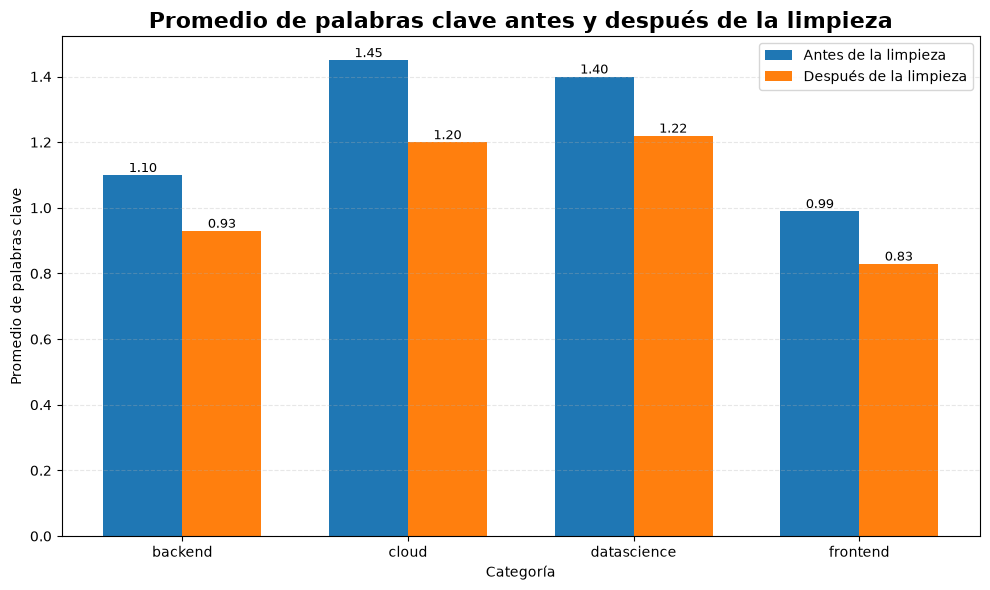

In [135]:
# ==============================================================================
# CELDA 15
# PROMEDIO DE KEYWORDS ANTES Y DESPUÉS POR CATEGORÍA
# ==============================================================================

promedio_keywords_categoria = (
    df.groupby("categoria")[
        [
            "num_keywords_originales",
            "num_keywords_limpias"
        ]
    ]
    .mean()
    .round(2)
    .sort_index()
)

display(promedio_keywords_categoria)

# ------------------------------------------------------------------------------
# Visualización
# ------------------------------------------------------------------------------

categorias = promedio_keywords_categoria.index

posiciones = np.arange(
    len(categorias)
)

ancho = 0.35

plt.figure(figsize=(10, 6))

barras_originales = plt.bar(
    posiciones - ancho / 2,
    promedio_keywords_categoria["num_keywords_originales"],
    width=ancho,
    label="Antes de la limpieza"
)

barras_limpias = plt.bar(
    posiciones + ancho / 2,
    promedio_keywords_categoria["num_keywords_limpias"],
    width=ancho,
    label="Después de la limpieza"
)

plt.xticks(
    posiciones,
    categorias
)

plt.title(
    "Promedio de palabras clave antes y después de la limpieza",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Categoría")
plt.ylabel("Promedio de palabras clave")
plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for barras in [barras_originales, barras_limpias]:

    for barra in barras:

        altura = barra.get_height()

        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura,
            f"{altura:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [136]:
# ==============================================================================
# CELDA 16
# VALIDACIÓN DE LAS PALABRAS CLAVE LIMPIAS
# ==============================================================================

listas_validas = df["palabras_clave_limpias"].apply(
    lambda valor: isinstance(valor, list)
)

elementos_validos = df["palabras_clave_limpias"].apply(
    lambda lista: all(
        isinstance(keyword, str)
        and keyword.strip()
        for keyword in lista
    )
)

duplicados_internos = df["palabras_clave_limpias"].apply(
    lambda lista: len(lista) != len(set(lista))
)

print("=" * 80)
print("VALIDACIÓN FINAL")
print("=" * 80)

print(
    f"Registros con listas válidas: "
    f"{listas_validas.sum():,} de {len(df):,}"
)

print(
    f"Registros con elementos válidos: "
    f"{elementos_validos.sum():,} de {len(df):,}"
)

print(
    f"Registros con duplicados internos: "
    f"{duplicados_internos.sum():,}"
)

if (
    listas_validas.all()
    and elementos_validos.all()
    and not duplicados_internos.any()
):
    print(
        "\nLa columna de palabras clave quedó correctamente normalizada."
    )
else:
    print(
        "\nADVERTENCIA: algunos registros requieren revisión manual."
    )

VALIDACIÓN FINAL
Registros con listas válidas: 5,000 de 5,000
Registros con elementos válidos: 5,000 de 5,000
Registros con duplicados internos: 0

La columna de palabras clave quedó correctamente normalizada.


In [137]:
# ==============================================================================
# CELDA 17
# FUNCIONES DE NORMALIZACIÓN TEXTUAL
# ==============================================================================

def eliminar_emojis_y_controles(texto):
    """
    Elimina emojis, caracteres de control y símbolos decorativos.

    Conserva caracteres técnicos como:
    +, #, ., /, _, - y :
    """

    caracteres_validos = []

    for caracter in texto:

        categoria = unicodedata.category(caracter)

        # Caracteres de control, formato, sustitutos y uso privado
        if categoria.startswith("C"):
            continue

        # Símbolos decorativos y emojis
        if categoria in {"So", "Sk"}:
            continue

        caracteres_validos.append(caracter)

    return "".join(caracteres_validos)


def normalizar_sintaxis_tecnica(texto):
    """
    Corrige espacios y variantes frecuentes dentro de términos técnicos.

    Ejemplos:
    - c ++      -> c++
    - c #       -> c#
    - node . js -> node.js
    - ci / cd   -> ci/cd
    - . net     -> .net
    - 3 . 12    -> 3.12
    """

    # Lenguajes y plataformas
    texto = re.sub(r"\bc\s*\+\s*\+\b", "c++", texto)
    texto = re.sub(r"\bc\s*#\b", "c#", texto)

    texto = re.sub(
        r"\bdot\s*net\b",
        ".net",
        texto
    )

    texto = re.sub(
        r"(?<!\w)\.\s+net\b",
        ".net",
        texto
    )

    # Tecnologías terminadas en .js
    texto = re.sub(
        r"\b(node|next|react|vue|nuxt|express)\s*\.\s*js\b",
        r"\1.js",
        texto
    )

    # TypeScript y JavaScript
    texto = re.sub(
        r"\bjava\s*script\b",
        "javascript",
        texto
    )

    texto = re.sub(
        r"\btype\s*script\b",
        "typescript",
        texto
    )

    # Integración y despliegue continuo
    texto = re.sub(
        r"\bci\s*[/\-]\s*cd\b",
        "ci/cd",
        texto
    )

    # Versiones numéricas
    texto = re.sub(
        r"(?<=\d)\s*\.\s*(?=\d)",
        ".",
        texto
    )

    # Barras presentes en términos técnicos
    texto = re.sub(
        r"\s*/\s*",
        "/",
        texto
    )

    # Guiones presentes entre palabras
    texto = re.sub(
        r"\s*-\s*",
        "-",
        texto
    )

    return texto


def normalizar_texto(
    valor,
    convertir_minusculas=True,
    eliminar_urls=True,
    eliminar_correos=True
):
    """
    Limpia y normaliza texto técnico sin eliminar información relevante.

    Parameters
    ----------
    valor : object
        Texto original que será normalizado.

    convertir_minusculas : bool, default=True
        Convierte el contenido a minúsculas.

    eliminar_urls : bool, default=True
        Elimina direcciones web.

    eliminar_correos : bool, default=True
        Elimina direcciones de correo electrónico.

    Returns
    -------
    str
        Texto limpio y normalizado.
    """

    # --------------------------------------------------------------------------
    # 1. Manejo de valores nulos
    # --------------------------------------------------------------------------

    if valor is None or pd.isna(valor):
        return ""

    texto = str(valor)

    # --------------------------------------------------------------------------
    # 2. Normalización HTML y Unicode
    # --------------------------------------------------------------------------

    texto = html.unescape(texto)

    # NFKC unifica caracteres visualmente equivalentes
    texto = unicodedata.normalize(
        "NFKC",
        texto
    )

    # --------------------------------------------------------------------------
    # 3. Markdown
    # --------------------------------------------------------------------------

    # Conservar el texto visible de enlaces Markdown:
    # [FastAPI documentation](https://fastapi.tiangolo.com)
    # se convierte en:
    # FastAPI documentation

    texto = re.sub(
        r"\[([^\]]+)\]\((?:[^)]+)\)",
        r"\1",
        texto
    )

    # Conservar el contenido de bloques de código,
    # eliminando únicamente las marcas ```
    texto = re.sub(
        r"```(?:[a-zA-Z0-9_+#.-]+)?",
        " ",
        texto
    )

    texto = texto.replace("```", " ")

    # Eliminar comillas invertidas de código inline
    texto = texto.replace("`", " ")

    # Eliminar encabezados, listas y citas Markdown
    texto = re.sub(
        r"(?m)^\s{0,3}(?:#{1,6}|>|[-*+])\s+",
        " ",
        texto
    )

    # --------------------------------------------------------------------------
    # 4. HTML
    # --------------------------------------------------------------------------

    # Sustituir etiquetas que representan saltos de línea
    texto = re.sub(
        r"<\s*(?:br|p|div|li|h[1-6])\b[^>]*>",
        " ",
        texto,
        flags=re.IGNORECASE
    )

    # Eliminar etiquetas HTML restantes
    texto = re.sub(
        r"<[^>]+>",
        " ",
        texto
    )

    # --------------------------------------------------------------------------
    # 5. URLs y correos
    # --------------------------------------------------------------------------

    if eliminar_urls:
        texto = re.sub(
            r"https?://\S+|www\.\S+",
            " ",
            texto,
            flags=re.IGNORECASE
        )

    if eliminar_correos:
        texto = re.sub(
            r"\b[\w.+-]+@[\w.-]+\.[a-zA-Z]{2,}\b",
            " ",
            texto
        )

    # --------------------------------------------------------------------------
    # 6. Normalización de mayúsculas
    # --------------------------------------------------------------------------

    if convertir_minusculas:
        texto = texto.lower()

    # --------------------------------------------------------------------------
    # 7. Emojis y caracteres invisibles
    # --------------------------------------------------------------------------

    texto = eliminar_emojis_y_controles(
        texto
    )

    # --------------------------------------------------------------------------
    # 8. Sintaxis técnica
    # --------------------------------------------------------------------------

    texto = normalizar_sintaxis_tecnica(
        texto
    )

    # --------------------------------------------------------------------------
    # 9. Limpieza de símbolos
    # --------------------------------------------------------------------------
    # Conservamos:
    # letras, números, espacios, +, #, ., /, _, -, :
    # --------------------------------------------------------------------------

    texto = re.sub(
        r"[^\w\sáéíóúüñç+#./:\-]",
        " ",
        texto,
        flags=re.UNICODE
    )

    # Eliminar puntos aislados, pero conservar .net, node.js y versiones
    texto = re.sub(
        r"(?<![\w])\.(?![\w])",
        " ",
        texto
    )

    # Eliminar barras aisladas
    texto = re.sub(
        r"(?<![\w])/(?![\w])",
        " ",
        texto
    )

    # Eliminar guiones aislados
    texto = re.sub(
        r"(?<![\w])-(?![\w])",
        " ",
        texto
    )

    # Reducir repeticiones excesivas de algunos símbolos
    texto = re.sub(r"#{2,}", "#", texto)
    texto = re.sub(r"/{2,}", "/", texto)
    texto = re.sub(r"_{2,}", "_", texto)
    texto = re.sub(r"-{2,}", "-", texto)

    # --------------------------------------------------------------------------
    # 10. Normalización final de espacios
    # --------------------------------------------------------------------------

    texto = re.sub(
        r"\s+",
        " ",
        texto
    ).strip()

    return texto

In [138]:
# ==============================================================================
# CELDA 18
# FUNCIONES ESPECÍFICAS POR COLUMNA
# ==============================================================================

def limpiar_titulo(valor):
    """
    Normaliza títulos de contenido tecnológico.

    La limpieza es conservadora porque los títulos suelen contener
    tecnologías, versiones y conceptos altamente discriminantes.
    """

    return normalizar_texto(
        valor=valor,
        convertir_minusculas=True,
        eliminar_urls=True,
        eliminar_correos=True
    )


def limpiar_contenido(valor):
    """
    Normaliza el texto principal del documento.

    Conserva términos técnicos, versiones, nombres de herramientas,
    fragmentos de código y expresiones relevantes para la clasificación.
    """

    return normalizar_texto(
        valor=valor,
        convertir_minusculas=True,
        eliminar_urls=True,
        eliminar_correos=True
    )

In [139]:
# ==============================================================================
# CELDA 19
# PRUEBAS DE NORMALIZACIÓN
# ==============================================================================

ejemplos_prueba = pd.DataFrame({
    "Texto_original": [
        "Building APIs with C++ and C# 🚀",
        "Deploy Node . js with CI / CD on OCI",
        "What's new in Python 3 . 12?",
        "<h1>Machine Learning</h1> with Scikit-Learn",
        "Read the guide at https://example.com/tutorial",
        "[FastAPI Documentation](https://fastapi.tiangolo.com)",
        "Contact us: developer@example.com",
        "Using . NET and REST API for Backend Development",
        "Llama 3 . 3 with Groq: A Practical Guide",
        "```python\nprint('Hello World')\n```",
        "Machine-learning & Data Science!!!",
        "React . js, Next . js and Vue . js"
    ]
})

ejemplos_prueba["Texto_limpio"] = (
    ejemplos_prueba["Texto_original"]
    .apply(normalizar_texto)
)

display(ejemplos_prueba)

,Texto_original,Texto_limpio
0,Building APIs with C++ and C# 🚀,building apis with c++ and c#
1,Deploy Node . js with CI / CD on OCI,deploy node.js with ci/cd on oci
2,What's new in Python 3 . 12?,what s new in python 3.12
3,<h1>Machine Learning</h1> with Scikit-Learn,machine learning with scikit-learn
4,Read the guide at https://example.com/tutorial,read the guide at
5,[FastAPI Documentation](https://fastapi.tiangolo.com),fastapi documentation
6,Contact us: developer@example.com,contact us:
7,Using . NET and REST API for Backend Development,using .net and rest api for backend development
8,Llama 3 . 3 with Groq: A Practical Guide,llama 3.3 with groq: a practical guide
9,```python\nprint('Hello World')\n```,print hello world


In [140]:
# ==============================================================================
# CELDA 20
# VALIDACIONES AUTOMÁTICAS
# ==============================================================================

casos_validacion = {
    "C++": "c++",
    "C#": "c#",
    ". NET": ".net",
    "Node . js": "node.js",
    "CI / CD": "ci/cd",
    "Python 3 . 12": "python 3.12",
    "Llama 3 . 3": "llama 3.3",
    "REST API": "rest api"
}

resultados_validacion = []

for entrada, salida_esperada in casos_validacion.items():

    salida_obtenida = normalizar_texto(
        entrada
    )

    resultados_validacion.append({
        "Entrada": entrada,
        "Resultado": salida_obtenida,
        "Esperado": salida_esperada,
        "Validacion": salida_obtenida == salida_esperada
    })

df_validacion = pd.DataFrame(
    resultados_validacion
)

display(df_validacion)

validaciones_correctas = (
    df_validacion["Validacion"].all()
)

if validaciones_correctas:
    print(
        "Todas las pruebas de preservación técnica fueron superadas."
    )
else:
    print(
        "ADVERTENCIA: alguna regla de normalización requiere revisión."
    )

,Entrada,Resultado,Esperado,Validacion
0,C++,c++,c++,True
1,C#,c#,c#,True
2,. NET,.net,.net,True
3,Node . js,node.js,node.js,True
4,CI / CD,ci/cd,ci/cd,True
5,Python 3 . 12,python 3.12,python 3.12,True
6,Llama 3 . 3,llama 3.3,llama 3.3,True
7,REST API,rest api,rest api,True


Todas las pruebas de preservación técnica fueron superadas.


In [141]:
# ==============================================================================
# CELDA 21
# VALIDACIÓN DE VALORES VACÍOS Y NULOS
# ==============================================================================

casos_vacios = [
    None,
    np.nan,
    pd.NA,
    "",
    "   ",
    "<br>",
    "🚀"
]

resultados_vacios = [
    {
        "Entrada": repr(valor),
        "Resultado": repr(normalizar_texto(valor))
    }
    for valor in casos_vacios
]

display(
    pd.DataFrame(resultados_vacios)
)

,Entrada,Resultado
0,None,''
1,nan,''
2,<NA>,''
3,'',''
4,' ',''
5,'<br>',''
6,'🚀',''


In [142]:
# ==============================================================================
# CELDA 22
# APLICACIÓN DE LA LIMPIEZA A TÍTULOS Y TEXTOS
# ==============================================================================

from time import perf_counter

print("=" * 80)
print("NORMALIZACIÓN DE TÍTULOS Y TEXTOS")
print("=" * 80)

# ------------------------------------------------------------------------------
# 1. Conservación de las columnas originales
# ------------------------------------------------------------------------------

df["titulo_original"] = df["titulo"].copy()
df["texto_original"] = df["texto"].copy()

# ------------------------------------------------------------------------------
# 2. Aplicación de las funciones de limpieza
# ------------------------------------------------------------------------------

inicio = perf_counter()

df["titulo_limpio"] = (
    df["titulo_original"]
    .apply(limpiar_titulo)
)

df["texto_limpio"] = (
    df["texto_original"]
    .apply(limpiar_contenido)
)

tiempo_total = perf_counter() - inicio

print("\nLimpieza aplicada correctamente.")
print(f"Registros procesados: {len(df):,}")
print(f"Tiempo de procesamiento: {tiempo_total:.2f} segundos")

NORMALIZACIÓN DE TÍTULOS Y TEXTOS

Limpieza aplicada correctamente.
Registros procesados: 5,000
Tiempo de procesamiento: 0.71 segundos


In [143]:
# ==============================================================================
# CELDA 23
# MÉTRICAS DE LONGITUD ANTES Y DESPUÉS
# ==============================================================================

# ==============================================================================
# CONTEO CONSISTENTE DE TOKENS TÉCNICOS
# ==============================================================================

PATRON_TOKEN_TECNICO = re.compile(
    r"""
    (?:
        \.net
        |
        [a-záéíóúüñç]\+\+
        |
        [a-záéíóúüñç]\#
        |
        [a-záéíóúüñç0-9]+
        (?:[._/\-][a-záéíóúüñç0-9]+)*
        |
        \d+(?:\.\d+)+
    )
    """,
    flags=re.IGNORECASE | re.VERBOSE
)


def contar_palabras(valor):
    """
    Cuenta tokens técnicos usando el mismo criterio
    para los textos originales y los textos limpios.

    Conserva como una sola unidad:
    c++, c#, .net, node.js, ci/cd, scikit-learn y 3.12.
    """

    if valor is None or pd.isna(valor):
        return 0

    texto = html.unescape(str(valor))
    texto = unicodedata.normalize(
        "NFKC",
        texto
    ).lower()

    return len(
        PATRON_TOKEN_TECNICO.findall(texto)
    )


# ------------------------------------------------------------------------------
# Título
# ------------------------------------------------------------------------------

df["titulo_caracteres_original"] = (
    df["titulo_original"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["titulo_caracteres_limpio"] = (
    df["titulo_limpio"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["titulo_palabras_original"] = (
    df["titulo_original"]
    .apply(contar_palabras)
)

df["titulo_palabras_limpio"] = (
    df["titulo_limpio"]
    .apply(contar_palabras)
)

# ------------------------------------------------------------------------------
# Texto
# ------------------------------------------------------------------------------

df["texto_caracteres_original"] = (
    df["texto_original"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["texto_caracteres_limpio"] = (
    df["texto_limpio"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["texto_palabras_original"] = (
    df["texto_original"]
    .apply(contar_palabras)
)

df["texto_palabras_limpio"] = (
    df["texto_limpio"]
    .apply(contar_palabras)
)

In [144]:
# ==============================================================================
# CELDA 24
# PORCENTAJE DE REDUCCIÓN POR DOCUMENTO
# ==============================================================================

def calcular_reduccion(original, limpio):
    """
    Calcula el porcentaje de reducción entre una longitud original y limpia.
    """

    original = pd.to_numeric(
        original,
        errors="coerce"
    ).fillna(0)

    limpio = pd.to_numeric(
        limpio,
        errors="coerce"
    ).fillna(0)

    reduccion = np.where(
        original > 0,
        ((original - limpio) / original) * 100,
        0
    )

    return np.round(reduccion, 2)


df["reduccion_titulo_pct"] = calcular_reduccion(
    df["titulo_caracteres_original"],
    df["titulo_caracteres_limpio"]
)

df["reduccion_texto_pct"] = calcular_reduccion(
    df["texto_caracteres_original"],
    df["texto_caracteres_limpio"]
)

In [145]:
# ==============================================================================
# CELDA 25
# RESUMEN GENERAL
# ==============================================================================

resumen_normalizacion = pd.DataFrame({
    "Variable": [
        "Título — caracteres",
        "Título — palabras",
        "Texto — caracteres",
        "Texto — palabras"
    ],
    "Promedio_antes": [
        df["titulo_caracteres_original"].mean(),
        df["titulo_palabras_original"].mean(),
        df["texto_caracteres_original"].mean(),
        df["texto_palabras_original"].mean()
    ],
    "Promedio_despues": [
        df["titulo_caracteres_limpio"].mean(),
        df["titulo_palabras_limpio"].mean(),
        df["texto_caracteres_limpio"].mean(),
        df["texto_palabras_limpio"].mean()
    ]
})

resumen_normalizacion["Diferencia"] = (
    resumen_normalizacion["Promedio_antes"]
    - resumen_normalizacion["Promedio_despues"]
)

resumen_normalizacion["Reduccion_pct"] = np.where(
    resumen_normalizacion["Promedio_antes"] > 0,
    (
        resumen_normalizacion["Diferencia"]
        / resumen_normalizacion["Promedio_antes"]
    ) * 100,
    0
)

resumen_normalizacion = resumen_normalizacion.round(2)

print("\nResumen de longitud antes y después de la limpieza:")

display(resumen_normalizacion)


Resumen de longitud antes y después de la limpieza:


,Variable,Promedio_antes,Promedio_despues,Diferencia,Reduccion_pct
0,Título — caracteres,64.74,63.84,0.90,1.39
1,Título — palabras,9.99,9.98,0.01,0.12
2,Texto — caracteres,104.30,98.54,5.76,5.52
3,Texto — palabras,15.92,15.89,0.03,0.20


In [146]:
# ==============================================================================
# CELDA 26
# REGISTROS MODIFICADOS POR LA NORMALIZACIÓN
# ==============================================================================

df["titulo_modificado"] = (
    df["titulo_original"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne(df["titulo_limpio"])
)

df["texto_modificado"] = (
    df["texto_original"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne(df["texto_limpio"])
)

cantidad_titulos_modificados = int(
    df["titulo_modificado"].sum()
)

cantidad_textos_modificados = int(
    df["texto_modificado"].sum()
)

porcentaje_titulos_modificados = (
    cantidad_titulos_modificados / len(df) * 100
    if len(df) > 0
    else 0
)

porcentaje_textos_modificados = (
    cantidad_textos_modificados / len(df) * 100
    if len(df) > 0
    else 0
)

print("=" * 80)
print("REGISTROS MODIFICADOS")
print("=" * 80)

print(
    f"Títulos modificados: "
    f"{cantidad_titulos_modificados:,} "
    f"({porcentaje_titulos_modificados:.2f} %)"
)

print(
    f"Textos modificados:  "
    f"{cantidad_textos_modificados:,} "
    f"({porcentaje_textos_modificados:.2f} %)"
)

REGISTROS MODIFICADOS
Títulos modificados: 4,981 (99.62 %)
Textos modificados:  5,000 (100.00 %)


In [147]:
# ==============================================================================
# CELDA 27
# MUESTRA COMPARATIVA
# ==============================================================================

columnas_comparacion = [
    "categoria",
    "titulo_original",
    "titulo_limpio",
    "texto_original",
    "texto_limpio",
    "reduccion_titulo_pct",
    "reduccion_texto_pct"
]

registros_modificados = df[
    df["titulo_modificado"]
    | df["texto_modificado"]
]

print("\nComparación de registros modificados:")

if not registros_modificados.empty:

    cantidad_muestra = min(
        10,
        len(registros_modificados)
    )

    muestra_comparacion = (
        registros_modificados[
            columnas_comparacion
        ]
        .sample(
            n=cantidad_muestra,
            random_state=RANDOM_STATE
        )
    )

    display(muestra_comparacion)

else:
    print(
        "No se detectaron diferencias entre los textos originales "
        "y los textos normalizados."
    )


Comparación de registros modificados:


,categoria,titulo_original,titulo_limpio,texto_original,texto_limpio,reduccion_titulo_pct,reduccion_texto_pct
1501,frontend,Why I stopped using design tokens as implementation details,why i stopped using design tokens as implementation details,"Design tokens are not CSS variables. This distinction sounds semantic, but getting it wrong produces...",design tokens are not css variables. this distinction sounds semantic but getting it wrong produces.,0.00,2.91
2586,frontend,"Lottie Animations and Accessibility: prefers-reduced-motion, ARIA, and Best Practices",lottie animations and accessibility: prefers-reduced-motion aria and best practices,"Animations are a common accessibility problem. For users with vestibular disorders, epilepsy, or...",animations are a common accessibility problem. for users with vestibular disorders epilepsy or.,2.35,4.04
2653,backend,Node.js Syllabus for Beginners 🚀 | Complete Backend Roadmap,node.js syllabus for beginners complete backend roadmap,"Node.js Syllabus for Beginners 🚀 If you're planning to become a Backend Developer, Full...",node.js syllabus for beginners if you re planning to become a backend developer full.,6.78,7.61
1055,cloud,Why I Recommend Alibaba Cloud ECS for Developers in 2026,why i recommend alibaba cloud ecs for developers in 2026,Why I Recommend Alibaba Cloud ECS for Developers in 2026 As a developer who has tested...,why i recommend alibaba cloud ecs for developers in 2026 as a developer who has tested.,0.00,4.40
705,datascience,Anonymized Data Isn't. Or It Isn't Data: A Technical Overview,anonymized data isn t. or it isn t data: a technical overview,Why Privacy Is the Most Misunderstood Concept in Data Science A technical follow-up to...,why privacy is the most misunderstood concept in data science a technical follow-up to.,0.00,4.40
106,backend,Top 5 LLM Gateways in 2026,top 5 llm gateways in 2026,"As enterprise adoption of generative AI accelerates, teams are moving away from direct, hard-coded...",as enterprise adoption of generative ai accelerates teams are moving away from direct hard-coded.,0.00,3.96
589,datascience,Machine Learning Engineer vs Data Scientist: Understanding the Difference,machine learning engineer vs data scientist: understanding the difference,"Artificial intelligence teams often include both Data Scientists and Machine Learning Engineers,...",artificial intelligence teams often include both data scientists and machine learning engineers,0.00,4.04
2468,cloud,Kubernetes Efficiency Starts With Better Decisions,kubernetes efficiency starts with better decisions,Most Kubernetes problems are not technical problems. They are decision problems. And the good news is...,most kubernetes problems are not technical problems. they are decision problems. and the good news is.,0.00,1.92
2413,frontend,"SEO en 2026, parte 2: la captura rankea — ahora haz que convierta",seo en 2026 parte 2: la captura rankea ahora haz que convierta,"El post anterior terminó donde terminan la mayoría de los posts de ""ya hicimos SEO"": la página es...",el post anterior terminó donde terminan la mayoría de los posts de ya hicimos seo : la página es.,4.62,3.00
1600,datascience,Statistics,statistics,Descriptive Statistics Explained My notes while learning Statistics for Data Science When...,descriptive statistics explained my notes while learning statistics for data science when.,0.00,5.26


In [148]:
# ==============================================================================
# CELDA 28
# VALIDACIÓN DE REGISTROS VACÍOS
# ==============================================================================

df["titulo_limpio_vacio"] = (
    df["titulo_limpio"]
    .fillna("")
    .str.strip()
    .eq("")
)

df["texto_limpio_vacio"] = (
    df["texto_limpio"]
    .fillna("")
    .str.strip()
    .eq("")
)

df["documento_limpio_vacio"] = (
    df["titulo_limpio_vacio"]
    & df["texto_limpio_vacio"]
)

cantidad_titulos_vacios = int(
    df["titulo_limpio_vacio"].sum()
)

cantidad_textos_vacios = int(
    df["texto_limpio_vacio"].sum()
)

cantidad_documentos_vacios = int(
    df["documento_limpio_vacio"].sum()
)

print("=" * 80)
print("VALIDACIÓN DE CONTENIDO VACÍO")
print("=" * 80)

print(
    f"Títulos vacíos después de limpiar: "
    f"{cantidad_titulos_vacios:,}"
)

print(
    f"Textos vacíos después de limpiar:  "
    f"{cantidad_textos_vacios:,}"
)

print(
    f"Documentos completamente vacíos:   "
    f"{cantidad_documentos_vacios:,}"
)

if cantidad_documentos_vacios > 0:

    print(
        "\nADVERTENCIA: existen documentos sin título ni texto "
        "después de la limpieza."
    )

    display(
        df.loc[
            df["documento_limpio_vacio"],
            [
                "titulo_original",
                "texto_original",
                "categoria",
                "palabras_clave_original"
            ]
        ].head(20)
    )

else:
    print(
        "\nNo se generaron documentos completamente vacíos."
    )

VALIDACIÓN DE CONTENIDO VACÍO
Títulos vacíos después de limpiar: 1
Textos vacíos después de limpiar:  0
Documentos completamente vacíos:   0

No se generaron documentos completamente vacíos.


In [149]:
# ==============================================================================
# CELDA 29
# LONGITUD PROMEDIO POR CATEGORÍA
# ==============================================================================

longitud_categoria = (
    df.groupby("categoria")
    .agg(
        palabras_texto_antes=(
            "texto_palabras_original",
            "mean"
        ),
        palabras_texto_despues=(
            "texto_palabras_limpio",
            "mean"
        ),
        reduccion_promedio_pct=(
            "reduccion_texto_pct",
            "mean"
        )
    )
    .round(2)
    .sort_index()
)

print("Longitud promedio del texto por categoría:")

display(longitud_categoria)

Longitud promedio del texto por categoría:


,palabras_texto_antes,palabras_texto_despues,reduccion_promedio_pct
categoria,,,
backend,17.23,17.21,4.47
cloud,16.39,16.37,6.06
datascience,15.17,15.16,5.70
frontend,14.91,14.84,7.28


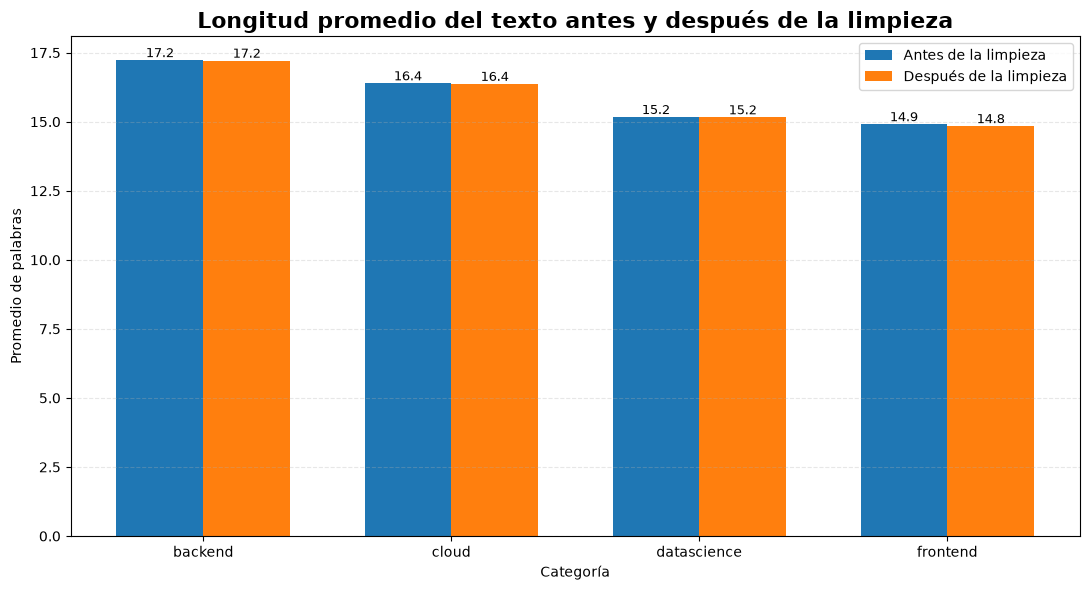

In [150]:
# ==============================================================================
# CELDA 30
# GRÁFICO: PALABRAS ANTES Y DESPUÉS POR CATEGORÍA
# ==============================================================================

categorias = longitud_categoria.index

posiciones = np.arange(
    len(categorias)
)

ancho = 0.35

plt.figure(figsize=(11, 6))

barras_antes = plt.bar(
    posiciones - ancho / 2,
    longitud_categoria["palabras_texto_antes"],
    width=ancho,
    label="Antes de la limpieza"
)

barras_despues = plt.bar(
    posiciones + ancho / 2,
    longitud_categoria["palabras_texto_despues"],
    width=ancho,
    label="Después de la limpieza"
)

plt.xticks(
    posiciones,
    categorias
)

plt.title(
    "Longitud promedio del texto antes y después de la limpieza",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Categoría")
plt.ylabel("Promedio de palabras")

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for grupo_barras in [
    barras_antes,
    barras_despues
]:

    for barra in grupo_barras:

        altura = barra.get_height()

        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura,
            f"{altura:.1f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [151]:
# ==============================================================================
# CELDA 31
# VALIDACIÓN FINAL
# ==============================================================================

columnas_generadas = [
    "titulo_original",
    "texto_original",
    "titulo_limpio",
    "texto_limpio",
    "titulo_palabras_limpio",
    "texto_palabras_limpio",
    "reduccion_titulo_pct",
    "reduccion_texto_pct"
]

columnas_faltantes = [
    columna
    for columna in columnas_generadas
    if columna not in df.columns
]

tipos_correctos = (
    df["titulo_limpio"].apply(
        lambda valor: isinstance(valor, str)
    ).all()
    and
    df["texto_limpio"].apply(
        lambda valor: isinstance(valor, str)
    ).all()
)

print("=" * 80)
print("RESULTADO DE LA CELDA 9")
print("=" * 80)

if not columnas_faltantes and tipos_correctos:
    print(
        "La normalización de títulos y textos se completó correctamente."
    )
else:

    if columnas_faltantes:
        print(
            f"Columnas faltantes: {columnas_faltantes}"
        )

    if not tipos_correctos:
        print(
            "Existen valores con tipos de datos inesperados."
        )

RESULTADO DE LA CELDA 9
La normalización de títulos y textos se completó correctamente.


In [152]:
# ==============================================================================
# CELDA 32
# COMPARACIÓN CUALITATIVA ANTES Y DESPUÉS DE LA NORMALIZACIÓN
# ==============================================================================

COLUMNAS_REVISION = [
    "categoria",
    "titulo_original",
    "titulo_limpio",
    "texto_original",
    "texto_limpio",
    "reduccion_titulo_pct",
    "reduccion_texto_pct"
]

print("=" * 80)
print("COMPARACIÓN CUALITATIVA DEL PREPROCESAMIENTO")
print("=" * 80)

print(f"\nRegistros disponibles: {len(df):,}")
print(f"Categorías: {sorted(df['categoria'].dropna().unique())}")

COMPARACIÓN CUALITATIVA DEL PREPROCESAMIENTO

Registros disponibles: 5,000
Categorías: ['backend', 'cloud', 'datascience', 'frontend']


In [153]:
# ==============================================================================
# CELDA 33
# MUESTRA ALEATORIA ESTRATIFICADA POR CATEGORÍA
# ==============================================================================

muestras_categoria = []

for categoria, grupo in df.groupby("categoria"):

    cantidad = min(
        3,
        len(grupo)
    )

    muestra = grupo.sample(
        n=cantidad,
        random_state=RANDOM_STATE
    )

    muestras_categoria.append(
        muestra[COLUMNAS_REVISION]
    )

muestra_estratificada = pd.concat(
    muestras_categoria,
    ignore_index=True
)

print("\nEjemplos antes y después por categoría:")

display(muestra_estratificada)


Ejemplos antes y después por categoría:


,categoria,titulo_original,titulo_limpio,texto_original,texto_limpio,reduccion_titulo_pct,reduccion_texto_pct
0,backend,READ COMMITTED isn't as safe as you think,read committed isn t as safe as you think,Every Postgres app I've worked on runs at READ COMMITTED. It's the default. It's what your ORM opens...,every postgres app i ve worked on runs at read committed. it s the default. it s what your orm opens.,0.00,1.94
1,backend,"How Database Reads Work: Pages, Buffer Pools, and Disk",how database reads work: pages buffer pools and disk,"Quick Answer: When you query a database, it rarely reads a single row directly from disk. Instead, it...",quick answer: when you query a database it rarely reads a single row directly from disk. instead it.,3.70,3.85
2,backend,Do We Need Distributed Stream Processing?,do we need distributed stream processing,Do We Need Distributed Stream Processing? There's a thread on HackerNews right now where...,do we need distributed stream processing there s a thread on hackernews right now where.,2.44,5.38
3,cloud,The 11 Best Cloud Cost Management Tools,the 11 best cloud cost management tools,"An analysis of the top platforms for helping engineering and finance teams control and optimize cloud infrastructure spending on AWS, Azure, and GCP.",an analysis of the top platforms for helping engineering and finance teams control and optimize cloud infrastructure spending on aws azure and gcp.,0.00,1.34
4,cloud,Enhance Application Delivery with GSLB,enhance application delivery with gslb,"Global Server Load Balancing (GSLB) is essential for modern application delivery, providing multi-cloud, multi-data center load balancing. It ensu...",global server load balancing gslb is essential for modern application delivery providing multi-cloud multi-data center load balancing. it ensures,0.00,3.33
5,cloud,7 Azure Cloud Migration Challenges Every Engineer Should Know (And How to Fix Them),7 azure cloud migration challenges every engineer should know and how to fix them,"Moving workloads to Azure looks clean on a project plan. Pick a date, migrate the servers, save money...",moving workloads to azure looks clean on a project plan. pick a date migrate the servers save money.,2.41,3.85
6,datascience,"Garbage In, Garbage Out: A Beginner’s Guide to Data Cleaning",garbage in garbage out: a beginner s guide to data cleaning,"When you first dive into machine learning, it is easy to get swept up in the excitement of building...",when you first dive into machine learning it is easy to get swept up in the excitement of building.,1.67,2.94
7,datascience,Your Pipeline Is 22.1h Behind: Catching Inflation Sentiment Leads with Pulsebit,your pipeline is 22.1h behind: catching inflation sentiment leads with pulsebit,Your Pipeline Is 22.1h Behind: Catching Inflation Sentiment Leads with Pulsebit We just...,your pipeline is 22.1h behind: catching inflation sentiment leads with pulsebit we just.,0.00,4.35
8,datascience,Your Pipeline Is 14.0h Behind: Catching Business Sentiment Leads with Pulsebit,your pipeline is 14.0h behind: catching business sentiment leads with pulsebit,Your pipeline just missed a critical anomaly: a 24h momentum spike of -0.600. This significant drop...,your pipeline just missed a critical anomaly: a 24h momentum spike of-0.600. this significant drop.,0.00,2.94
9,frontend,Integrating Accessibility QA into Your CI/CD Pipeline,integrating accessibility qa into your ci/cd pipeline,Integrating Accessibility QA into Your CI/CD Pipeline Integrating Accessibility...,integrating accessibility qa into your ci/cd pipeline integrating accessibility.,0.00,13.98


In [154]:
# ==============================================================================
# CELDA 34
# DOCUMENTOS CON MAYOR REDUCCIÓN DE CONTENIDO
# ==============================================================================

top_reduccion_texto = (
    df.sort_values(
        "reduccion_texto_pct",
        ascending=False
    )
    [
        [
            "categoria",
            "titulo_original",
            "texto_original",
            "texto_limpio",
            "texto_caracteres_original",
            "texto_caracteres_limpio",
            "texto_palabras_original",
            "texto_palabras_limpio",
            "reduccion_texto_pct"
        ]
    ]
    .head(20)
)

print("\nTop 20 documentos con mayor reducción de texto:")

display(top_reduccion_texto)


Top 20 documentos con mayor reducción de texto:


,categoria,titulo_original,texto_original,texto_limpio,texto_caracteres_original,texto_caracteres_limpio,texto_palabras_original,texto_palabras_limpio,reduccion_texto_pct
2851,backend,Middleware-System,Middleware System Project Code：https://github.com/hyperlane-dev/hyperlane ...,middleware system project code:,90,31,6,4,65.56
1684,datascience,IoT – Internet of Things Service,IoT – Internet of Things Service https://www.realmacways.com/iot-internet-of-things-service/ At Real...,iot internet of things service at real.,104,39,9,7,62.50
4294,frontend,Professional Essay Writers,Professional Essay Writers https://www.brilliantwriter.co.uk/writing/essay-services/ Improve Your...,professional essay writers improve your.,101,40,7,5,60.40
2182,backend,No parser. No interpreter. Just Java. That's how `@CompiledPath` gets so close to native performance.,143 Faster JSONPath by Removing JSONPath ...,143 faster jsonpath by removing jsonpath,98,40,6,6,59.18
3953,cloud,Digital Marketing Service,"Digital Marketing Service https://www.realmacways.com/digital-marketing-service/ Our agency company,...",digital marketing service our agency company,104,44,8,6,57.69
3648,backend,Routing Basics,Project Code：https://github.com/hyperlane-dev/hyperlane Introduction Routing is the...,project code: introduction routing is the.,99,42,8,6,57.58
4132,backend,Getting Started with Hyperlane,Project Code：https://github.com/hyperlane-dev/hyperlane Introduction Hyperlane is a...,project code: introduction hyperlane is a.,99,42,8,6,57.58
4698,cloud,Report Writing Service,Report Writing Service https://www.hireresearcher.com/services/report-writing/ Our academic writing...,report writing service our academic writing.,103,44,8,6,57.28
1988,backend,Response Building and Sending in Hyperlane,Project Code：https://github.com/hyperlane-dev/hyperlane Introduction In the hyperlane...,project code: introduction in the hyperlane.,101,44,8,6,56.44
1391,backend,Request Handling,Project Code：https://github.com/hyperlane-dev/hyperlane Introduction Handling incoming...,project code: introduction handling incoming.,102,45,7,5,55.88


In [155]:
# ==============================================================================
# CELDA 35
# DOCUMENTOS CON MENOR REDUCCIÓN
# ==============================================================================

documentos_con_texto = df[
    df["texto_caracteres_original"] > 0
]

menor_reduccion = (
    documentos_con_texto.sort_values(
        "reduccion_texto_pct",
        ascending=True
    )
    [
        [
            "categoria",
            "texto_original",
            "texto_limpio",
            "reduccion_texto_pct"
        ]
    ]
    .head(15)
)

print("\nDocumentos con menor reducción:")

display(menor_reduccion)


Documentos con menor reducción:


,categoria,texto_original,texto_limpio,reduccion_texto_pct
0,frontend,GeekNews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑,geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑,0.00
1631,cloud,Learn how to optimize PostgreSQL data pipelines using Parquet on S3 with LTAP architecture for scalable analytics,learn how to optimize postgresql data pipelines using parquet on s3 with ltap architecture for scalable analytics,0.00
1683,cloud,A practical AWS and CI/CD workflow for verifying CloudWatch alarm emails end to end without filling real team inboxes.,a practical aws and ci/cd workflow for verifying cloudwatch alarm emails end to end without filling real team inboxes.,0.00
1698,backend,Learn how idempotency keys can enhance API reliability during retries at scale.,learn how idempotency keys can enhance api reliability during retries at scale.,0.00
1788,frontend,Practical bootstrap template guide with copy-ready CSS code examples for 2026.,practical bootstrap template guide with copy-ready css code examples for 2026.,0.00
1817,frontend,Say goodbye to manual memoization. Discover how the new React Compiler fundamentally transforms how we build React applications.,say goodbye to manual memoization. discover how the new react compiler fundamentally transforms how we build react applications.,0.00
1829,frontend,GeekNews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑,geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑,0.00
1861,cloud,Guía práctica para validar correos de aprobación en Terraform y flujos de infraestructura sin mezclar inboxes reales ni perder trazabilidad.,guía práctica para validar correos de aprobación en terraform y flujos de infraestructura sin mezclar inboxes reales ni perder trazabilidad.,0.00
1989,datascience,David Ohnstad explains why mid-year data product reviews collapse when teams can't answer critical questions. Learn how to fix broken review proce...,david ohnstad explains why mid-year data product reviews collapse when teams can t answer critical questions. learn how to fix broken review proce...,0.00
1995,backend,Actuator no es el problema. El problema es habilitarlo sin una política clara de exposición. Una guía prudente para usarlo como herramienta operat...,actuator no es el problema. el problema es habilitarlo sin una política clara de exposición. una guía prudente para usarlo como herramienta operat...,0.00


In [156]:
# ==============================================================================
# CELDA 36
# CLASIFICACIÓN DEL NIVEL DE REDUCCIÓN
# ==============================================================================

condiciones_reduccion = [
    df["reduccion_texto_pct"] < 0,
    df["reduccion_texto_pct"].between(
        0,
        5,
        inclusive="right"
    ),
    df["reduccion_texto_pct"].between(
        5,
        15,
        inclusive="right"
    ),
    df["reduccion_texto_pct"].between(
        15,
        30,
        inclusive="right"
    ),
    df["reduccion_texto_pct"] > 30
]

etiquetas_reduccion = [
    "Aumento de longitud",
    "Ligera: 0 %–5 %",
    "Moderada: 5 %–15 %",
    "Alta: 15 %–30 %",
    "Muy alta: más de 30 %"
]

df["nivel_reduccion_texto"] = np.select(
    condiciones_reduccion,
    etiquetas_reduccion,
    default="Sin clasificar"
)

orden_reduccion = [
    "Aumento de longitud",
    "Ligera: 0 %–5 %",
    "Moderada: 5 %–15 %",
    "Alta: 15 %–30 %",
    "Muy alta: más de 30 %",
    "Sin clasificar"
]

resumen_nivel_reduccion = (
    df["nivel_reduccion_texto"]
    .value_counts()
    .reindex(
        orden_reduccion,
        fill_value=0
    )
    .rename_axis("Nivel_reduccion")
    .reset_index(name="Cantidad")
)

resumen_nivel_reduccion["Porcentaje"] = (
    resumen_nivel_reduccion["Cantidad"]
    .div(len(df))
    .mul(100)
    .round(2)
)

display(resumen_nivel_reduccion)

,Nivel_reduccion,Cantidad,Porcentaje
0,Aumento de longitud,0,0.00
1,Ligera: 0 %–5 %,3348,66.96
2,Moderada: 5 %–15 %,1150,23.00
3,Alta: 15 %–30 %,333,6.66
4,Muy alta: más de 30 %,56,1.12
5,Sin clasificar,113,2.26


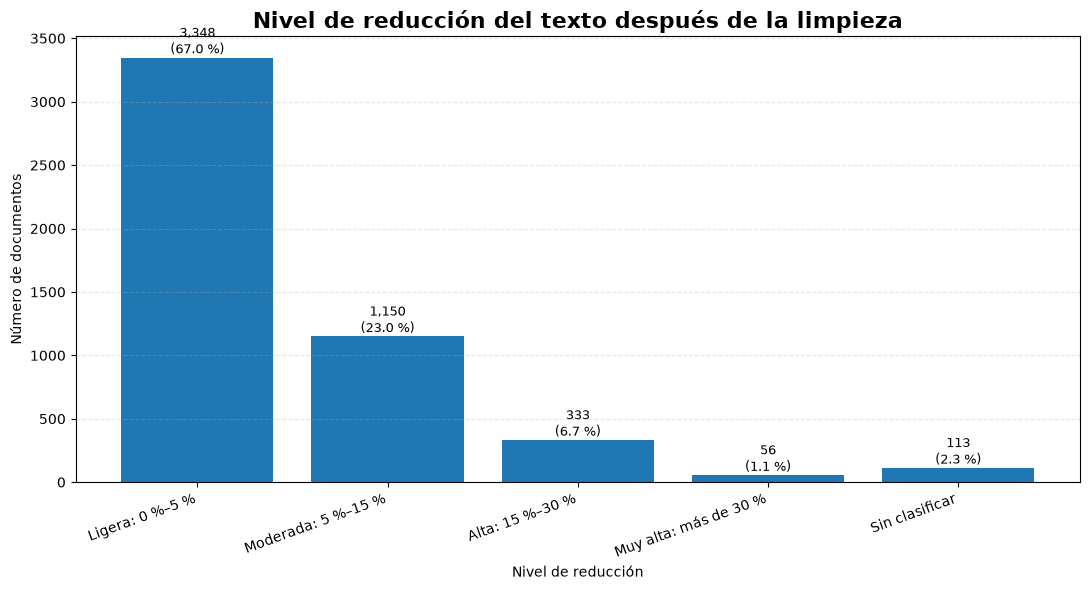

In [157]:
# ==============================================================================
# CELDA 37
# VISUALIZACIÓN DEL NIVEL DE REDUCCIÓN
# ==============================================================================

datos_grafico = resumen_nivel_reduccion[
    resumen_nivel_reduccion["Cantidad"] > 0
].copy()

plt.figure(figsize=(11, 6))

barras = plt.bar(
    datos_grafico["Nivel_reduccion"],
    datos_grafico["Cantidad"]
)

for barra, porcentaje in zip(
    barras,
    datos_grafico["Porcentaje"]
):

    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{int(altura):,}\n({porcentaje:.1f} %)",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    "Nivel de reducción del texto después de la limpieza",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Nivel de reducción")
plt.ylabel("Número de documentos")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [158]:
# ==============================================================================
# CELDA 38
# DETECCIÓN DE CASOS POTENCIALMENTE PROBLEMÁTICOS
# ==============================================================================

df["reduccion_tokens_texto_pct"] = np.where(
    df["texto_palabras_original"] > 0,
    (
        (
            df["texto_palabras_original"]
            - df["texto_palabras_limpio"]
        )
        / df["texto_palabras_original"]
    ) * 100,
    0
)

df["reduccion_tokens_texto_pct"] = (
    df["reduccion_tokens_texto_pct"]
    .round(2)
)

df["requiere_revision_textual"] = (
    df["reduccion_texto_pct"].gt(30)
    | df["reduccion_tokens_texto_pct"].gt(30)
    | df["texto_palabras_limpio"].lt(3)
    | df["texto_limpio_vacio"]
)

casos_revision = df[
    df["requiere_revision_textual"]
].copy()

print("=" * 80)
print("CASOS PARA REVISIÓN")
print("=" * 80)

print(
    f"Documentos que requieren revisión: "
    f"{len(casos_revision):,}"
)

print(
    f"Porcentaje del dataset: "
    f"{len(casos_revision) / len(df) * 100:.2f} %"
)

if not casos_revision.empty:

    display(
        casos_revision[
            [
                "categoria",
                "titulo_original",
                "texto_original",
                "texto_limpio",
                "texto_palabras_original",
                "texto_palabras_limpio",
                "reduccion_texto_pct",
                "reduccion_tokens_texto_pct"
            ]
        ]
        .sort_values(
            "reduccion_texto_pct",
            ascending=False
        )
        .head(30)
    )

else:
    print(
        "\nNo se detectaron documentos con una pérdida "
        "de información potencialmente problemática."
    )

CASOS PARA REVISIÓN
Documentos que requieren revisión: 70
Porcentaje del dataset: 1.40 %


,categoria,titulo_original,texto_original,texto_limpio,texto_palabras_original,texto_palabras_limpio,reduccion_texto_pct,reduccion_tokens_texto_pct
2851,backend,Middleware-System,Middleware System Project Code：https://github.com/hyperlane-dev/hyperlane ...,middleware system project code:,6,4,65.56,33.33
1684,datascience,IoT – Internet of Things Service,IoT – Internet of Things Service https://www.realmacways.com/iot-internet-of-things-service/ At Real...,iot internet of things service at real.,9,7,62.50,22.22
4294,frontend,Professional Essay Writers,Professional Essay Writers https://www.brilliantwriter.co.uk/writing/essay-services/ Improve Your...,professional essay writers improve your.,7,5,60.40,28.57
2182,backend,No parser. No interpreter. Just Java. That's how `@CompiledPath` gets so close to native performance.,143 Faster JSONPath by Removing JSONPath ...,143 faster jsonpath by removing jsonpath,6,6,59.18,0.00
3953,cloud,Digital Marketing Service,"Digital Marketing Service https://www.realmacways.com/digital-marketing-service/ Our agency company,...",digital marketing service our agency company,8,6,57.69,25.00
3648,backend,Routing Basics,Project Code：https://github.com/hyperlane-dev/hyperlane Introduction Routing is the...,project code: introduction routing is the.,8,6,57.58,25.00
4132,backend,Getting Started with Hyperlane,Project Code：https://github.com/hyperlane-dev/hyperlane Introduction Hyperlane is a...,project code: introduction hyperlane is a.,8,6,57.58,25.00
4698,cloud,Report Writing Service,Report Writing Service https://www.hireresearcher.com/services/report-writing/ Our academic writing...,report writing service our academic writing.,8,6,57.28,25.00
1988,backend,Response Building and Sending in Hyperlane,Project Code：https://github.com/hyperlane-dev/hyperlane Introduction In the hyperlane...,project code: introduction in the hyperlane.,8,6,56.44,25.00
1391,backend,Request Handling,Project Code：https://github.com/hyperlane-dev/hyperlane Introduction Handling incoming...,project code: introduction handling incoming.,7,5,55.88,28.57


In [159]:
# ==============================================================================
# CELDA 39
# VALIDACIÓN DE PRESERVACIÓN DE TÉRMINOS TÉCNICOS
# ==============================================================================

TERMINOS_TECNICOS_REVISION = [
    "c++",
    "c#",
    ".net",
    "node.js",
    "next.js",
    "react.js",
    "vue.js",
    "ci/cd",
    "rest api",
    "python",
    "java",
    "javascript",
    "typescript",
    "docker",
    "kubernetes",
    "aws",
    "oci",
    "gcp",
    "machine learning",
    "data science",
    "llama 3.3",
    "groq"
]


def contar_documentos_con_termino(serie, termino):
    """
    Cuenta documentos que contienen un término técnico.

    Se utiliza búsqueda literal para evitar que símbolos como +,
    # o . sean interpretados como expresiones regulares.
    """

    return int(
        serie
        .fillna("")
        .astype(str)
        .str.lower()
        .str.contains(
            termino.lower(),
            regex=False
        )
        .sum()
    )


validacion_terminos = []

for termino in TERMINOS_TECNICOS_REVISION:

    antes = contar_documentos_con_termino(
        df["texto_original"],
        termino
    )

    despues = contar_documentos_con_termino(
        df["texto_limpio"],
        termino
    )

    validacion_terminos.append({
        "Termino": termino,
        "Documentos_antes": antes,
        "Documentos_despues": despues,
        "Diferencia": despues - antes
    })

df_validacion_terminos = pd.DataFrame(
    validacion_terminos
)

df_validacion_terminos["Conservacion_pct"] = np.where(
    df_validacion_terminos["Documentos_antes"] > 0,
    (
        df_validacion_terminos["Documentos_despues"]
        / df_validacion_terminos["Documentos_antes"]
    ) * 100,
    np.nan
)

df_validacion_terminos["Conservacion_pct"] = (
    df_validacion_terminos["Conservacion_pct"]
    .round(2)
)

print("\nPreservación de términos técnicos:")

display(df_validacion_terminos)


Preservación de términos técnicos:


,Termino,Documentos_antes,Documentos_despues,Diferencia,Conservacion_pct
0,c++,0,0,0,NaN
1,c#,0,0,0,NaN
2,.net,9,9,0,100.00
3,node.js,31,31,0,100.00
4,next.js,20,20,0,100.00
5,react.js,2,2,0,100.00
6,vue.js,1,1,0,100.00
7,ci/cd,20,20,0,100.00
8,rest api,18,18,0,100.00
9,python,66,66,0,100.00


In [160]:
# ==============================================================================
# CELDA 40
# RESUMEN DE CASOS DE REVISIÓN POR CATEGORÍA
# ==============================================================================

revision_categoria = (
    df.groupby("categoria")
    .agg(
        total_documentos=(
            "categoria",
            "size"
        ),
        documentos_revision=(
            "requiere_revision_textual",
            "sum"
        ),
        reduccion_media_caracteres=(
            "reduccion_texto_pct",
            "mean"
        ),
        reduccion_media_tokens=(
            "reduccion_tokens_texto_pct",
            "mean"
        )
    )
)

revision_categoria["documentos_revision_pct"] = (
    revision_categoria["documentos_revision"]
    .div(revision_categoria["total_documentos"])
    .mul(100)
)

revision_categoria = revision_categoria.round(2)

display(revision_categoria)

,total_documentos,documentos_revision,reduccion_media_caracteres,reduccion_media_tokens,documentos_revision_pct
categoria,,,,,
backend,1250,17,4.47,0.25,1.36
cloud,1250,6,6.06,0.19,0.48
datascience,1250,2,5.70,0.11,0.16
frontend,1250,45,7.28,0.60,3.60


In [161]:
# ==============================================================================
# CELDA 41
# CONCLUSIÓN AUTOMÁTICA
# ==============================================================================

reduccion_media = df["reduccion_texto_pct"].mean()

porcentaje_revision = (
    df["requiere_revision_textual"].mean() * 100
)

documentos_vacios = int(
    df["documento_limpio_vacio"].sum()
)

print("=" * 80)
print("CONCLUSIÓN DE LA COMPARACIÓN CUALITATIVA")
print("=" * 80)

print(
    f"Reducción promedio de caracteres: "
    f"{reduccion_media:.2f} %"
)

print(
    f"Documentos señalados para revisión: "
    f"{porcentaje_revision:.2f} %"
)

print(
    f"Documentos completamente vacíos: "
    f"{documentos_vacios:,}"
)

if (
    reduccion_media <= 15
    and porcentaje_revision <= 10
    and documentos_vacios == 0
):
    print("""
La normalización presenta un comportamiento adecuado. La reducción media es
moderada, la mayoría de los documentos conserva su contenido y no se generaron
registros completamente vacíos. El dataset puede avanzar a la construcción de
la variable textual combinada.
""")

elif documentos_vacios > 0:
    print("""
La normalización general es funcional, pero existen documentos completamente
vacíos. Estos registros deberán revisarse o excluirse de forma controlada antes
del entrenamiento.
""")

else:
    print("""
La normalización requiere una revisión adicional. Se recomienda inspeccionar
los documentos con mayor reducción antes de continuar con el modelado.
""")

CONCLUSIÓN DE LA COMPARACIÓN CUALITATIVA
Reducción promedio de caracteres: 5.88 %
Documentos señalados para revisión: 1.40 %
Documentos completamente vacíos: 0

La normalización presenta un comportamiento adecuado. La reducción media es
moderada, la mayoría de los documentos conserva su contenido y no se generaron
registros completamente vacíos. El dataset puede avanzar a la construcción de
la variable textual combinada.



In [162]:
# ==============================================================================
# CELDA 42
# CONSTRUCCIÓN DE VARIABLES TEXTUALES COMBINADAS
# ==============================================================================

print("=" * 80)
print("CONSTRUCCIÓN DE VARIABLES TEXTUALES PARA EL MODELADO")
print("=" * 80)


def combinar_campos_textuales(*campos):
    """
    Combina campos textuales ignorando valores nulos o vacíos.

    Parameters
    ----------
    *campos : str
        Campos que se desean concatenar.

    Returns
    -------
    str
        Texto combinado con espacios normalizados.
    """

    partes_validas = []

    for campo in campos:

        if campo is None or pd.isna(campo):
            continue

        texto = str(campo).strip()

        if texto:
            partes_validas.append(texto)

    texto_combinado = " ".join(partes_validas)

    return re.sub(
        r"\s+",
        " ",
        texto_combinado
    ).strip()

CONSTRUCCIÓN DE VARIABLES TEXTUALES PARA EL MODELADO


In [163]:
# ==============================================================================
# CELDA 43
# VARIANTES DE ENTRADA
# ==============================================================================

# ------------------------------------------------------------------------------
# Variante 1: únicamente el contenido principal
# ------------------------------------------------------------------------------

df["texto_modelo_base"] = (
    df["texto_limpio"]
    .apply(combinar_campos_textuales)
)

# ------------------------------------------------------------------------------
# Variante 2: título + contenido
# ------------------------------------------------------------------------------

df["texto_modelo_titulo"] = df.apply(
    lambda fila: combinar_campos_textuales(
        fila["titulo_limpio"],
        fila["texto_limpio"]
    ),
    axis=1
)

# ------------------------------------------------------------------------------
# Variante 3: título + contenido + palabras clave
# ------------------------------------------------------------------------------

df["texto_combinado"] = df.apply(
    lambda fila: combinar_campos_textuales(
        fila["titulo_limpio"],
        fila["texto_limpio"],
        fila["palabras_clave_texto"]
    ),
    axis=1
)

# ------------------------------------------------------------------------------
# Variante 4: ponderación mediante repetición controlada
# ------------------------------------------------------------------------------
# Título:         2 apariciones
# Texto:          1 aparición
# Palabras clave: 2 apariciones
# ------------------------------------------------------------------------------

df["texto_combinado_ponderado"] = df.apply(
    lambda fila: combinar_campos_textuales(
        fila["titulo_limpio"],
        fila["titulo_limpio"],
        fila["texto_limpio"],
        fila["palabras_clave_texto"],
        fila["palabras_clave_texto"]
    ),
    axis=1
)

print("\nVariables textuales creadas correctamente.")

print(
    [
        "texto_modelo_base",
        "texto_modelo_titulo",
        "texto_combinado",
        "texto_combinado_ponderado"
    ]
)


Variables textuales creadas correctamente.
['texto_modelo_base', 'texto_modelo_titulo', 'texto_combinado', 'texto_combinado_ponderado']


In [164]:
# ==============================================================================
# CELDA 44
# MUESTRA DE LAS VARIABLES CONSTRUIDAS
# ==============================================================================

columnas_muestra = [
    "categoria",
    "titulo_limpio",
    "texto_limpio",
    "palabras_clave_texto",
    "texto_modelo_base",
    "texto_modelo_titulo",
    "texto_combinado",
    "texto_combinado_ponderado"
]

cantidad_muestra = min(
    8,
    len(df)
)

muestra_variantes = (
    df[columnas_muestra]
    .sample(
        n=cantidad_muestra,
        random_state=RANDOM_STATE
    )
)

display(muestra_variantes)

,categoria,titulo_limpio,texto_limpio,palabras_clave_texto,texto_modelo_base,texto_modelo_titulo,texto_combinado,texto_combinado_ponderado
1501,frontend,why i stopped using design tokens as implementation details,design tokens are not css variables. this distinction sounds semantic but getting it wrong produces.,,design tokens are not css variables. this distinction sounds semantic but getting it wrong produces.,why i stopped using design tokens as implementation details design tokens are not css variables. this distinction sounds semantic but getting it w...,why i stopped using design tokens as implementation details design tokens are not css variables. this distinction sounds semantic but getting it w...,why i stopped using design tokens as implementation details why i stopped using design tokens as implementation details design tokens are not css ...
2586,frontend,lottie animations and accessibility: prefers-reduced-motion aria and best practices,animations are a common accessibility problem. for users with vestibular disorders epilepsy or.,,animations are a common accessibility problem. for users with vestibular disorders epilepsy or.,lottie animations and accessibility: prefers-reduced-motion aria and best practices animations are a common accessibility problem. for users with ...,lottie animations and accessibility: prefers-reduced-motion aria and best practices animations are a common accessibility problem. for users with ...,lottie animations and accessibility: prefers-reduced-motion aria and best practices lottie animations and accessibility: prefers-reduced-motion ar...
2653,backend,node.js syllabus for beginners complete backend roadmap,node.js syllabus for beginners if you re planning to become a backend developer full.,syllabus,node.js syllabus for beginners if you re planning to become a backend developer full.,node.js syllabus for beginners complete backend roadmap node.js syllabus for beginners if you re planning to become a backend developer full.,node.js syllabus for beginners complete backend roadmap node.js syllabus for beginners if you re planning to become a backend developer full. syll...,node.js syllabus for beginners complete backend roadmap node.js syllabus for beginners complete backend roadmap node.js syllabus for beginners if ...
1055,cloud,why i recommend alibaba cloud ecs for developers in 2026,why i recommend alibaba cloud ecs for developers in 2026 as a developer who has tested.,,why i recommend alibaba cloud ecs for developers in 2026 as a developer who has tested.,why i recommend alibaba cloud ecs for developers in 2026 why i recommend alibaba cloud ecs for developers in 2026 as a developer who has tested.,why i recommend alibaba cloud ecs for developers in 2026 why i recommend alibaba cloud ecs for developers in 2026 as a developer who has tested.,why i recommend alibaba cloud ecs for developers in 2026 why i recommend alibaba cloud ecs for developers in 2026 why i recommend alibaba cloud ec...
705,datascience,anonymized data isn t. or it isn t data: a technical overview,why privacy is the most misunderstood concept in data science a technical follow-up to.,,why privacy is the most misunderstood concept in data science a technical follow-up to.,anonymized data isn t. or it isn t data: a technical overview why privacy is the most misunderstood concept in data science a technical follow-up to.,anonymized data isn t. or it isn t data: a technical overview why privacy is the most misunderstood concept in data science a technical follow-up to.,anonymized data isn t. or it isn t data: a technical overview anonymized data isn t. or it isn t data: a technical overview why privacy is the mos...
106,backend,top 5 llm gateways in 2026,as enterprise adoption of generative ai accelerates teams are moving away from direct hard-coded.,ai,as enterprise adoption of generative ai accelerates teams are moving away from direct hard-coded.,top 5 llm gateways in 2026 as enterprise adoption of generative ai accele

In [165]:
# ==============================================================================
# CELDA 45
# LONGITUD DE LAS VARIABLES TEXTUALES
# ==============================================================================

VARIANTES_TEXTO = [
    "texto_modelo_base",
    "texto_modelo_titulo",
    "texto_combinado",
    "texto_combinado_ponderado"
]

for columna in VARIANTES_TEXTO:

    df[f"{columna}_palabras"] = (
        df[columna]
        .apply(contar_palabras)
    )

    df[f"{columna}_caracteres"] = (
        df[columna]
        .str.len()
    )

resumen_variantes = pd.DataFrame({
    "Variable": VARIANTES_TEXTO,
    "Promedio_palabras": [
        df[f"{columna}_palabras"].mean()
        for columna in VARIANTES_TEXTO
    ],
    "Mediana_palabras": [
        df[f"{columna}_palabras"].median()
        for columna in VARIANTES_TEXTO
    ],
    "Promedio_caracteres": [
        df[f"{columna}_caracteres"].mean()
        for columna in VARIANTES_TEXTO
    ],
    "Documentos_vacios": [
        df[columna].str.strip().eq("").sum()
        for columna in VARIANTES_TEXTO
    ]
}).round(2)

print("\nComparación de las variantes textuales:")

display(resumen_variantes)


Comparación de las variantes textuales:


,Variable,Promedio_palabras,Mediana_palabras,Promedio_caracteres,Documentos_vacios
0,texto_modelo_base,15.89,15.00,98.54,0
1,texto_modelo_titulo,25.87,25.00,163.38,0
2,texto_combinado,27.62,27.00,174.71,0
3,texto_combinado_ponderado,39.34,38.00,250.89,0


In [166]:
# ==============================================================================
# CELDA 46
# LONGITUD PROMEDIO DE TEXTO COMBINADO POR CATEGORÍA
# ==============================================================================

longitud_combinada_categoria = (
    df.groupby("categoria")
    .agg(
        promedio_base=(
            "texto_modelo_base_palabras",
            "mean"
        ),
        promedio_titulo_texto=(
            "texto_modelo_titulo_palabras",
            "mean"
        ),
        promedio_completo=(
            "texto_combinado_palabras",
            "mean"
        ),
        promedio_ponderado=(
            "texto_combinado_ponderado_palabras",
            "mean"
        )
    )
    .round(2)
    .sort_index()
)

display(longitud_combinada_categoria)

,promedio_base,promedio_titulo_texto,promedio_completo,promedio_ponderado
categoria,,,,
backend,17.21,26.85,28.49,39.78
cloud,16.37,26.09,28.19,40.01
datascience,15.16,26.20,28.00,40.85
frontend,14.84,24.35,25.78,36.72


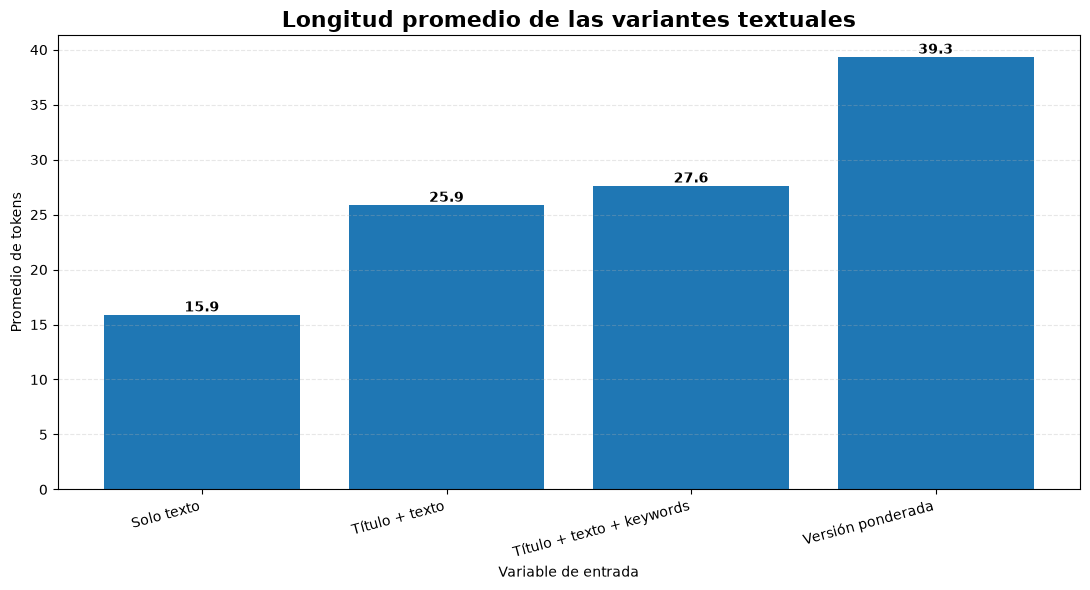

In [167]:
# ==============================================================================
# CELDA 47
# GRÁFICO COMPARATIVO DE LAS VARIANTES
# ==============================================================================

datos_grafico = resumen_variantes.copy()

nombres_cortos = {
    "texto_modelo_base": "Solo texto",
    "texto_modelo_titulo": "Título + texto",
    "texto_combinado": "Título + texto + keywords",
    "texto_combinado_ponderado": "Versión ponderada"
}

datos_grafico["Nombre"] = (
    datos_grafico["Variable"]
    .map(nombres_cortos)
)

plt.figure(figsize=(11, 6))

barras = plt.bar(
    datos_grafico["Nombre"],
    datos_grafico["Promedio_palabras"]
)

for barra in barras:

    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Longitud promedio de las variantes textuales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Variable de entrada")
plt.ylabel("Promedio de tokens")

plt.xticks(
    rotation=15,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [168]:
# ==============================================================================
# CELDA 48
# VALIDACIÓN DE CONTENIDO
# ==============================================================================

validacion_variantes = []

for columna in VARIANTES_TEXTO:

    cantidad_vacios = int(
        df[columna]
        .fillna("")
        .str.strip()
        .eq("")
        .sum()
    )

    cantidad_nulos = int(
        df[columna]
        .isna()
        .sum()
    )

    validacion_variantes.append({
        "Variable": columna,
        "Valores_nulos": cantidad_nulos,
        "Documentos_vacios": cantidad_vacios,
        "Validacion": (
            cantidad_nulos == 0
            and cantidad_vacios == 0
        )
    })

df_validacion_variantes = pd.DataFrame(
    validacion_variantes
)

display(df_validacion_variantes)

if df_validacion_variantes["Validacion"].all():

    print(
        "Todas las variantes contienen información válida."
    )

else:

    print(
        "ADVERTENCIA: alguna variante contiene registros vacíos o nulos."
    )

,Variable,Valores_nulos,Documentos_vacios,Validacion
0,texto_modelo_base,0,0,True
1,texto_modelo_titulo,0,0,True
2,texto_combinado,0,0,True
3,texto_combinado_ponderado,0,0,True


Todas las variantes contienen información válida.


In [169]:
# ==============================================================================
# CELDA 49
# DUPLICADOS EN LAS VARIABLES TEXTUALES
# ==============================================================================

resumen_duplicados = []

for columna in VARIANTES_TEXTO:

    duplicados = int(
        df.duplicated(
            subset=[columna],
            keep=False
        ).sum()
    )

    valores_unicos = int(
        df[columna].nunique()
    )

    resumen_duplicados.append({
        "Variable": columna,
        "Textos_unicos": valores_unicos,
        "Registros_en_grupos_duplicados": duplicados,
        "Porcentaje_duplicados": round(
            duplicados / len(df) * 100,
            2
        )
    })

df_resumen_duplicados = pd.DataFrame(
    resumen_duplicados
)

display(df_resumen_duplicados)

,Variable,Textos_unicos,Registros_en_grupos_duplicados,Porcentaje_duplicados
0,texto_modelo_base,4551,824,16.48
1,texto_modelo_titulo,4610,744,14.88
2,texto_combinado,4610,744,14.88
3,texto_combinado_ponderado,4610,744,14.88


In [170]:
# ==============================================================================
# CELDA 50
# DUPLICADOS CON ETIQUETAS CONTRADICTORIAS
# ==============================================================================

categorias_por_texto = (
    df.groupby("texto_combinado")["categoria"]
    .nunique()
)

textos_con_conflicto = categorias_por_texto[
    categorias_por_texto > 1
].index

conflictos_categoria = (
    df[df["texto_combinado"].isin(textos_con_conflicto)]
    [
        [
            "texto_combinado",
            "categoria",
            "titulo_original",
            "texto_original"
        ]
    ]
    .sort_values(
        ["texto_combinado", "categoria"]
    )
)

print("=" * 80)
print("VALIDACIÓN DE ETIQUETAS CONTRADICTORIAS")
print("=" * 80)

print(
    f"Textos asociados con más de una categoría: "
    f"{len(textos_con_conflicto):,}"
)

print(
    f"Registros involucrados: "
    f"{len(conflictos_categoria):,}"
)

if not conflictos_categoria.empty:

    print(
        "\nADVERTENCIA: existen textos iguales con categorías diferentes."
    )

    display(
        conflictos_categoria.head(30)
    )

else:

    print(
        "\nNo se detectaron textos idénticos con etiquetas contradictorias."
    )

VALIDACIÓN DE ETIQUETAS CONTRADICTORIAS
Textos asociados con más de una categoría: 27
Registros involucrados: 78

ADVERTENCIA: existen textos iguales con categorías diferentes.


,texto_combinado,categoria,titulo_original,texto_original
3601,44/60 days system design questions your team just shipped offline mode for your field-service app. technicians work in basements technicians,backend,44/60 Days System Design Questions,"Your team just shipped ""offline mode"" for your field-service app. Technicians work in basements,..."
3329,44/60 days system design questions your team just shipped offline mode for your field-service app. technicians work in basements technicians,frontend,44/60 Days System Design Questions,"Your team just shipped ""offline mode"" for your field-service app. Technicians work in basements,..."
2826,ai powered java full stack course in telugu for freshers and graduates introduction freshers and graduates often look for career-oriented programs...,backend,AI Powered Java Full Stack Course in Telugu for Freshers and Graduates,Introduction Freshers and graduates often look for career-oriented programs that can help them enter...
4058,ai powered java full stack course in telugu for freshers and graduates introduction freshers and graduates often look for career-oriented programs...,frontend,AI Powered Java Full Stack Course in Telugu for Freshers and Graduates,Introduction Freshers and graduates often look for career-oriented programs that can help them enter...
1867,backend bilan bitta so z tufayli yo qotgan vaqtim kofe do konlari uchun tizimni frontend qismini qilayotgan edim. ma lumot kelganda ba zi joylar b...,backend,Backend bilan bitta so'z tufayli yo'qotgan vaqtim,Kofe do'konlari uchun tizimni frontend qismini qilayotgan edim. Ma'lumot kelganda ba'zi joylar bo'sh...
1517,backend bilan bitta so z tufayli yo qotgan vaqtim kofe do konlari uchun tizimni frontend qismini qilayotgan edim. ma lumot kelganda ba zi joylar b...,frontend,Backend bilan bitta so'z tufayli yo'qotgan vaqtim,Kofe do'konlari uchun tizimni frontend qismini qilayotgan edim. Ma'lumot kelganda ba'zi joylar bo'sh...
4973,best 16 sites to buying edu emails for student discounts 2026. buy edu emails fast reply 24/7 instant support telegram: fast reply buy edu emails ...,backend,Best 16 Sites To Buying Edu Emails for Student Discounts 2026..,Buy Edu Emails ◈═━👑━═◈➜Fast Reply 24/7 | Instant Support 🚀 ◈═━👑━═◈➜Telegram:...
141,best 16 sites to buying edu emails for student discounts 2026. buy edu emails fast reply 24/7 instant support telegram: fast reply buy edu emails ...,datascience,Best 16 Sites To Buying Edu Emails for Student Discounts 2026..,Buy Edu Emails ◈═━👑━═◈➜Fast Reply 24/7 | Instant Support 🚀 ◈═━👑━═◈➜Telegram:...
2434,building a fastapi backend that serves live satellite imagery and orbital position tl dr i built a full-stack app that shows one place the sheffie...,backend,Building a FastAPI Backend That Serves Live Satellite Imagery and Orbital Position,TL;DR — I built a full-stack app that shows one place — the Sheffield Cholera Monument — from two...
2928,building a fastapi backend that serves live satellite imagery and orbital position tl dr i built a full-stack app that shows one place the sheffie...,datascience,Building a FastAPI Backend That Serves Live Satellite Imagery and Orbital Position,TL;DR — I built a full-stack app that shows one place — the Sheffield Cholera Monument — from two...


In [171]:
# ==============================================================================
# CELDA 51
# CONCLUSIÓN DE LA CONSTRUCCIÓN TEXTUAL
# ==============================================================================

documentos_vacios_combinados = int(
    df["texto_combinado"]
    .str.strip()
    .eq("")
    .sum()
)

cantidad_conflictos = len(
    textos_con_conflicto
)

promedio_palabras_combinado = (
    df["texto_combinado_palabras"]
    .mean()
)

print("=" * 80)
print("CONCLUSIÓN DE LA CONSTRUCCIÓN TEXTUAL")
print("=" * 80)

print(
    f"Promedio de tokens en texto_combinado: "
    f"{promedio_palabras_combinado:.2f}"
)

print(
    f"Documentos vacíos: "
    f"{documentos_vacios_combinados:,}"
)

print(
    f"Textos con categorías contradictorias: "
    f"{cantidad_conflictos:,}"
)

if (
    documentos_vacios_combinados == 0
    and cantidad_conflictos == 0
):
    print("""
Las variables textuales fueron construidas correctamente. La combinación de
título, contenido y palabras clave conserva información válida y no presenta
conflictos evidentes entre las etiquetas.

Las diferentes variantes se conservarán para evaluar experimentalmente cuál
produce el mejor F1-Score Macro durante el entrenamiento.
""")

elif cantidad_conflictos > 0:
    print("""
Las variables se construyeron correctamente, pero se detectaron textos
idénticos asociados con categorías distintas. Estos casos deben revisarse antes
de realizar la división de entrenamiento y prueba.
""")

else:
    print("""
Se detectaron documentos vacíos en la variable combinada. Estos registros deben
revisarse antes de continuar con el modelado.
""")

CONCLUSIÓN DE LA CONSTRUCCIÓN TEXTUAL
Promedio de tokens en texto_combinado: 27.62
Documentos vacíos: 0
Textos con categorías contradictorias: 27

Las variables se construyeron correctamente, pero se detectaron textos
idénticos asociados con categorías distintas. Estos casos deben revisarse antes
de realizar la división de entrenamiento y prueba.



In [172]:
# ==============================================================================
# CELDA 52
# AUDITORÍA Y RESOLUCIÓN DE ETIQUETAS CONTRADICTORIAS
# ==============================================================================

print("=" * 80)
print("AUDITORÍA DE TEXTOS CON ETIQUETAS CONTRADICTORIAS")
print("=" * 80)

COLUMNA_TEXTO_MODELO = "texto_combinado"
COLUMNA_OBJETIVO = "categoria"

# ------------------------------------------------------------------------------
# 1. Identificación de textos asociados con más de una categoría
# ------------------------------------------------------------------------------

categorias_por_texto = (
    df.groupby(COLUMNA_TEXTO_MODELO)[COLUMNA_OBJETIVO]
      .nunique()
)

textos_con_conflicto = categorias_por_texto[
    categorias_por_texto > 1
].index

mascara_conflictos = df[
    COLUMNA_TEXTO_MODELO
].isin(textos_con_conflicto)

cantidad_textos_conflictivos = len(
    textos_con_conflicto
)

cantidad_registros_conflictivos = int(
    mascara_conflictos.sum()
)

porcentaje_registros_conflictivos = (
    cantidad_registros_conflictivos
    / len(df)
    * 100
)

print(
    f"\nTextos únicos con etiquetas contradictorias: "
    f"{cantidad_textos_conflictivos:,}"
)

print(
    f"Registros involucrados: "
    f"{cantidad_registros_conflictivos:,}"
)

print(
    f"Porcentaje del dataset involucrado: "
    f"{porcentaje_registros_conflictivos:.2f} %"
)

AUDITORÍA DE TEXTOS CON ETIQUETAS CONTRADICTORIAS

Textos únicos con etiquetas contradictorias: 27
Registros involucrados: 78
Porcentaje del dataset involucrado: 1.56 %


In [173]:
# ==============================================================================
# CELDA 53
# RESUMEN DE LOS GRUPOS CONFLICTIVOS
# ==============================================================================

resumen_conflictos = (
    df.loc[mascara_conflictos]
      .groupby(COLUMNA_TEXTO_MODELO)
      .agg(
          cantidad_registros=(
              COLUMNA_OBJETIVO,
              "size"
          ),
          cantidad_categorias=(
              COLUMNA_OBJETIVO,
              "nunique"
          ),
          categorias=(
              COLUMNA_OBJETIVO,
              lambda serie: sorted(
                  serie.dropna().unique().tolist()
              )
          ),
          distribucion_categorias=(
              COLUMNA_OBJETIVO,
              lambda serie: dict(
                  serie.value_counts().sort_index()
              )
          ),
          titulos_originales=(
              "titulo_original",
              lambda serie: list(
                  dict.fromkeys(
                      serie.dropna()
                           .astype(str)
                           .tolist()
                  )
              )[:5]
          )
      )
      .reset_index()
      .sort_values(
          [
              "cantidad_categorias",
              "cantidad_registros"
          ],
          ascending=False
      )
)

print("\nResumen de grupos conflictivos:")

display(
    resumen_conflictos[
        [
            "cantidad_registros",
            "cantidad_categorias",
            "categorias",
            "distribucion_categorias",
            "titulos_originales",
            COLUMNA_TEXTO_MODELO
        ]
    ]
)


Resumen de grupos conflictivos:


,cantidad_registros,cantidad_categorias,categorias,distribucion_categorias,titulos_originales,texto_combinado
7,23,3,"[backend, cloud, datascience]","{'backend': 11, 'cloud': 6, 'datascience': 6}",[David Stark: Top High-Paying Roles],david stark: top high-paying roles hello architects elite engineers the market is shifting. we are seeing a surge in.
6,3,2,"[backend, frontend]","{'backend': 1, 'frontend': 2}",[Cookie attributes],cookie attributes a deeper look at cookie attributes set-cookie header when a server wants to create.
18,3,2,"[backend, frontend]","{'backend': 1, 'frontend': 2}",[Matrix Screen Saver for Mac],matrix screen saver for mac i was looking for a screen saver that was unique and what i finally found was a screen saver that looked like the casc...
24,3,2,"[backend, frontend]","{'backend': 2, 'frontend': 1}",[We Were Always Building State Machines — From .NET ViewBag to TypeScript Discriminated Unions],we were always building state machines from .net viewbag to typescript discriminated unions the old way: dynamic magic and its hidden costs years ...
0,2,2,"[backend, frontend]","{'backend': 1, 'frontend': 1}",[44/60 Days System Design Questions],44/60 days system design questions your team just shipped offline mode for your field-service app. technicians work in basements technicians
1,2,2,"[backend, frontend]","{'backend': 1, 'frontend': 1}",[AI Powered Java Full Stack Course in Telugu for Freshers and Graduates],ai powered java full stack course in telugu for freshers and graduates introduction freshers and graduates often look for career-oriented programs...
2,2,2,"[backend, frontend]","{'backend': 1, 'frontend': 1}",[Backend bilan bitta so'z tufayli yo'qotgan vaqtim],backend bilan bitta so z tufayli yo qotgan vaqtim kofe do konlari uchun tizimni frontend qismini qilayotgan edim. ma lumot kelganda ba zi joylar b...
3,2,2,"[backend, datascience]","{'backend': 1, 'datascience': 1}",[Best 16 Sites To Buying Edu Emails for Student Discounts 2026..],best 16 sites to buying edu emails for student discounts 2026. buy edu emails fast reply 24/7 instant support telegram: fast reply buy edu emails ...
4,2,2,"[backend, datascience]","{'backend': 1, 'datascience': 1}",[Building a FastAPI Backend That Serves Live Satellite Imagery and Orbital Position],building a fastapi backend that serves live satellite imagery and orbital position tl dr i built a full-stack app that shows one place the sheffie...
5,2,2,"[backend, frontend]","{'backend': 1, 'frontend': 1}",[Building Resilient Infrastructure: Embracing Self-Healing Systems with Artificial Intelligence],building resilient infrastructure: embracing self-healing systems with artificial intelligence building resilient infrastructure: embracing self-h...


In [174]:
# ==============================================================================
# CELDA 54
# DETALLE DE LOS REGISTROS CONTRADICTORIOS
# ==============================================================================

columnas_auditoria = [
    COLUMNA_TEXTO_MODELO,
    COLUMNA_OBJETIVO,
    "titulo_original",
    "texto_original",
    "palabras_clave_original",
    "titulo_limpio",
    "texto_limpio",
    "palabras_clave_limpias"
]

columnas_auditoria = [
    columna
    for columna in columnas_auditoria
    if columna in df.columns
]

df_conflictos = (
    df.loc[
        mascara_conflictos,
        columnas_auditoria
    ]
    .copy()
    .sort_values(
        [
            COLUMNA_TEXTO_MODELO,
            COLUMNA_OBJETIVO
        ]
    )
)

print("\nDetalle de los registros involucrados:")

display(
    df_conflictos.head(50)
)


Detalle de los registros involucrados:


,texto_combinado,categoria,titulo_original,texto_original,palabras_clave_original,titulo_limpio,texto_limpio,palabras_clave_limpias
3601,44/60 days system design questions your team just shipped offline mode for your field-service app. technicians work in basements technicians,backend,44/60 Days System Design Questions,"Your team just shipped ""offline mode"" for your field-service app. Technicians work in basements,...",['Technicians'],44/60 days system design questions,your team just shipped offline mode for your field-service app. technicians work in basements,[technicians]
3329,44/60 days system design questions your team just shipped offline mode for your field-service app. technicians work in basements technicians,frontend,44/60 Days System Design Questions,"Your team just shipped ""offline mode"" for your field-service app. Technicians work in basements,...",['Technicians'],44/60 days system design questions,your team just shipped offline mode for your field-service app. technicians work in basements,[technicians]
2826,ai powered java full stack course in telugu for freshers and graduates introduction freshers and graduates often look for career-oriented programs...,backend,AI Powered Java Full Stack Course in Telugu for Freshers and Graduates,Introduction Freshers and graduates often look for career-oriented programs that can help them enter...,[],ai powered java full stack course in telugu for freshers and graduates,introduction freshers and graduates often look for career-oriented programs that can help them enter.,[]
4058,ai powered java full stack course in telugu for freshers and graduates introduction freshers and graduates often look for career-oriented programs...,frontend,AI Powered Java Full Stack Course in Telugu for Freshers and Graduates,Introduction Freshers and graduates often look for career-oriented programs that can help them enter...,[],ai powered java full stack course in telugu for freshers and graduates,introduction freshers and graduates often look for career-oriented programs that can help them enter.,[]
1867,backend bilan bitta so z tufayli yo qotgan vaqtim kofe do konlari uchun tizimni frontend qismini qilayotgan edim. ma lumot kelganda ba zi joylar b...,backend,Backend bilan bitta so'z tufayli yo'qotgan vaqtim,Kofe do'konlari uchun tizimni frontend qismini qilayotgan edim. Ma'lumot kelganda ba'zi joylar bo'sh...,"[""Ma'lumot"", 'qismini qilayotgan']",backend bilan bitta so z tufayli yo qotgan vaqtim,kofe do konlari uchun tizimni frontend qismini qilayotgan edim. ma lumot kelganda ba zi joylar bo sh.,"[ma'lumot, qismini qilayotgan]"
1517,backend bilan bitta so z tufayli yo qotgan vaqtim kofe do konlari uchun tizimni frontend qismini qilayotgan edim. ma lumot kelganda ba zi joylar b...,frontend,Backend bilan bitta so'z tufayli yo'qotgan vaqtim,Kofe do'konlari uchun tizimni frontend qismini qilayotgan edim. Ma'lumot kelganda ba'zi joylar bo'sh...,"[""Ma'lumot"", 'qismini qilayotgan']",backend bilan bitta so z tufayli yo qotgan vaqtim,kofe do konlari uchun tizimni frontend qismini qilayotgan edim. ma lumot kelganda ba zi joylar bo sh.,"[ma'lumot, qismini qilayotgan]"
4973,best 16 sites to buying edu emails for student discounts 2026. buy edu emails fast reply 24/7 instant support telegram: fast reply buy edu emails ...,backend,Best 16 Sites To Buying Edu Emails for Student Discounts 2026..,Buy Edu Emails ◈═━👑━═◈➜Fast Reply 24/7 | Instant Support 🚀 ◈═━👑━═◈➜Telegram:...,"['👑━═◈', '➜Fast Reply', 'Buy Edu Emails', 'Telegram']",best 16 sites to buying edu emails for student discounts 2026.,buy edu emails fast reply 24/7 instant support telegram:,"[fast reply, buy edu emails, telegram]"
141,best 16 sites to buying edu emails for student discounts 2026. buy edu emails fast reply 24/7 instant support telegram: fast reply buy edu emails ...,datascience,Best 16 Sites To Buying Edu Emails for Student Discounts 2026..,Buy Edu Emails ◈═━👑━═◈➜Fast Reply 24/7 | Instant Support 🚀 ◈═━👑━═◈➜Telegram:...,"['👑━═◈', '

In [175]:
# ==============================================================================
# CELDA 55
# COMBINACIONES DE CATEGORÍAS EN CONFLICTO
# ==============================================================================

resumen_conflictos["combinacion_categorias"] = (
    resumen_conflictos["categorias"]
    .apply(lambda categorias: " ↔ ".join(categorias))
)

combinaciones_conflictivas = (
    resumen_conflictos[
        "combinacion_categorias"
    ]
    .value_counts()
    .rename_axis("Combinacion")
    .reset_index(name="Cantidad_textos")
)

print("Combinaciones de categorías contradictorias:")

display(combinaciones_conflictivas)

Combinaciones de categorías contradictorias:


,Combinacion,Cantidad_textos
0,backend ↔ frontend,18
1,backend ↔ datascience,3
2,backend ↔ cloud,3
3,cloud ↔ datascience,2
4,backend ↔ cloud ↔ datascience,1


In [176]:
# ==============================================================================
# CELDA 56
# EXCLUSIÓN CONTROLADA DE LOS CONFLICTOS
# ==============================================================================

df_modelado = (
    df.loc[
        ~mascara_conflictos
    ]
    .copy()
    .reset_index(drop=True)
)

df_conflictos = (
    df.loc[
        mascara_conflictos
    ]
    .copy()
    .reset_index(drop=True)
)

print("=" * 80)
print("SEPARACIÓN DE LOS DATOS")
print("=" * 80)

print(
    f"Dataset original:              "
    f"{len(df):,} registros"
)

print(
    f"Dataset disponible para modelo: "
    f"{len(df_modelado):,} registros"
)

print(
    f"Registros reservados:           "
    f"{len(df_conflictos):,}"
)

print(
    f"Datos conservados:              "
    f"{len(df_modelado) / len(df) * 100:.2f} %"
)

SEPARACIÓN DE LOS DATOS
Dataset original:              5,000 registros
Dataset disponible para modelo: 4,922 registros
Registros reservados:           78
Datos conservados:              98.44 %


In [177]:
# ==============================================================================
# CELDA 57
# BALANCE DE CLASES ANTES Y DESPUÉS
# ==============================================================================

distribucion_antes = (
    df[COLUMNA_OBJETIVO]
    .value_counts()
    .sort_index()
)

distribucion_despues = (
    df_modelado[COLUMNA_OBJETIVO]
    .value_counts()
    .sort_index()
)

comparacion_balance = pd.DataFrame({
    "Antes": distribucion_antes,
    "Despues": distribucion_despues
}).fillna(0).astype(int)

comparacion_balance["Registros_eliminados"] = (
    comparacion_balance["Antes"]
    - comparacion_balance["Despues"]
)

comparacion_balance["Porcentaje_conservado"] = (
    comparacion_balance["Despues"]
    .div(comparacion_balance["Antes"])
    .mul(100)
    .round(2)
)

comparacion_balance.index.name = "Categoria"

print("\nBalance de clases antes y después:")

display(comparacion_balance)


Balance de clases antes y después:


,Antes,Despues,Registros_eliminados,Porcentaje_conservado
Categoria,,,,
backend,1250,1214,36,97.12
cloud,1250,1239,11,99.12
datascience,1250,1239,11,99.12
frontend,1250,1230,20,98.40


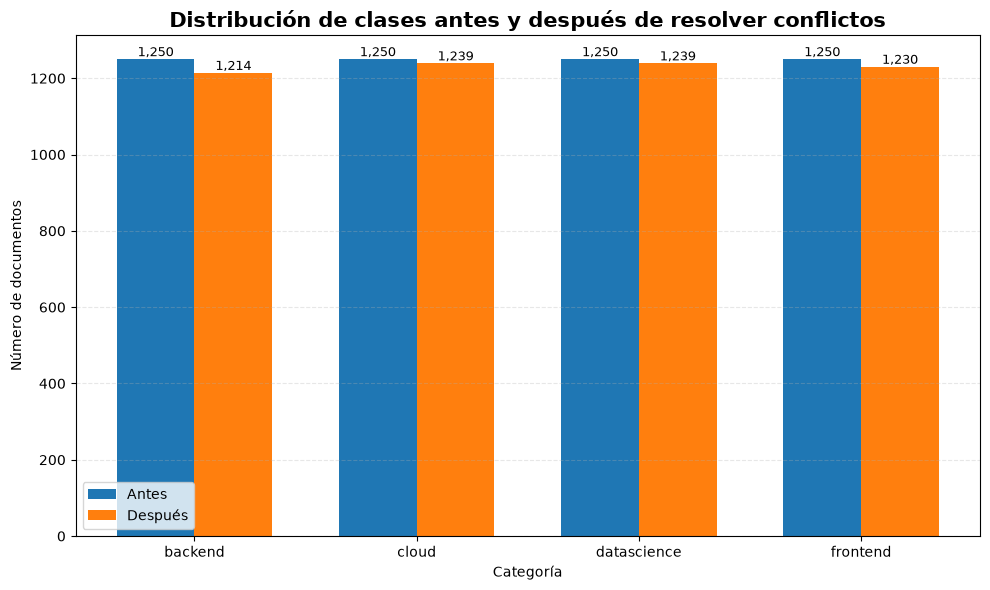

In [178]:
# ==============================================================================
# CELDA 58
# VISUALIZACIÓN DEL BALANCE
# ==============================================================================

categorias = comparacion_balance.index
posiciones = np.arange(len(categorias))
ancho = 0.35

plt.figure(figsize=(10, 6))

barras_antes = plt.bar(
    posiciones - ancho / 2,
    comparacion_balance["Antes"],
    width=ancho,
    label="Antes"
)

barras_despues = plt.bar(
    posiciones + ancho / 2,
    comparacion_balance["Despues"],
    width=ancho,
    label="Después"
)

plt.xticks(
    posiciones,
    categorias
)

plt.title(
    "Distribución de clases antes y después de resolver conflictos",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Categoría")
plt.ylabel("Número de documentos")
plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for grupo_barras in [
    barras_antes,
    barras_despues
]:

    for barra in grupo_barras:

        altura = barra.get_height()

        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura,
            f"{int(altura):,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [179]:
# ==============================================================================
# CELDA 59
# VALIDACIÓN POSTERIOR
# ==============================================================================

conflictos_restantes = (
    df_modelado
    .groupby(COLUMNA_TEXTO_MODELO)[COLUMNA_OBJETIVO]
    .nunique()
    .gt(1)
    .sum()
)

documentos_vacios_modelado = int(
    df_modelado[COLUMNA_TEXTO_MODELO]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("=" * 80)
print("VALIDACIÓN DEL DATASET PARA MODELADO")
print("=" * 80)

print(
    f"Conflictos de etiqueta restantes: "
    f"{conflictos_restantes:,}"
)

print(
    f"Documentos vacíos: "
    f"{documentos_vacios_modelado:,}"
)

if (
    conflictos_restantes == 0
    and documentos_vacios_modelado == 0
):
    print("""
El dataset para modelado ya no contiene textos idénticos asociados con
categorías distintas y conserva contenido textual válido.
""")
else:
    print("""
ADVERTENCIA: el dataset todavía contiene inconsistencias que deben revisarse.
""")

VALIDACIÓN DEL DATASET PARA MODELADO
Conflictos de etiqueta restantes: 0
Documentos vacíos: 0

El dataset para modelado ya no contiene textos idénticos asociados con
categorías distintas y conserva contenido textual válido.



In [180]:
# ==============================================================================
# CELDA 60
# CONCLUSIÓN DE LA CELDA 12
# ==============================================================================

porcentaje_conservado = (
    len(df_modelado)
    / len(df)
    * 100
)

diferencia_maxima_clases = (
    comparacion_balance["Despues"].max()
    - comparacion_balance["Despues"].min()
)

print("=" * 80)
print("CONCLUSIÓN DE LA RESOLUCIÓN DE CONFLICTOS")
print("=" * 80)

print(
    f"Textos conflictivos identificados: "
    f"{cantidad_textos_conflictivos:,}"
)

print(
    f"Registros separados: "
    f"{cantidad_registros_conflictivos:,}"
)

print(
    f"Porcentaje de datos conservado: "
    f"{porcentaje_conservado:.2f} %"
)

print(
    f"Diferencia máxima entre clases: "
    f"{diferencia_maxima_clases:,} registros"
)

if (
    conflictos_restantes == 0
    and porcentaje_conservado >= 95
):

    print("""
Los textos con etiquetas contradictorias fueron separados de forma controlada.
La gran mayoría de los datos permanece disponible y el dataset resultante puede
continuar con la ingeniería de características y la detección de duplicados
consistentes.
""")

else:

    print("""
La separación fue completada, pero conviene revisar el impacto sobre el tamaño
y el balance de las clases antes de continuar.
""")

CONCLUSIÓN DE LA RESOLUCIÓN DE CONFLICTOS
Textos conflictivos identificados: 27
Registros separados: 78
Porcentaje de datos conservado: 98.44 %
Diferencia máxima entre clases: 25 registros

Los textos con etiquetas contradictorias fueron separados de forma controlada.
La gran mayoría de los datos permanece disponible y el dataset resultante puede
continuar con la ingeniería de características y la detección de duplicados
consistentes.



In [181]:
# ==============================================================================
# CELDA 61
# DETECCIÓN Y TRATAMIENTO DE DUPLICADOS CONSISTENTES
# ==============================================================================

print("=" * 80)
print("ANÁLISIS DE DUPLICADOS EN EL DATASET DE MODELADO")
print("=" * 80)

VARIANTES_DUPLICADOS = [
    "texto_modelo_base",
    "texto_modelo_titulo",
    "texto_combinado",
    "texto_combinado_ponderado"
]

resumen_duplicados_variantes = []

for columna in VARIANTES_DUPLICADOS:

    # Registros que forman parte de algún grupo duplicado
    mascara_duplicados = df_modelado.duplicated(
        subset=[columna],
        keep=False
    )

    registros_involucrados = int(
        mascara_duplicados.sum()
    )

    # Cantidad de valores repetidos únicos
    grupos_duplicados = int(
        df_modelado.loc[
            mascara_duplicados,
            columna
        ].nunique()
    )

    # Filas redundantes que desaparecerían conservando una copia
    filas_redundantes = int(
        df_modelado.duplicated(
            subset=[columna],
            keep="first"
        ).sum()
    )

    resumen_duplicados_variantes.append({
        "Variable": columna,
        "Textos_unicos": df_modelado[columna].nunique(),
        "Grupos_duplicados": grupos_duplicados,
        "Registros_involucrados": registros_involucrados,
        "Filas_redundantes": filas_redundantes,
        "Porcentaje_involucrado": round(
            registros_involucrados / len(df_modelado) * 100,
            2
        )
    })

df_resumen_duplicados = pd.DataFrame(
    resumen_duplicados_variantes
)

display(df_resumen_duplicados)

ANÁLISIS DE DUPLICADOS EN EL DATASET DE MODELADO


,Variable,Textos_unicos,Grupos_duplicados,Registros_involucrados,Filas_redundantes,Porcentaje_involucrado
0,texto_modelo_base,4525,348,745,397,15.14
1,texto_modelo_titulo,4583,327,666,339,13.53
2,texto_combinado,4583,327,666,339,13.53
3,texto_combinado_ponderado,4583,327,666,339,13.53


In [182]:
# ==============================================================================
# CELDA 62
# CONFIGURACIÓN DE LA DEDUPLICACIÓN
# ==============================================================================

COLUMNA_DEDUPLICACION = "texto_combinado"
COLUMNA_OBJETIVO = "categoria"

mascara_duplicados_consistentes = (
    df_modelado.duplicated(
        subset=[
            COLUMNA_DEDUPLICACION,
            COLUMNA_OBJETIVO
        ],
        keep=False
    )
)

cantidad_registros_duplicados = int(
    mascara_duplicados_consistentes.sum()
)

cantidad_filas_redundantes = int(
    df_modelado.duplicated(
        subset=[
            COLUMNA_DEDUPLICACION,
            COLUMNA_OBJETIVO
        ],
        keep="first"
    ).sum()
)

cantidad_grupos_duplicados = int(
    df_modelado.loc[
        mascara_duplicados_consistentes,
        COLUMNA_DEDUPLICACION
    ].nunique()
)

print("=" * 80)
print("DUPLICADOS CONSISTENTES")
print("=" * 80)

print(
    f"Grupos de textos duplicados: "
    f"{cantidad_grupos_duplicados:,}"
)

print(
    f"Registros involucrados: "
    f"{cantidad_registros_duplicados:,}"
)

print(
    f"Filas redundantes: "
    f"{cantidad_filas_redundantes:,}"
)

print(
    f"Porcentaje de filas redundantes: "
    f"{cantidad_filas_redundantes / len(df_modelado) * 100:.2f} %"
)

DUPLICADOS CONSISTENTES
Grupos de textos duplicados: 327
Registros involucrados: 666
Filas redundantes: 339
Porcentaje de filas redundantes: 6.89 %


In [183]:
# ==============================================================================
# CELDA 63
# RESUMEN DE LOS GRUPOS DUPLICADOS
# ==============================================================================

resumen_grupos_duplicados = (
    df_modelado.loc[
        mascara_duplicados_consistentes
    ]
    .groupby(
        [
            COLUMNA_DEDUPLICACION,
            COLUMNA_OBJETIVO
        ]
    )
    .agg(
        cantidad_repeticiones=(
            COLUMNA_OBJETIVO,
            "size"
        ),
        titulos_originales=(
            "titulo_original",
            lambda serie: list(
                dict.fromkeys(
                    serie.dropna()
                         .astype(str)
                         .tolist()
                )
            )[:5]
        ),
        palabras_clave=(
            "palabras_clave_texto",
            lambda serie: list(
                dict.fromkeys(
                    serie.dropna()
                         .astype(str)
                         .tolist()
                )
            )[:5]
        )
    )
    .reset_index()
    .sort_values(
        "cantidad_repeticiones",
        ascending=False
    )
)

print("\nResumen de grupos duplicados:")

display(
    resumen_grupos_duplicados[
        [
            COLUMNA_OBJETIVO,
            "cantidad_repeticiones",
            "titulos_originales",
            "palabras_clave",
            COLUMNA_DEDUPLICACION
        ]
    ].head(30)
)


Resumen de grupos duplicados:


,categoria,cantidad_repeticiones,titulos_originales,palabras_clave,texto_combinado
253,cloud,5,[Why I Recommend Alibaba Cloud ECS for Developers in 2026],[],why i recommend alibaba cloud ecs for developers in 2026 why i recommend alibaba cloud ecs for developers in 2026 as a developer who has tested.
282,datascience,3,[Your Pipeline Is 21.7h Behind: Catching Mobile Sentiment Leads with Pulsebit],[21.7h],your pipeline is 21.7h behind: catching mobile sentiment leads with pulsebit your pipeline is 21.7h behind: catching mobile sentiment leads with p...
318,datascience,3,[Your Pipeline Is 28.3h Behind: Catching Defence Sentiment Leads with Pulsebit],[28.3h],your pipeline is 28.3h behind: catching defence sentiment leads with pulsebit your pipeline is 28.3h behind: catching defence sentiment leads with...
109,cloud,3,[How Alibaba Cloud CDN Accelerates Your Global Applications],[asia],how alibaba cloud cdn accelerates your global applications how alibaba cloud cdn accelerates your global applications if your users are in asia asia
214,backend,3,[The Cryptographic Crucible: Why Most Altcoins Eventually Disappear],[],the cryptographic crucible: why most altcoins eventually disappear your blockchain app will not die from a bad idea. it will die from a backpressure.
14,cloud,3,[AI Revolutionizes SaaS],[software the ai revolution],ai revolutionizes saas introduction to the ai revolution in saas the world of software as a service saas has. software the ai revolution
116,frontend,3,[How to do code review that helps your team grow],[code],how to do code review that helps your team grow how to do code review that helps your team grow code review is the most effective quality. code
321,datascience,3,[Your Pipeline Is 29.2h Behind: Catching World Sentiment Leads with Pulsebit],[29.2h],your pipeline is 29.2h behind: catching world sentiment leads with pulsebit your pipeline is 29.2h behind: catching world sentiment leads with pul...
165,backend,3,[Mitigating Race Conditions in Distributed Inventory Ledgers],[],mitigating race conditions in distributed inventory ledgers when building a system that tracks highly volatile mutable data across multiple distin...
245,backend,3,[Web Developer Travis McCracken on Using SQLite for Local Testing],[the power of backend development],web developer travis mccracken on using sqlite for local testing unlocking the power of backend development with rust and go: insights from web de...


In [184]:
# ==============================================================================
# CELDA 64
# DUPLICADOS POR CATEGORÍA
# ==============================================================================

duplicados_por_categoria = (
    df_modelado.loc[
        mascara_duplicados_consistentes
    ]
    .groupby(COLUMNA_OBJETIVO)
    .size()
    .rename("Registros_involucrados")
    .to_frame()
)

filas_redundantes_categoria = (
    df_modelado.loc[
        df_modelado.duplicated(
            subset=[
                COLUMNA_DEDUPLICACION,
                COLUMNA_OBJETIVO
            ],
            keep="first"
        )
    ]
    .groupby(COLUMNA_OBJETIVO)
    .size()
    .rename("Filas_redundantes")
)

duplicados_por_categoria = (
    duplicados_por_categoria
    .join(
        filas_redundantes_categoria,
        how="outer"
    )
    .fillna(0)
    .astype(int)
)

duplicados_por_categoria["Total_categoria"] = (
    df_modelado[COLUMNA_OBJETIVO]
    .value_counts()
)

duplicados_por_categoria["Porcentaje_redundante"] = (
    duplicados_por_categoria["Filas_redundantes"]
    .div(duplicados_por_categoria["Total_categoria"])
    .mul(100)
    .round(2)
)

duplicados_por_categoria.index.name = "Categoria"

display(duplicados_por_categoria)

,Registros_involucrados,Filas_redundantes,Total_categoria,Porcentaje_redundante
Categoria,,,,
backend,107,55,1214,4.53
cloud,159,82,1239,6.62
datascience,271,137,1239,11.06
frontend,129,65,1230,5.28


In [185]:
# ==============================================================================
# CELDA 65
# DATASET DE AUDITORÍA DE DUPLICADOS
# ==============================================================================

columnas_auditoria_duplicados = [
    "categoria",
    "titulo_original",
    "texto_original",
    "palabras_clave_original",
    "titulo_limpio",
    "texto_limpio",
    "palabras_clave_limpias",
    "texto_combinado"
]

columnas_auditoria_duplicados = [
    columna
    for columna in columnas_auditoria_duplicados
    if columna in df_modelado.columns
]

df_duplicados_consistentes = (
    df_modelado.loc[
        mascara_duplicados_consistentes,
        columnas_auditoria_duplicados
    ]
    .copy()
    .sort_values(
        [
            "texto_combinado",
            "categoria"
        ]
    )
    .reset_index(drop=True)
)

print(
    f"Registros conservados para auditoría: "
    f"{len(df_duplicados_consistentes):,}"
)

Registros conservados para auditoría: 666


In [186]:
# ==============================================================================
# CELDA 66
# CREACIÓN DEL DATASET SIN DUPLICADOS EXACTOS
# ==============================================================================

df_modelado_unico = (
    df_modelado
    .drop_duplicates(
        subset=[
            COLUMNA_DEDUPLICACION,
            COLUMNA_OBJETIVO
        ],
        keep="first"
    )
    .copy()
    .reset_index(drop=True)
)

print("=" * 80)
print("RESULTADO DE LA DEDUPLICACIÓN")
print("=" * 80)

print(
    f"Registros antes:   "
    f"{len(df_modelado):,}"
)

print(
    f"Registros después: "
    f"{len(df_modelado_unico):,}"
)

print(
    f"Filas eliminadas:  "
    f"{len(df_modelado) - len(df_modelado_unico):,}"
)

print(
    f"Datos conservados: "
    f"{len(df_modelado_unico) / len(df_modelado) * 100:.2f} %"
)

RESULTADO DE LA DEDUPLICACIÓN
Registros antes:   4,922
Registros después: 4,583
Filas eliminadas:  339
Datos conservados: 93.11 %


In [187]:
# ==============================================================================
# CELDA 67
# COMPARACIÓN DEL BALANCE DE CLASES
# ==============================================================================

balance_antes_duplicados = (
    df_modelado["categoria"]
    .value_counts()
    .sort_index()
)

balance_despues_duplicados = (
    df_modelado_unico["categoria"]
    .value_counts()
    .sort_index()
)

comparacion_balance_duplicados = pd.DataFrame({
    "Antes": balance_antes_duplicados,
    "Despues": balance_despues_duplicados
}).fillna(0).astype(int)

comparacion_balance_duplicados["Filas_eliminadas"] = (
    comparacion_balance_duplicados["Antes"]
    - comparacion_balance_duplicados["Despues"]
)

comparacion_balance_duplicados["Porcentaje_conservado"] = (
    comparacion_balance_duplicados["Despues"]
    .div(comparacion_balance_duplicados["Antes"])
    .mul(100)
    .round(2)
)

comparacion_balance_duplicados.index.name = "Categoria"

display(comparacion_balance_duplicados)

,Antes,Despues,Filas_eliminadas,Porcentaje_conservado
Categoria,,,,
backend,1214,1159,55,95.47
cloud,1239,1157,82,93.38
datascience,1239,1102,137,88.94
frontend,1230,1165,65,94.72


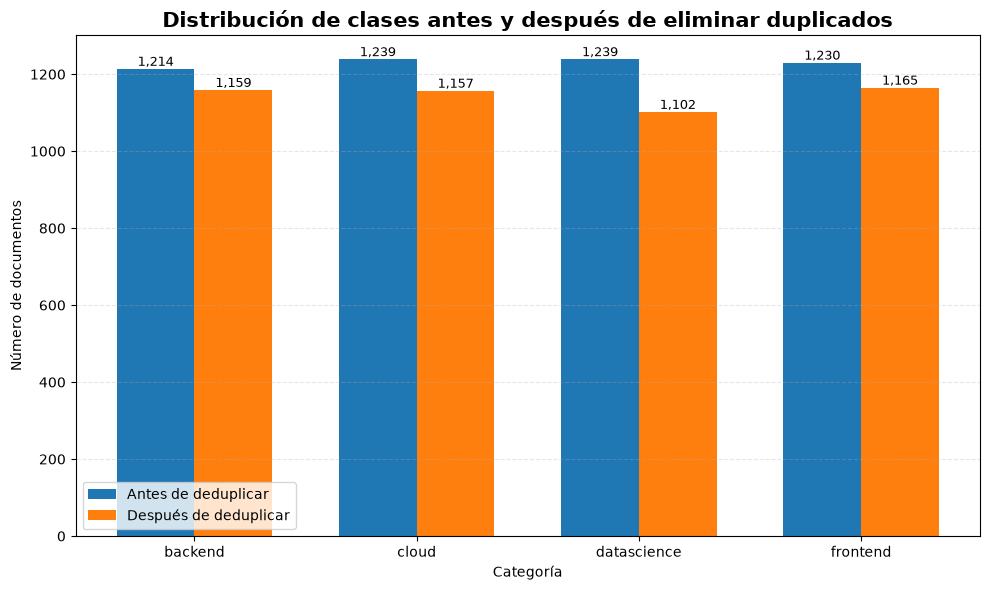

In [188]:
# ==============================================================================
# CELDA 68
# GRÁFICO DEL BALANCE ANTES Y DESPUÉS
# ==============================================================================

categorias = comparacion_balance_duplicados.index
posiciones = np.arange(len(categorias))
ancho = 0.35

plt.figure(figsize=(10, 6))

barras_antes = plt.bar(
    posiciones - ancho / 2,
    comparacion_balance_duplicados["Antes"],
    width=ancho,
    label="Antes de deduplicar"
)

barras_despues = plt.bar(
    posiciones + ancho / 2,
    comparacion_balance_duplicados["Despues"],
    width=ancho,
    label="Después de deduplicar"
)

plt.xticks(
    posiciones,
    categorias
)

plt.title(
    "Distribución de clases antes y después de eliminar duplicados",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Categoría")
plt.ylabel("Número de documentos")

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for grupo_barras in [
    barras_antes,
    barras_despues
]:

    for barra in grupo_barras:

        altura = barra.get_height()

        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura,
            f"{int(altura):,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [189]:
# ==============================================================================
# CELDA 69
# VALIDACIÓN POSTERIOR A LA DEDUPLICACIÓN
# ==============================================================================

duplicados_restantes = int(
    df_modelado_unico.duplicated(
        subset=[
            COLUMNA_DEDUPLICACION,
            COLUMNA_OBJETIVO
        ],
        keep=False
    ).sum()
)

conflictos_restantes = int(
    df_modelado_unico
    .groupby(COLUMNA_DEDUPLICACION)[COLUMNA_OBJETIVO]
    .nunique()
    .gt(1)
    .sum()
)

documentos_vacios = int(
    df_modelado_unico[COLUMNA_DEDUPLICACION]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("=" * 80)
print("VALIDACIÓN DEL DATASET ÚNICO")
print("=" * 80)

print(
    f"Duplicados exactos restantes: "
    f"{duplicados_restantes:,}"
)

print(
    f"Conflictos de categoría restantes: "
    f"{conflictos_restantes:,}"
)

print(
    f"Documentos vacíos: "
    f"{documentos_vacios:,}"
)

if (
    duplicados_restantes == 0
    and conflictos_restantes == 0
    and documentos_vacios == 0
):
    print("""
El dataset quedó libre de duplicados exactos, conflictos de etiqueta y
documentos vacíos. Los datos pueden avanzar a la etapa de ingeniería de
características.
""")
else:
    print("""
ADVERTENCIA: todavía existen inconsistencias que deben revisarse antes del
entrenamiento.
""")

VALIDACIÓN DEL DATASET ÚNICO
Duplicados exactos restantes: 0
Conflictos de categoría restantes: 0
Documentos vacíos: 0

El dataset quedó libre de duplicados exactos, conflictos de etiqueta y
documentos vacíos. Los datos pueden avanzar a la etapa de ingeniería de
características.



In [190]:
# ==============================================================================
# CELDA 70
# CONCLUSIÓN DE LA VALIDACIÓN DE DUPLICADOS
# ==============================================================================

porcentaje_conservado = (
    len(df_modelado_unico)
    / len(df_modelado)
    * 100
)

diferencia_maxima_clases = (
    comparacion_balance_duplicados["Despues"].max()
    - comparacion_balance_duplicados["Despues"].min()
)

print("=" * 80)
print("CONCLUSIÓN DEL ANÁLISIS DE DUPLICADOS")
print("=" * 80)

print(
    f"Grupos duplicados identificados: "
    f"{cantidad_grupos_duplicados:,}"
)

print(
    f"Filas redundantes eliminadas: "
    f"{cantidad_filas_redundantes:,}"
)

print(
    f"Porcentaje conservado: "
    f"{porcentaje_conservado:.2f} %"
)

print(
    f"Diferencia máxima entre clases: "
    f"{diferencia_maxima_clases:,} registros"
)

if (
    duplicados_restantes == 0
    and conflictos_restantes == 0
    and porcentaje_conservado >= 90
):
    print("""
Los duplicados exactos fueron eliminados de forma controlada. El dataset
resultante conserva la mayor parte de la información y reduce el riesgo de fuga
de datos durante la evaluación del modelo.
""")
else:
    print("""
La deduplicación fue completada, pero debe revisarse su impacto sobre el tamaño
y el balance de las clases.
""")

CONCLUSIÓN DEL ANÁLISIS DE DUPLICADOS
Grupos duplicados identificados: 327
Filas redundantes eliminadas: 339
Porcentaje conservado: 93.11 %
Diferencia máxima entre clases: 63 registros

Los duplicados exactos fueron eliminados de forma controlada. El dataset
resultante conserva la mayor parte de la información y reduce el riesgo de fuga
de datos durante la evaluación del modelo.



In [191]:
# ==============================================================================
# CELDA 71
# INGENIERÍA DE CARACTERÍSTICAS
# ==============================================================================

print("=" * 80)
print("INGENIERÍA DE CARACTERÍSTICAS")
print("=" * 80)

# Copia de trabajo
df_features = df_modelado_unico.copy()

# ------------------------------------------------------------------------------
# Vocabulario técnico de referencia
# ------------------------------------------------------------------------------

TERMINOS_TECNICOS = {
    # Backend
    "api",
    "rest",
    "graphql",
    "fastapi",
    "django",
    "flask",
    "spring",
    "java",
    "node.js",
    "express",
    "microservices",
    "database",
    "sql",
    "postgresql",
    "mysql",
    "mongodb",

    # Frontend
    "html",
    "css",
    "javascript",
    "typescript",
    "react",
    "react.js",
    "angular",
    "vue",
    "vue.js",
    "next.js",
    "frontend",
    "responsive",
    "component",
    "dom",

    # Cloud
    "aws",
    "azure",
    "oci",
    "gcp",
    "docker",
    "kubernetes",
    "terraform",
    "cloud",
    "devops",
    "serverless",
    "container",
    "ci/cd",
    "deployment",

    # Data Science
    "python",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "pytorch",
    "machine learning",
    "deep learning",
    "data science",
    "nlp",
    "model",
    "classification",
    "regression",
    "dataset",
    "ai",
    "llm"
}

INGENIERÍA DE CARACTERÍSTICAS


In [192]:
# ==============================================================================
# CELDA 72
# FUNCIONES PARA LA EXTRACCIÓN DE CARACTERÍSTICAS
# ==============================================================================

def contar_caracteres(valor):
    """
    Cuenta los caracteres de un texto.
    """

    if valor is None or pd.isna(valor):
        return 0

    return len(str(valor))


def longitud_promedio_palabras(valor):
    """
    Calcula la longitud promedio de los tokens técnicos de un texto.
    """

    if valor is None or pd.isna(valor):
        return 0.0

    texto = str(valor)

    tokens = PATRON_TOKEN_TECNICO.findall(
        texto
    )

    if not tokens:
        return 0.0

    return round(
        sum(len(token) for token in tokens) / len(tokens),
        2
    )


def proporcion_digitos(valor):
    """
    Calcula la proporción de caracteres numéricos del texto.
    """

    if valor is None or pd.isna(valor):
        return 0.0

    texto = str(valor)

    if not texto:
        return 0.0

    cantidad_digitos = sum(
        caracter.isdigit()
        for caracter in texto
    )

    return round(
        cantidad_digitos / len(texto),
        4
    )


def contar_versiones(valor):
    """
    Cuenta patrones de versiones tecnológicas.

    Ejemplos:
    3.12
    1.0.5
    v2.0
    version 4.1
    """

    if valor is None or pd.isna(valor):
        return 0

    texto = str(valor).lower()

    patron_version = r"""
        (?:
            \bv?\d+\.\d+(?:\.\d+)*\b
            |
            \bversion\s+\d+(?:\.\d+)*\b
        )
    """

    return len(
        re.findall(
            patron_version,
            texto,
            flags=re.VERBOSE
        )
    )


def contar_urls(valor):
    """
    Cuenta URLs presentes en el texto original.
    """

    if valor is None or pd.isna(valor):
        return 0

    return len(
        re.findall(
            r"https?://\S+|www\.\S+",
            str(valor),
            flags=re.IGNORECASE
        )
    )


def contar_etiquetas_html(valor):
    """
    Cuenta etiquetas HTML presentes en el contenido original.
    """

    if valor is None or pd.isna(valor):
        return 0

    return len(
        re.findall(
            r"<[^>]+>",
            str(valor)
        )
    )


def contar_simbolos_codigo(valor):
    """
    Cuenta símbolos asociados frecuentemente con fragmentos de código.
    """

    if valor is None or pd.isna(valor):
        return 0

    texto = str(valor)

    simbolos = "{}[]();=<>"

    return sum(
        texto.count(simbolo)
        for simbolo in simbolos
    )


def contar_terminos_tecnicos(valor):
    """
    Cuenta términos técnicos distintos presentes en un documento.
    """

    if valor is None or pd.isna(valor):
        return 0

    texto = str(valor).lower()

    encontrados = {
        termino
        for termino in TERMINOS_TECNICOS
        if termino in texto
    }

    return len(encontrados)


def densidad_terminos_tecnicos(valor):
    """
    Calcula la proporción de términos técnicos respecto al total de tokens.
    """

    cantidad_palabras = contar_palabras(
        valor
    )

    if cantidad_palabras == 0:
        return 0.0

    cantidad_tecnicos = contar_terminos_tecnicos(
        valor
    )

    return round(
        cantidad_tecnicos / cantidad_palabras,
        4
    )

In [193]:
# ==============================================================================
# CELDA 73
# CARACTERÍSTICAS DE LONGITUD
# ==============================================================================

df_features["titulo_num_caracteres"] = (
    df_features["titulo_limpio"]
    .apply(contar_caracteres)
)

df_features["titulo_num_palabras"] = (
    df_features["titulo_limpio"]
    .apply(contar_palabras)
)

df_features["texto_num_caracteres"] = (
    df_features["texto_limpio"]
    .apply(contar_caracteres)
)

df_features["texto_num_palabras"] = (
    df_features["texto_limpio"]
    .apply(contar_palabras)
)

df_features["combinado_num_caracteres"] = (
    df_features["texto_combinado"]
    .apply(contar_caracteres)
)

df_features["combinado_num_palabras"] = (
    df_features["texto_combinado"]
    .apply(contar_palabras)
)

df_features["num_palabras_clave"] = (
    df_features["palabras_clave_limpias"]
    .apply(len)
)

In [194]:
# ==============================================================================
# CELDA 74
# CARACTERÍSTICAS LINGÜÍSTICAS Y TÉCNICAS
# ==============================================================================

df_features["longitud_promedio_palabra"] = (
    df_features["texto_combinado"]
    .apply(longitud_promedio_palabras)
)

df_features["proporcion_digitos"] = (
    df_features["texto_combinado"]
    .apply(proporcion_digitos)
)

df_features["cantidad_versiones"] = (
    df_features["texto_combinado"]
    .apply(contar_versiones)
)

df_features["cantidad_terminos_tecnicos"] = (
    df_features["texto_combinado"]
    .apply(contar_terminos_tecnicos)
)

df_features["densidad_terminos_tecnicos"] = (
    df_features["texto_combinado"]
    .apply(densidad_terminos_tecnicos)
)

In [195]:
# ==============================================================================
# CELDA 75
# CARACTERÍSTICAS DEL CONTENIDO ORIGINAL
# ==============================================================================

df_features["cantidad_urls"] = (
    df_features["texto_original"]
    .apply(contar_urls)
)

df_features["cantidad_etiquetas_html"] = (
    df_features["texto_original"]
    .apply(contar_etiquetas_html)
)

df_features["cantidad_simbolos_codigo"] = (
    df_features["texto_original"]
    .apply(contar_simbolos_codigo)
)

In [196]:
# ==============================================================================
# CELDA 76
# INDICADORES BINARIOS
# ==============================================================================

df_features["tiene_palabras_clave"] = (
    df_features["num_palabras_clave"] > 0
).astype(int)

df_features["tiene_version"] = (
    df_features["cantidad_versiones"] > 0
).astype(int)

df_features["tiene_url"] = (
    df_features["cantidad_urls"] > 0
).astype(int)

df_features["tiene_html"] = (
    df_features["cantidad_etiquetas_html"] > 0
).astype(int)

df_features["tiene_codigo"] = (
    df_features["cantidad_simbolos_codigo"] > 0
).astype(int)

df_features["tiene_terminos_tecnicos"] = (
    df_features["cantidad_terminos_tecnicos"] > 0
).astype(int)

In [197]:
# ==============================================================================
# CELDA 77
# LISTA DE VARIABLES NUMÉRICAS
# ==============================================================================

COLUMNAS_FEATURES_NUMERICAS = [
    "titulo_num_caracteres",
    "titulo_num_palabras",
    "texto_num_caracteres",
    "texto_num_palabras",
    "combinado_num_caracteres",
    "combinado_num_palabras",
    "num_palabras_clave",
    "longitud_promedio_palabra",
    "proporcion_digitos",
    "cantidad_versiones",
    "cantidad_terminos_tecnicos",
    "densidad_terminos_tecnicos",
    "cantidad_urls",
    "cantidad_etiquetas_html",
    "cantidad_simbolos_codigo",
    "tiene_palabras_clave",
    "tiene_version",
    "tiene_url",
    "tiene_html",
    "tiene_codigo",
    "tiene_terminos_tecnicos"
]

print(
    f"Características creadas: "
    f"{len(COLUMNAS_FEATURES_NUMERICAS)}"
)

print("\nVariables generadas:")

for columna in COLUMNAS_FEATURES_NUMERICAS:
    print(f"• {columna}")

Características creadas: 21

Variables generadas:
• titulo_num_caracteres
• titulo_num_palabras
• texto_num_caracteres
• texto_num_palabras
• combinado_num_caracteres
• combinado_num_palabras
• num_palabras_clave
• longitud_promedio_palabra
• proporcion_digitos
• cantidad_versiones
• cantidad_terminos_tecnicos
• densidad_terminos_tecnicos
• cantidad_urls
• cantidad_etiquetas_html
• cantidad_simbolos_codigo
• tiene_palabras_clave
• tiene_version
• tiene_url
• tiene_html
• tiene_codigo
• tiene_terminos_tecnicos


In [198]:
# ==============================================================================
# CELDA 78
# MUESTRA DE LAS CARACTERÍSTICAS
# ==============================================================================

columnas_muestra_features = [
    "categoria",
    "titulo_limpio",
    "texto_combinado",
    "titulo_num_palabras",
    "texto_num_palabras",
    "combinado_num_palabras",
    "num_palabras_clave",
    "cantidad_versiones",
    "cantidad_terminos_tecnicos",
    "densidad_terminos_tecnicos",
    "tiene_codigo"
]

display(
    df_features[
        columnas_muestra_features
    ]
    .sample(
        n=min(10, len(df_features)),
        random_state=RANDOM_STATE
    )
)

,categoria,titulo_limpio,texto_combinado,titulo_num_palabras,texto_num_palabras,combinado_num_palabras,num_palabras_clave,cantidad_versiones,cantidad_terminos_tecnicos,densidad_terminos_tecnicos,tiene_codigo
1207,frontend,component-nesting-and-composition,component-nesting-and-composition component nesting and composition in euv project. component nesting,1,7,10,1,0,1,0.10,0
3910,frontend,component deep dive #23: infinite scroll-never show a next page button again,component deep dive #23: infinite scroll-never show a next page button again web component dictionary v2.0-83 components bilingual live preview li...,12,12,26,2,1,2,0.08,0
1183,cloud,railway vs render: the practical paas alternative i d choose before staying on railway,railway vs render: the practical paas alternative i d choose before staying on railway tl dr i no longer recommend railway as the default for seri...,14,14,29,1,0,1,0.03,1
100,frontend,building a personal engineering portfolio that actually advances your career,building a personal engineering portfolio that actually advances your career building a personal engineering portfolio that actually advances your...,10,10,20,0,0,0,0.00,0
3879,frontend,html forms and their elements,html forms and their elements html forms and common form tags html forms are used to collect information from users.,5,15,20,0,0,1,0.05,0
2684,frontend,numeric sort methods in javascript,numeric sort methods in javascript 1. numeric sort numeric sorting arranges numbers in ascending or descending. numeric sort,5,11,18,1,0,2,0.11,0
69,backend,the quest for digital fiat: can cryptocurrencies truly fulfill the promise of money,the quest for digital fiat: can cryptocurrencies truly fulfill the promise of money why decentralisation is a bug not a feature when you re trying...,13,18,31,0,0,0,0.00,0
1580,backend,cómo auditar emails de upgrade en saas,cómo auditar emails de upgrade en saas guía práctica para revisar emails de upgrade en saas con cohortes claras eventos confiables y menos ruido o...,7,18,26,1,0,1,0.04,0
468,datascience,mjallby aif vs vasteras sk fk: match prediction model analysis 2026-07-17,mjallby aif vs vasteras sk fk: match prediction model analysis 2026-07-17 published: 2026-07-16 footballmoney.top mjallby aif vs vasteras sk fk wo...,11,11,28,3,0,3,0.11,0
3248,cloud,kubernetes as your ai control plane: running claude and ollama agents with kagent,kubernetes as your ai control plane: running claude and ollama agents with kagent hey there if you run a homelab you already have a kubernetes clu...,13,15,29,1,0,2,0.07,0


In [199]:
# ==============================================================================
# CELDA 79
# ESTADÍSTICAS DESCRIPTIVAS
# ==============================================================================

estadisticas_features = (
    df_features[
        COLUMNAS_FEATURES_NUMERICAS
    ]
    .describe()
    .T
    .round(3)
)

print("Estadísticas descriptivas de las características:")

display(estadisticas_features)

Estadísticas descriptivas de las características:


,count,mean,std,min,25%,50%,75%,max
titulo_num_caracteres,"4,583.00",63.94,21.47,0.00,51.00,65.00,77.00,254.00
titulo_num_palabras,"4,583.00",10.00,3.59,0.00,8.00,10.00,12.00,39.00
texto_num_caracteres,"4,583.00",98.54,26.78,31.00,87.00,95.00,99.00,377.00
texto_num_palabras,"4,583.00",15.89,5.00,0.00,13.00,15.00,18.00,56.00
combinado_num_caracteres,"4,583.00",174.96,38.59,42.00,153.00,171.00,191.00,459.00
combinado_num_palabras,"4,583.00",27.65,7.11,1.00,24.00,27.00,31.00,74.00
num_palabras_clave,"4,583.00",1.05,1.13,0.00,0.00,1.00,2.00,7.00
longitud_promedio_palabra,"4,583.00",5.37,0.92,1.83,4.72,5.28,5.88,9.67
proporcion_digitos,"4,583.00",0.02,0.04,0.00,0.00,0.00,0.02,0.25
cantidad_versiones,"4,583.00",0.08,0.39,0.00,0.00,0.00,0.00,6.00


In [200]:
# ==============================================================================
# CELDA 80
# VALIDACIÓN DE VALORES NULOS E INFINITOS
# ==============================================================================

resumen_calidad_features = pd.DataFrame({
    "Nulos": (
        df_features[
            COLUMNAS_FEATURES_NUMERICAS
        ]
        .isna()
        .sum()
    ),
    "Infinitos": [
        np.isinf(
            pd.to_numeric(
                df_features[columna],
                errors="coerce"
            )
        ).sum()
        for columna in COLUMNAS_FEATURES_NUMERICAS
    ],
    "Valores_unicos": (
        df_features[
            COLUMNAS_FEATURES_NUMERICAS
        ]
        .nunique()
    )
})

display(resumen_calidad_features)

total_nulos = int(
    resumen_calidad_features["Nulos"].sum()
)

total_infinitos = int(
    resumen_calidad_features["Infinitos"].sum()
)

print(
    f"Total de valores nulos: "
    f"{total_nulos:,}"
)

print(
    f"Total de valores infinitos: "
    f"{total_infinitos:,}"
)

,Nulos,Infinitos,Valores_unicos
titulo_num_caracteres,0,0,138
titulo_num_palabras,0,0,29
texto_num_caracteres,0,0,203
texto_num_palabras,0,0,52
combinado_num_caracteres,0,0,264
combinado_num_palabras,0,0,67
num_palabras_clave,0,0,8
longitud_promedio_palabra,0,0,450
proporcion_digitos,0,0,568
cantidad_versiones,0,0,7


Total de valores nulos: 0
Total de valores infinitos: 0


In [201]:
# ==============================================================================
# CELDA 81
# PROMEDIO DE CARACTERÍSTICAS POR CATEGORÍA
# ==============================================================================

features_categoria = (
    df_features
    .groupby("categoria")[
        [
            "titulo_num_palabras",
            "texto_num_palabras",
            "num_palabras_clave",
            "longitud_promedio_palabra",
            "proporcion_digitos",
            "cantidad_versiones",
            "cantidad_terminos_tecnicos",
            "densidad_terminos_tecnicos",
            "cantidad_urls",
            "cantidad_etiquetas_html",
            "cantidad_simbolos_codigo"
        ]
    ]
    .mean()
    .round(3)
)

print(
    "Promedio de características por categoría:"
)

display(features_categoria)

Promedio de características por categoría:


,titulo_num_palabras,texto_num_palabras,num_palabras_clave,longitud_promedio_palabra,proporcion_digitos,cantidad_versiones,cantidad_terminos_tecnicos,densidad_terminos_tecnicos,cantidad_urls,cantidad_etiquetas_html,cantidad_simbolos_codigo
categoria,,,,,,,,,,,
backend,9.68,17.20,0.95,5.18,0.01,0.03,0.93,0.03,0.01,0.00,0.19
cloud,9.71,16.35,1.21,5.29,0.02,0.14,1.58,0.06,0.00,0.00,0.30
datascience,11.11,15.14,1.24,5.52,0.04,0.10,0.75,0.03,0.00,0.00,0.08
frontend,9.55,14.84,0.83,5.52,0.01,0.03,1.04,0.04,0.03,0.00,0.28


In [202]:
# ==============================================================================
# CELDA 82
# MATRIZ DE CORRELACIÓN
# ==============================================================================

columnas_correlacion = [
    "titulo_num_palabras",
    "texto_num_palabras",
    "combinado_num_palabras",
    "num_palabras_clave",
    "longitud_promedio_palabra",
    "proporcion_digitos",
    "cantidad_versiones",
    "cantidad_terminos_tecnicos",
    "densidad_terminos_tecnicos",
    "cantidad_urls",
    "cantidad_etiquetas_html",
    "cantidad_simbolos_codigo"
]

matriz_correlacion = (
    df_features[
        columnas_correlacion
    ]
    .corr()
    .round(2)
)

display(matriz_correlacion)

,titulo_num_palabras,texto_num_palabras,combinado_num_palabras,num_palabras_clave,longitud_promedio_palabra,proporcion_digitos,cantidad_versiones,cantidad_terminos_tecnicos,densidad_terminos_tecnicos,cantidad_urls,cantidad_etiquetas_html,cantidad_simbolos_codigo
titulo_num_palabras,1.00,0.17,0.63,0.06,-0.22,0.00,0.01,0.01,-0.16,-0.19,NaN,-0.08
texto_num_palabras,0.17,1.00,0.80,0.13,-0.49,-0.19,-0.01,0.07,-0.13,-0.15,NaN,-0.04
combinado_num_palabras,0.63,0.80,1.00,0.37,-0.46,-0.07,0.04,0.09,-0.17,-0.20,NaN,-0.03
num_palabras_clave,0.06,0.13,0.37,1.00,-0.03,0.33,0.13,0.17,0.09,0.01,NaN,0.13
longitud_promedio_palabra,-0.22,-0.49,-0.46,-0.03,1.00,0.08,-0.09,0.01,0.13,0.08,NaN,-0.10
proporcion_digitos,0.00,-0.19,-0.07,0.33,0.08,1.00,0.35,0.04,0.08,-0.04,NaN,0.17
cantidad_versiones,0.01,-0.01,0.04,0.13,-0.09,0.35,1.00,0.02,0.01,-0.02,NaN,0.24
cantidad_terminos_tecnicos,0.01,0.07,0.09,0.17,0.01,0.04,0.02,1.00,0.91,-0.06,NaN,0.07
densidad_terminos_tecnicos,-0.16,-0.13,-0.17,0.09,0.13,0.08,0.01,0.91,1.00,-0.04,NaN,0.08
cantidad_urls,-0.19,-0.15,-0.20,0.01,0.08,-0.04,-0.02,-0.06,-0.04,1.00,NaN,-0.03


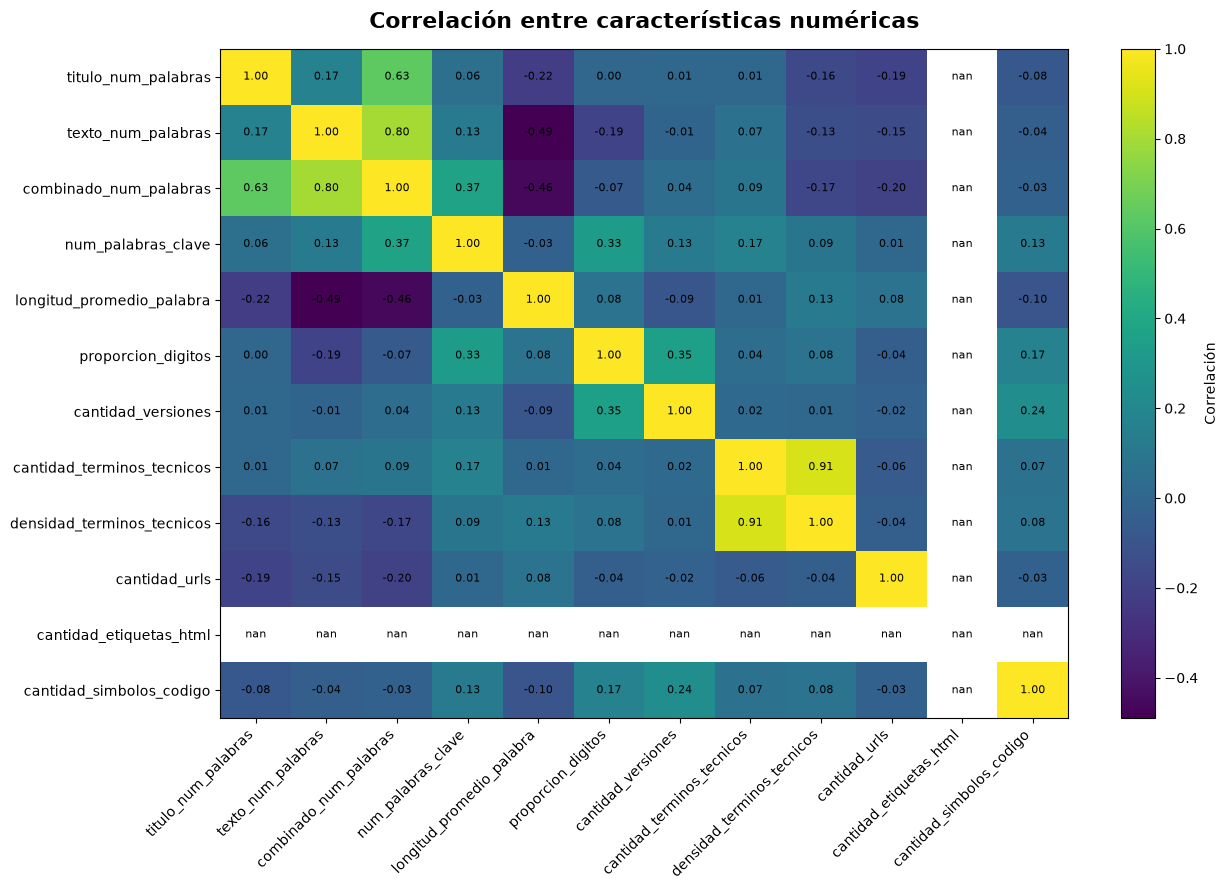

In [203]:
# ==============================================================================
# CELDA 83
# VISUALIZACIÓN DE CORRELACIONES
# ==============================================================================

fig, ax = plt.subplots(
    figsize=(13, 9)
)

imagen = ax.imshow(
    matriz_correlacion,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(columnas_correlacion))
)

ax.set_yticks(
    np.arange(len(columnas_correlacion))
)

ax.set_xticklabels(
    columnas_correlacion,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    columnas_correlacion
)

for i in range(len(columnas_correlacion)):
    for j in range(len(columnas_correlacion)):

        ax.text(
            j,
            i,
            f"{matriz_correlacion.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title(
    "Correlación entre características numéricas",
    fontsize=16,
    fontweight="bold",
    pad=15
)

fig.colorbar(
    imagen,
    ax=ax,
    label="Correlación"
)

plt.tight_layout()
plt.show()

In [204]:
# ==============================================================================
# CELDA 84
# DETECCIÓN DE VARIABLES CONSTANTES
# ==============================================================================

resumen_variabilidad = pd.DataFrame({
    "Variable": COLUMNAS_FEATURES_NUMERICAS,
    "Valores_unicos": [
        df_features[columna].nunique()
        for columna in COLUMNAS_FEATURES_NUMERICAS
    ],
    "Valor_mas_frecuente_pct": [
        (
            df_features[columna]
            .value_counts(
                normalize=True,
                dropna=False
            )
            .iloc[0]
            * 100
        )
        for columna in COLUMNAS_FEATURES_NUMERICAS
    ]
})

resumen_variabilidad["Valor_mas_frecuente_pct"] = (
    resumen_variabilidad[
        "Valor_mas_frecuente_pct"
    ]
    .round(2)
)

resumen_variabilidad["Casi_constante"] = (
    resumen_variabilidad[
        "Valor_mas_frecuente_pct"
    ] >= 99
)

display(
    resumen_variabilidad.sort_values(
        [
            "Casi_constante",
            "Valor_mas_frecuente_pct"
        ],
        ascending=False
    )
)

,Variable,Valores_unicos,Valor_mas_frecuente_pct,Casi_constante
13,cantidad_etiquetas_html,1,100.00,True
18,tiene_html,1,100.00,True
12,cantidad_urls,2,99.00,True
17,tiene_url,2,99.00,True
9,cantidad_versiones,7,95.48,False
16,tiene_version,2,95.48,False
14,cantidad_simbolos_codigo,8,89.61,False
19,tiene_codigo,2,89.61,False
20,tiene_terminos_tecnicos,2,63.12,False
15,tiene_palabras_clave,2,62.14,False


In [205]:
# ==============================================================================
# CELDA 85
# VALIDACIÓN FINAL DE LA INGENIERÍA DE CARACTERÍSTICAS
# ==============================================================================

columnas_features_faltantes = [
    columna
    for columna in COLUMNAS_FEATURES_NUMERICAS
    if columna not in df_features.columns
]

features_numericas_validas = all(
    pd.api.types.is_numeric_dtype(
        df_features[columna]
    )
    for columna in COLUMNAS_FEATURES_NUMERICAS
)

documentos_vacios = int(
    df_features["texto_combinado"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("=" * 80)
print("VALIDACIÓN DE LA INGENIERÍA DE CARACTERÍSTICAS")
print("=" * 80)

print(
    f"Características esperadas: "
    f"{len(COLUMNAS_FEATURES_NUMERICAS)}"
)

print(
    f"Características faltantes: "
    f"{len(columnas_features_faltantes)}"
)

print(
    f"Todas las características son numéricas: "
    f"{features_numericas_validas}"
)

print(
    f"Valores nulos: "
    f"{total_nulos:,}"
)

print(
    f"Valores infinitos: "
    f"{total_infinitos:,}"
)

print(
    f"Documentos vacíos: "
    f"{documentos_vacios:,}"
)

if (
    not columnas_features_faltantes
    and features_numericas_validas
    and total_nulos == 0
    and total_infinitos == 0
    and documentos_vacios == 0
):
    print("""
La ingeniería de características se completó correctamente. El dataset contiene
variables textuales y numéricas válidas para realizar experimentos con modelos
basados en TF-IDF y modelos híbridos.
""")
else:
    print("""
ADVERTENCIA: se detectaron inconsistencias en las características generadas.
Se recomienda revisar el resumen de calidad antes de continuar.
""")

VALIDACIÓN DE LA INGENIERÍA DE CARACTERÍSTICAS
Características esperadas: 21
Características faltantes: 0
Todas las características son numéricas: True
Valores nulos: 0
Valores infinitos: 0
Documentos vacíos: 0

La ingeniería de características se completó correctamente. El dataset contiene
variables textuales y numéricas válidas para realizar experimentos con modelos
basados en TF-IDF y modelos híbridos.



In [206]:
# ==============================================================================
# REINICIO DEL REPORTE DE VALIDACIÓN
# ==============================================================================

resultados_validacion = []

# Eliminar reportes anteriores de la memoria
if "df_resultados_validacion" in globals():
    del df_resultados_validacion

if "errores_criticos" in globals():
    del errores_criticos

if "advertencias" in globals():
    del advertencias

print("Reporte de validación reiniciado correctamente.")

Reporte de validación reiniciado correctamente.


In [207]:
# ==============================================================================
# CELDA 86
# VALIDACIÓN INTEGRAL DEL DATASET PROCESADO
# ==============================================================================

print("=" * 90)
print("VALIDACIÓN INTEGRAL DEL DATASET PROCESADO")
print("=" * 90)

DATASET_VALIDACION = df_features

COLUMNA_OBJETIVO = "categoria"
COLUMNA_TEXTO_PRINCIPAL = "texto_combinado"

CATEGORIAS_ESPERADAS = {
    "backend",
    "cloud",
    "datascience",
    "frontend"
}

COLUMNAS_TEXTO_REQUERIDAS = [
    "titulo_limpio",
    "texto_limpio",
    "palabras_clave_texto",
    "texto_modelo_base",
    "texto_modelo_titulo",
    "texto_combinado",
    "texto_combinado_ponderado"
]

COLUMNAS_REQUERIDAS = (
    [COLUMNA_OBJETIVO]
    + COLUMNAS_TEXTO_REQUERIDAS
    + COLUMNAS_FEATURES_NUMERICAS
)

resultados_validacion = []

VALIDACIÓN INTEGRAL DEL DATASET PROCESADO


In [208]:
# ==============================================================================
# CELDA 87
# FUNCIÓN DE REGISTRO
# ==============================================================================

def registrar_validacion(
    prueba,
    resultado,
    detalle,
    severidad="ERROR"
):
    """
    Registra el resultado de una comprobación de calidad.

    Parameters
    ----------
    prueba : str
        Nombre de la validación.

    resultado : bool
        True cuando la prueba fue superada.

    detalle : str
        Descripción del resultado obtenido.

    severidad : str
        Nivel asociado al incumplimiento:
        ERROR, ADVERTENCIA o INFORMATIVO.
    """

    resultados_validacion.append({
        "Prueba": prueba,
        "Resultado": "APROBADA" if resultado else "REVISAR",
        "Detalle": detalle,
        "Severidad": "-" if resultado else severidad
    })

In [209]:
# ==============================================================================
# CELDA 88
# VALIDACIÓN DE ESTRUCTURA
# ==============================================================================

filas_dataset, columnas_dataset = DATASET_VALIDACION.shape

columnas_faltantes = [
    columna
    for columna in COLUMNAS_REQUERIDAS
    if columna not in DATASET_VALIDACION.columns
]

registrar_validacion(
    prueba="Dataset no vacío",
    resultado=filas_dataset > 0,
    detalle=f"{filas_dataset:,} registros disponibles."
)

registrar_validacion(
    prueba="Columnas requeridas",
    resultado=len(columnas_faltantes) == 0,
    detalle=(
        "Todas las columnas requeridas están presentes."
        if not columnas_faltantes
        else f"Columnas faltantes: {columnas_faltantes}"
    )
)

print(f"Dimensiones: {filas_dataset:,} filas × {columnas_dataset:,} columnas")
print(f"Columnas faltantes: {len(columnas_faltantes)}")

Dimensiones: 4,583 filas × 69 columnas
Columnas faltantes: 0


In [210]:
# ==============================================================================
# CELDA 89
# VALIDACIÓN DE LA VARIABLE OBJETIVO
# ==============================================================================

categorias_encontradas = set(
    DATASET_VALIDACION[COLUMNA_OBJETIVO]
    .dropna()
    .unique()
)

categorias_desconocidas = (
    categorias_encontradas
    - CATEGORIAS_ESPERADAS
)

categorias_ausentes = (
    CATEGORIAS_ESPERADAS
    - categorias_encontradas
)

objetivo_nulos = int(
    DATASET_VALIDACION[COLUMNA_OBJETIVO]
    .isna()
    .sum()
)

objetivo_vacios = int(
    DATASET_VALIDACION[COLUMNA_OBJETIVO]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

registrar_validacion(
    prueba="Categorías esperadas",
    resultado=(
        len(categorias_desconocidas) == 0
        and len(categorias_ausentes) == 0
    ),
    detalle=(
        f"Categorías encontradas: {sorted(categorias_encontradas)}. "
        f"Desconocidas: {sorted(categorias_desconocidas)}. "
        f"Ausentes: {sorted(categorias_ausentes)}."
    )
)

registrar_validacion(
    prueba="Objetivo sin valores nulos",
    resultado=objetivo_nulos == 0,
    detalle=f"Valores nulos en categoría: {objetivo_nulos:,}."
)

registrar_validacion(
    prueba="Objetivo sin valores vacíos",
    resultado=objetivo_vacios == 0,
    detalle=f"Valores vacíos en categoría: {objetivo_vacios:,}."
)

In [211]:
# ==============================================================================
# CELDA 90
# BALANCE DE CLASES
# ==============================================================================

distribucion_clases = (
    DATASET_VALIDACION[COLUMNA_OBJETIVO]
    .value_counts()
    .sort_index()
    .rename_axis("Categoria")
    .reset_index(name="Cantidad")
)

distribucion_clases["Porcentaje"] = (
    distribucion_clases["Cantidad"]
    .div(len(DATASET_VALIDACION))
    .mul(100)
    .round(2)
)

clase_mayoritaria = int(
    distribucion_clases["Cantidad"].max()
)

clase_minoritaria = int(
    distribucion_clases["Cantidad"].min()
)

diferencia_clases = (
    clase_mayoritaria
    - clase_minoritaria
)

ratio_balance = (
    clase_minoritaria / clase_mayoritaria
    if clase_mayoritaria > 0
    else 0
)

registrar_validacion(
    prueba="Balance de clases",
    resultado=ratio_balance >= 0.80,
    detalle=(
        f"Ratio minoritaria/mayoritaria: {ratio_balance:.3f}. "
        f"Diferencia máxima: {diferencia_clases:,} registros."
    ),
    severidad="ADVERTENCIA"
)

display(distribucion_clases)

,Categoria,Cantidad,Porcentaje
0,backend,1159,25.29
1,cloud,1157,25.25
2,datascience,1102,24.05
3,frontend,1165,25.42


In [212]:
# ==============================================================================
# CELDA 91
# VALIDACIÓN DE COLUMNAS TEXTUALES
# ==============================================================================

resumen_textos = []

for columna in COLUMNAS_TEXTO_REQUERIDAS:

    if columna not in DATASET_VALIDACION.columns:
        continue

    cantidad_nulos = int(
        DATASET_VALIDACION[columna]
        .isna()
        .sum()
    )

    cantidad_vacios = int(
        DATASET_VALIDACION[columna]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    tipos_no_texto = int(
        (~DATASET_VALIDACION[columna].apply(
            lambda valor: isinstance(valor, str)
        )).sum()
    )

    resumen_textos.append({
        "Variable": columna,
        "Nulos": cantidad_nulos,
        "Vacios": cantidad_vacios,
        "Valores_no_texto": tipos_no_texto,
        "Longitud_promedio": round(
            DATASET_VALIDACION[columna]
            .fillna("")
            .astype(str)
            .str.len()
            .mean(),
            2
        )
    })

df_resumen_textos = pd.DataFrame(
    resumen_textos
)

display(df_resumen_textos)

problemas_textuales = int(
    df_resumen_textos[
        [
            "Nulos",
            "Vacios",
            "Valores_no_texto"
        ]
    ].sum().sum()
)

#registrar_validacion(
#    prueba="Variables textuales válidas",
#    resultado=problemas_textuales == 0,
#    detalle=(
#        f"Problemas textuales detectados: "
#        f"{problemas_textuales:,}."
#    )
#)

,Variable,Nulos,Vacios,Valores_no_texto,Longitud_promedio
0,titulo_limpio,0,1,0,63.94
1,texto_limpio,0,0,0,98.54
2,palabras_clave_texto,0,1735,0,10.86
3,texto_modelo_base,0,0,0,98.54
4,texto_modelo_titulo,0,0,0,163.48
5,texto_combinado,0,0,0,174.96
6,texto_combinado_ponderado,0,0,0,251.37


In [213]:
# ==============================================================================
# CELDA 92
# VALIDACIÓN DE CARACTERÍSTICAS NUMÉRICAS
# ==============================================================================

resumen_features_calidad = []

for columna in COLUMNAS_FEATURES_NUMERICAS:

    if columna not in DATASET_VALIDACION.columns:
        continue

    serie_numerica = pd.to_numeric(
        DATASET_VALIDACION[columna],
        errors="coerce"
    )

    cantidad_nulos = int(
        serie_numerica.isna().sum()
    )

    cantidad_infinitos = int(
        np.isinf(serie_numerica).sum()
    )

    es_numerica = pd.api.types.is_numeric_dtype(
        DATASET_VALIDACION[columna]
    )

    resumen_features_calidad.append({
        "Variable": columna,
        "Es_numerica": es_numerica,
        "Nulos": cantidad_nulos,
        "Infinitos": cantidad_infinitos,
        "Minimo": serie_numerica.min(),
        "Maximo": serie_numerica.max(),
        "Valores_unicos": serie_numerica.nunique()
    })

df_calidad_numerica = pd.DataFrame(
    resumen_features_calidad
)

display(df_calidad_numerica)

total_nulos_numericos = int(
    df_calidad_numerica["Nulos"].sum()
)

total_infinitos = int(
    df_calidad_numerica["Infinitos"].sum()
)

todas_numericas = bool(
    df_calidad_numerica["Es_numerica"].all()
)

registrar_validacion(
    prueba="Características numéricas",
    resultado=(
        todas_numericas
        and total_nulos_numericos == 0
        and total_infinitos == 0
    ),
    detalle=(
        f"Todas numéricas: {todas_numericas}. "
        f"Nulos: {total_nulos_numericos:,}. "
        f"Infinitos: {total_infinitos:,}."
    )
)

,Variable,Es_numerica,Nulos,Infinitos,Minimo,Maximo,Valores_unicos
0,titulo_num_caracteres,True,0,0,0.00,254.00,138
1,titulo_num_palabras,True,0,0,0.00,39.00,29
2,texto_num_caracteres,True,0,0,31.00,377.00,203
3,texto_num_palabras,True,0,0,0.00,56.00,52
4,combinado_num_caracteres,True,0,0,42.00,459.00,264
5,combinado_num_palabras,True,0,0,1.00,74.00,67
6,num_palabras_clave,True,0,0,0.00,7.00,8
7,longitud_promedio_palabra,True,0,0,1.83,9.67,450
8,proporcion_digitos,True,0,0,0.00,0.25,568
9,cantidad_versiones,True,0,0,0.00,6.00,7


In [214]:
# ==============================================================================
# CELDA 93
# VALIDACIÓN DE VALORES NEGATIVOS
# ==============================================================================

COLUMNAS_NO_NEGATIVAS = [
    "titulo_num_caracteres",
    "titulo_num_palabras",
    "texto_num_caracteres",
    "texto_num_palabras",
    "combinado_num_caracteres",
    "combinado_num_palabras",
    "num_palabras_clave",
    "longitud_promedio_palabra",
    "proporcion_digitos",
    "cantidad_versiones",
    "cantidad_terminos_tecnicos",
    "densidad_terminos_tecnicos",
    "cantidad_urls",
    "cantidad_etiquetas_html",
    "cantidad_simbolos_codigo"
]

valores_negativos_por_columna = {}

for columna in COLUMNAS_NO_NEGATIVAS:

    if columna in DATASET_VALIDACION.columns:

        cantidad_negativos = int(
            DATASET_VALIDACION[columna]
            .lt(0)
            .sum()
        )

        if cantidad_negativos > 0:
            valores_negativos_por_columna[columna] = cantidad_negativos

registrar_validacion(
    prueba="Ausencia de valores negativos",
    resultado=len(valores_negativos_por_columna) == 0,
    detalle=(
        "No se detectaron valores negativos."
        if not valores_negativos_por_columna
        else str(valores_negativos_por_columna)
    )
)

In [215]:
# ==============================================================================
# CELDA 94
# VALIDACIÓN DE RANGOS
# ==============================================================================

COLUMNAS_PROPORCION = [
    "proporcion_digitos",
    "densidad_terminos_tecnicos"
]

problemas_proporciones = {}

for columna in COLUMNAS_PROPORCION:

    # True cuando el valor está fuera del intervalo [0, 1]
    mascara_fuera_de_rango = (
        ~DATASET_VALIDACION[columna].between(
            0,
            1,
            inclusive="both"
        )
    )

    fuera_de_rango = int(
        mascara_fuera_de_rango.sum()
    )

    if fuera_de_rango > 0:
        problemas_proporciones[columna] = fuera_de_rango


COLUMNAS_BINARIAS = [
    "tiene_palabras_clave",
    "tiene_version",
    "tiene_url",
    "tiene_html",
    "tiene_codigo",
    "tiene_terminos_tecnicos"
]

problemas_binarios = {}

for columna in COLUMNAS_BINARIAS:

    # True cuando el valor no es 0 ni 1
    mascara_valores_invalidos = (
        ~DATASET_VALIDACION[columna].isin([0, 1])
    )

    valores_invalidos = int(
        mascara_valores_invalidos.sum()
    )

    if valores_invalidos > 0:
        problemas_binarios[columna] = valores_invalidos


registrar_validacion(
    prueba="Proporciones entre cero y uno",
    resultado=len(problemas_proporciones) == 0,
    detalle=(
        "Todas las proporciones están dentro del rango [0, 1]."
        if not problemas_proporciones
        else f"Valores fuera de rango: {problemas_proporciones}"
    )
)

registrar_validacion(
    prueba="Indicadores binarios válidos",
    resultado=len(problemas_binarios) == 0,
    detalle=(
        "Todos los indicadores contienen únicamente 0 y 1."
        if not problemas_binarios
        else f"Valores binarios inválidos: {problemas_binarios}"
    )
)

print("=" * 80)
print("VALIDACIÓN DE PROPORCIONES E INDICADORES")
print("=" * 80)

print(
    f"Variables de proporción con problemas: "
    f"{len(problemas_proporciones)}"
)

print(
    f"Indicadores binarios con problemas: "
    f"{len(problemas_binarios)}"
)

if not problemas_proporciones and not problemas_binarios:
    print(
        "\nLas proporciones y los indicadores binarios son válidos."
    )
else:
    print(
        "\nSe detectaron valores que requieren revisión."
    )

VALIDACIÓN DE PROPORCIONES E INDICADORES
Variables de proporción con problemas: 0
Indicadores binarios con problemas: 0

Las proporciones y los indicadores binarios son válidos.


In [216]:
# ==============================================================================
# CELDA 95
# VALIDACIÓN DE DUPLICADOS Y CONFLICTOS
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. Duplicados del texto principal con la misma categoría
# ------------------------------------------------------------------------------

duplicados_exactos_restantes = int(
    DATASET_VALIDACION.duplicated(
        subset=[
            COLUMNA_TEXTO_PRINCIPAL,
            COLUMNA_OBJETIVO
        ],
        keep=False
    ).sum()
)

# ------------------------------------------------------------------------------
# 2. Textos idénticos asociados con categorías diferentes
# ------------------------------------------------------------------------------

conflictos_categoria_restantes = int(
    DATASET_VALIDACION
    .groupby(
        COLUMNA_TEXTO_PRINCIPAL
    )[COLUMNA_OBJETIVO]
    .nunique()
    .gt(1)
    .sum()
)

# ------------------------------------------------------------------------------
# 3. Conversión temporal de objetos no hashables
# ------------------------------------------------------------------------------

def convertir_a_hashable(valor):
    """
    Convierte estructuras mutables en objetos hashables para permitir
    la detección de filas completamente duplicadas.

    No modifica el DataFrame original.
    """

    if isinstance(valor, list):
        return tuple(
            convertir_a_hashable(elemento)
            for elemento in valor
        )

    if isinstance(valor, tuple):
        return tuple(
            convertir_a_hashable(elemento)
            for elemento in valor
        )

    if isinstance(valor, set):
        return tuple(
            sorted(
                convertir_a_hashable(elemento)
                for elemento in valor
            )
        )

    if isinstance(valor, dict):
        return tuple(
            sorted(
                (
                    clave,
                    convertir_a_hashable(contenido)
                )
                for clave, contenido in valor.items()
            )
        )

    if isinstance(valor, np.ndarray):
        return tuple(
            convertir_a_hashable(elemento)
            for elemento in valor.tolist()
        )

    return valor


# Crear una copia únicamente para la validación
df_validacion_hashable = DATASET_VALIDACION.copy()

# Convertir solo columnas de tipo object o string que puedan contener estructuras
for columna in df_validacion_hashable.columns:

    if df_validacion_hashable[columna].dtype == "object":

        df_validacion_hashable[columna] = (
            df_validacion_hashable[columna]
            .apply(convertir_a_hashable)
        )

# ------------------------------------------------------------------------------
# 4. Filas completamente duplicadas
# ------------------------------------------------------------------------------

duplicados_filas_completas = int(
    df_validacion_hashable
    .duplicated(
        keep=False
    )
    .sum()
)

# ------------------------------------------------------------------------------
# 5. Registro de resultados
# ------------------------------------------------------------------------------

registrar_validacion(
    prueba="Sin duplicados textuales",
    resultado=duplicados_exactos_restantes == 0,
    detalle=(
        f"Registros en grupos textuales duplicados: "
        f"{duplicados_exactos_restantes:,}."
    )
)

registrar_validacion(
    prueba="Sin etiquetas contradictorias",
    resultado=conflictos_categoria_restantes == 0,
    detalle=(
        f"Textos asociados con varias categorías: "
        f"{conflictos_categoria_restantes:,}."
    )
)

registrar_validacion(
    prueba="Sin filas completamente duplicadas",
    resultado=duplicados_filas_completas == 0,
    detalle=(
        f"Filas completamente duplicadas: "
        f"{duplicados_filas_completas:,}."
    ),
    severidad="ADVERTENCIA"
)

# ------------------------------------------------------------------------------
# 6. Presentación de resultados
# ------------------------------------------------------------------------------

print("=" * 80)
print("VALIDACIÓN DE DUPLICADOS Y CONFLICTOS")
print("=" * 80)

print(
    f"Registros en grupos textuales duplicados: "
    f"{duplicados_exactos_restantes:,}"
)

print(
    f"Textos con categorías contradictorias: "
    f"{conflictos_categoria_restantes:,}"
)

print(
    f"Filas completamente duplicadas: "
    f"{duplicados_filas_completas:,}"
)

if (
    duplicados_exactos_restantes == 0
    and conflictos_categoria_restantes == 0
    and duplicados_filas_completas == 0
):
    print(
        "\nNo se detectaron duplicados ni conflictos residuales."
    )
else:
    print(
        "\nSe detectaron registros que requieren revisión."
    )

VALIDACIÓN DE DUPLICADOS Y CONFLICTOS
Registros en grupos textuales duplicados: 0
Textos con categorías contradictorias: 0
Filas completamente duplicadas: 0

No se detectaron duplicados ni conflictos residuales.


In [217]:
# ==============================================================================
# CELDA 96
# VALIDACIÓN DE PALABRAS CLAVE
# ==============================================================================

listas_keywords_validas = DATASET_VALIDACION[
    "palabras_clave_limpias"
].apply(
    lambda valor: isinstance(valor, list)
)

elementos_keywords_validos = DATASET_VALIDACION[
    "palabras_clave_limpias"
].apply(
    lambda lista: (
        isinstance(lista, list)
        and all(
            isinstance(keyword, str)
            and keyword.strip()
            for keyword in lista
        )
    )
)

duplicados_dentro_keywords = DATASET_VALIDACION[
    "palabras_clave_limpias"
].apply(
    lambda lista: (
        isinstance(lista, list)
        and len(lista) != len(set(lista))
    )
)

conteo_keywords_consistente = (
    DATASET_VALIDACION[
        "palabras_clave_limpias"
    ].apply(len)
    ==
    DATASET_VALIDACION[
        "num_palabras_clave"
    ]
)

registrar_validacion(
    prueba="Listas de palabras clave válidas",
    resultado=bool(
        listas_keywords_validas.all()
        and elementos_keywords_validos.all()
    ),
    detalle=(
        f"Listas inválidas: "
        f"{int((~listas_keywords_validas).sum()):,}. "
        f"Registros con elementos inválidos: "
        f"{int((~elementos_keywords_validos).sum()):,}."
    )
)

registrar_validacion(
    prueba="Sin keywords duplicadas internas",
    resultado=not bool(
        duplicados_dentro_keywords.any()
    ),
    detalle=(
        f"Registros con duplicados internos: "
        f"{int(duplicados_dentro_keywords.sum()):,}."
    )
)

registrar_validacion(
    prueba="Conteo de keywords consistente",
    resultado=bool(
        conteo_keywords_consistente.all()
    ),
    detalle=(
        f"Registros con conteos inconsistentes: "
        f"{int((~conteo_keywords_consistente).sum()):,}."
    )
)

In [218]:
# ==============================================================================
# CELDA 97
# DETECCIÓN DE VARIABLES SIN VARIABILIDAD
# ==============================================================================

variables_constantes = []

variables_casi_constantes = []

for columna in COLUMNAS_FEATURES_NUMERICAS:

    cantidad_unicos = (
        DATASET_VALIDACION[columna]
        .nunique(dropna=False)
    )

    porcentaje_dominante = (
        DATASET_VALIDACION[columna]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .iloc[0]
        * 100
    )

    if cantidad_unicos <= 1:
        variables_constantes.append(
            columna
        )

    elif porcentaje_dominante >= 99:
        variables_casi_constantes.append({
            "Variable": columna,
            "Valor_dominante_pct": round(
                porcentaje_dominante,
                2
            )
        })

registrar_validacion(
    prueba="Ausencia de variables constantes",
    resultado=len(variables_constantes) == 0,
    detalle=(
        "No se detectaron variables constantes."
        if not variables_constantes
        else f"Variables constantes: {variables_constantes}"
    ),
    severidad="ADVERTENCIA"
)

registrar_validacion(
    prueba="Revisión de variables casi constantes",
    resultado=len(variables_casi_constantes) == 0,
    detalle=(
        "No se detectaron variables casi constantes."
        if not variables_casi_constantes
        else f"Variables casi constantes: {variables_casi_constantes}"
    ),
    severidad="INFORMATIVO"
)

In [219]:
# ==============================================================================
# CELDA 98
# DETECCIÓN DE VALORES ATÍPICOS
# ==============================================================================

COLUMNAS_OUTLIERS = [
    "titulo_num_palabras",
    "texto_num_palabras",
    "combinado_num_palabras",
    "num_palabras_clave",
    "cantidad_versiones",
    "cantidad_terminos_tecnicos",
    "cantidad_urls",
    "cantidad_etiquetas_html",
    "cantidad_simbolos_codigo"
]

resumen_outliers = []

for columna in COLUMNAS_OUTLIERS:

    serie = DATASET_VALIDACION[columna]

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_outliers = (
        (serie < limite_inferior)
        | (serie > limite_superior)
    )

    cantidad_outliers = int(
        mascara_outliers.sum()
    )

    resumen_outliers.append({
        "Variable": columna,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Limite_inferior": round(limite_inferior, 2),
        "Limite_superior": round(limite_superior, 2),
        "Cantidad_outliers": cantidad_outliers,
        "Porcentaje_outliers": round(
            cantidad_outliers
            / len(DATASET_VALIDACION)
            * 100,
            2
        )
    })

df_resumen_outliers = pd.DataFrame(
    resumen_outliers
)

display(df_resumen_outliers)

registrar_validacion(
    prueba="Análisis de valores atípicos",
    resultado=True,
    detalle=(
        "Los valores atípicos fueron identificados para auditoría; "
        "no se eliminaron automáticamente."
    ),
    severidad="INFORMATIVO"
)

,Variable,Q1,Q3,IQR,Limite_inferior,Limite_superior,Cantidad_outliers,Porcentaje_outliers
0,titulo_num_palabras,8.00,12.00,4.00,2.00,18.00,130,2.84
1,texto_num_palabras,13.00,18.00,5.00,5.50,25.50,221,4.82
2,combinado_num_palabras,24.00,31.00,7.00,13.50,41.50,223,4.87
3,num_palabras_clave,0.00,2.00,2.00,-3.00,5.00,15,0.33
4,cantidad_versiones,0.00,0.00,0.00,0.00,0.00,207,4.52
5,cantidad_terminos_tecnicos,0.00,2.00,2.00,-3.00,5.00,17,0.37
6,cantidad_urls,0.00,0.00,0.00,0.00,0.00,46,1.00
7,cantidad_etiquetas_html,0.00,0.00,0.00,0.00,0.00,0,0.00
8,cantidad_simbolos_codigo,0.00,0.00,0.00,0.00,0.00,476,10.39


In [220]:
# ==============================================================================
# CELDA 99
# DOCUMENTOS CON MAYOR LONGITUD
# ==============================================================================

documentos_extremos = (
    DATASET_VALIDACION[
        [
            "categoria",
            "titulo_original",
            "texto_combinado",
            "combinado_num_palabras",
            "num_palabras_clave",
            "cantidad_terminos_tecnicos"
        ]
    ]
    .sort_values(
        "combinado_num_palabras",
        ascending=False
    )
    .head(20)
)

print("Documentos con mayor número de tokens:")

display(documentos_extremos)

Documentos con mayor número de tokens:


,categoria,titulo_original,texto_combinado,combinado_num_palabras,num_palabras_clave,cantidad_terminos_tecnicos
2667,cloud,Unlocking Claude Fable 5 and Mythos 5: A New Era in AI Development,unlocking claude fable 5 and mythos 5: a new era in ai development the department of commerce has lifted export controls on claude fable 5 and myt...,74,4,3
126,cloud,Auto-Fix is not the Problem. The Signal is the Problem.,auto-fix is not the problem. the signal is the problem. harry wetherald correctly identifies why auto-fixing all vulnerabilities doesn t work: 80-...,70,3,1
4131,datascience,"Expected goals (xG) from scratch, and why the scoreboard lies",expected goals xg from scratch and why the scoreboard lies argentina lost their 2022 world cup opener to saudi arabia and everyone said saudi were...,70,5,2
1700,cloud,Every Cloud Security Tool Works. None of Them Are Sufficient. Here's the Precise Diagnosis.,every cloud security tool works. none of them are sufficient. here s the precise diagnosis. there s a discipline that forces you to state what eac...,70,0,2
4396,frontend,Modern CSS in 2026: The JavaScript You Can Finally Delete,modern css in 2026: the javascript you can finally delete tooltips accordions theme toggles dropdown positioning scroll animations responsive comp...,68,4,5
4126,backend,"The ""Native-First"" Revolution: How Node.js 24 Is Ending Dependency Hell in 2026",the native-first revolution: how node.js 24 is ending dependency hell in 2026 node.js 24 lts quietly replaces many of javascript s most-used tools...,67,4,5
3924,backend,"Building toykv: a from-scratch persistent KV in Go, and why I took the opposite call from toymq three times",building toykv: a from-scratch persistent kv in go and why i took the opposite call from toymq three times i shipped two server-shaped go projects...,66,2,0
1579,backend,Chiến lược kiểm thử API: Hướng dẫn thực tế để có API đáng tin cậy,chiến lược kiểm thử api: hướng dẫn thực tế để có api đáng tin cậy hầu hết lỗi api không đến từ những tình huống quá đặc biệt. chúng thường là trườ...,65,4,1
3218,frontend,HTTP QUERY is here: what changes for frontend data fetching?,http query is here: what changes for frontend data fetching rfc 10008 standardized the http query method in june 2026: safe and idempotent like ge...,65,3,2
83,frontend,How Our AI Agents Built the Universal CSS Utility Class Generator and Why You'll Love It,how our ai agents built the universal css utility class generator and why you ll love it introducing the universal css utility class generator a m...,65,3,4


In [221]:
# ==============================================================================
# CELDA 100
# ==============================================================================
# TABLA FINAL DE VALIDACIONES SIN RESULTADOS DUPLICADOS
# ==============================================================================

df_resultados_validacion = pd.DataFrame(
    resultados_validacion
)

# Si una prueba se ejecutó más de una vez, conservar el resultado más reciente
df_resultados_validacion = (
    df_resultados_validacion
    .drop_duplicates(
        subset=["Prueba"],
        keep="last"
    )
    .reset_index(drop=True)
)

orden_resultado = {
    "REVISAR": 0,
    "APROBADA": 1
}

df_resultados_validacion["Orden"] = (
    df_resultados_validacion["Resultado"]
    .map(orden_resultado)
)

df_resultados_validacion = (
    df_resultados_validacion
    .sort_values(
        ["Orden", "Prueba"]
    )
    .drop(columns="Orden")
    .reset_index(drop=True)
)

display(df_resultados_validacion)

,Prueba,Resultado,Detalle,Severidad
0,Ausencia de variables constantes,REVISAR,"Variables constantes: ['cantidad_etiquetas_html', 'tiene_html']",ADVERTENCIA
1,Análisis de valores atípicos,APROBADA,Los valores atípicos fueron identificados para auditoría; no se eliminaron automáticamente.,-
2,Ausencia de valores negativos,APROBADA,No se detectaron valores negativos.,-
3,Balance de clases,APROBADA,Ratio minoritaria/mayoritaria: 0.946. Diferencia máxima: 63 registros.,-
4,Características numéricas,APROBADA,Todas numéricas: True. Nulos: 0. Infinitos: 0.,-
5,Categorías esperadas,APROBADA,"Categorías encontradas: ['backend', 'cloud', 'datascience', 'frontend']. Desconocidas: []. Ausentes: [].",-
6,Columnas requeridas,APROBADA,Todas las columnas requeridas están presentes.,-
7,Conteo de keywords consistente,APROBADA,Registros con conteos inconsistentes: 0.,-
8,Dataset no vacío,APROBADA,"4,583 registros disponibles.",-
9,Indicadores binarios válidos,APROBADA,Todos los indicadores contienen únicamente 0 y 1.,-


In [222]:
# ==============================================================================
# CELDA 101
# CONTEO DE PRUEBAS APROBADAS
# ==============================================================================

cantidad_pruebas = len(
    df_resultados_validacion
)

pruebas_aprobadas = int(
    df_resultados_validacion[
        "Resultado"
    ].eq("APROBADA").sum()
)

pruebas_revision = int(
    df_resultados_validacion[
        "Resultado"
    ].eq("REVISAR").sum()
)

errores_criticos = int(
    (
        df_resultados_validacion[
            "Resultado"
        ].eq("REVISAR")
        &
        df_resultados_validacion[
            "Severidad"
        ].eq("ERROR")
    ).sum()
)

advertencias = int(
    (
        df_resultados_validacion[
            "Resultado"
        ].eq("REVISAR")
        &
        df_resultados_validacion[
            "Severidad"
        ].eq("ADVERTENCIA")
    ).sum()
)

print("=" * 90)
print("RESUMEN DE VALIDACIÓN")
print("=" * 90)

print(
    f"Pruebas realizadas: "
    f"{cantidad_pruebas:,}"
)

print(
    f"Pruebas aprobadas: "
    f"{pruebas_aprobadas:,}"
)

print(
    f"Pruebas para revisión: "
    f"{pruebas_revision:,}"
)

print(
    f"Errores críticos: "
    f"{errores_criticos:,}"
)

print(
    f"Advertencias: "
    f"{advertencias:,}"
)

RESUMEN DE VALIDACIÓN
Pruebas realizadas: 19
Pruebas aprobadas: 18
Pruebas para revisión: 1
Errores críticos: 0
Advertencias: 1


In [223]:
# ==============================================================================
# CELDA 102
# CONCLUSIÓN DEL PROCESO DE VALIDACIÓN
# ==============================================================================

print("=" * 90)
print("CONCLUSIÓN DE LA VALIDACIÓN INTEGRAL")
print("=" * 90)

print(
    f"Registros finales: "
    f"{len(DATASET_VALIDACION):,}"
)

print(
    f"Características numéricas: "
    f"{len(COLUMNAS_FEATURES_NUMERICAS):,}"
)

print(
    f"Clases disponibles: "
    f"{DATASET_VALIDACION[COLUMNA_OBJETIVO].nunique():,}"
)

print(
    f"Ratio de balance: "
    f"{ratio_balance:.3f}"
)

print(
    f"Errores críticos: "
    f"{errores_criticos:,}"
)

if errores_criticos == 0:

    print("""
El dataset procesado superó las validaciones críticas de estructura, contenido,
etiquetas y características numéricas.

No se detectaron documentos vacíos, valores nulos, valores infinitos,
duplicados textuales ni categorías contradictorias. Las clases mantienen una
distribución suficientemente equilibrada para continuar con el modelado.

Los valores atípicos y las variables casi constantes se conservaron para
auditoría y serán evaluados experimentalmente durante la comparación de modelos.
El dataset puede avanzar a la etapa de exportación.
""")

else:

    print("""
El dataset contiene errores críticos que deben resolverse antes de la
exportación y del entrenamiento. Consulta la tabla de resultados para localizar
las validaciones marcadas como ERROR.
""")

CONCLUSIÓN DE LA VALIDACIÓN INTEGRAL
Registros finales: 4,583
Características numéricas: 21
Clases disponibles: 4
Ratio de balance: 0.946
Errores críticos: 0

El dataset procesado superó las validaciones críticas de estructura, contenido,
etiquetas y características numéricas.

No se detectaron documentos vacíos, valores nulos, valores infinitos,
duplicados textuales ni categorías contradictorias. Las clases mantienen una
distribución suficientemente equilibrada para continuar con el modelado.

Los valores atípicos y las variables casi constantes se conservaron para
auditoría y serán evaluados experimentalmente durante la comparación de modelos.
El dataset puede avanzar a la etapa de exportación.



In [224]:
# ==============================================================================
# CELDA 103
# MOSTRAR ÚNICAMENTE ERRORES CRÍTICOS
# ==============================================================================

errores_criticos_detectados = df_resultados_validacion[
    (df_resultados_validacion["Resultado"] == "REVISAR")
    & (df_resultados_validacion["Severidad"] == "ERROR")
]

display(errores_criticos_detectados)

,Prueba,Resultado,Detalle,Severidad


In [225]:
# ==============================================================================
# CELDA 104
# VALIDACIÓN DE COLUMNAS TEXTUALES
# ==============================================================================

# Estas columnas deben contener texto en todos los documentos
COLUMNAS_TEXTO_OBLIGATORIAS = [
    "titulo_limpio",
    "texto_limpio",
    "texto_modelo_base",
    "texto_modelo_titulo",
    "texto_combinado",
    "texto_combinado_ponderado"
]

# Esta columna puede estar vacía cuando el documento no tiene keywords válidas
COLUMNAS_TEXTO_OPCIONALES = [
    "palabras_clave_texto"
]

resumen_textos = []

# ------------------------------------------------------------------------------
# 1. Validación de columnas obligatorias
# ------------------------------------------------------------------------------

for columna in COLUMNAS_TEXTO_OBLIGATORIAS:

    if columna not in DATASET_VALIDACION.columns:
        continue

    serie = DATASET_VALIDACION[columna]

    cantidad_nulos = int(
        serie.isna().sum()
    )

    cantidad_vacios = int(
        serie.fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    valores_no_texto = int(
        (~serie.apply(
            lambda valor: isinstance(valor, str)
        )).sum()
    )

    resumen_textos.append({
        "Variable": columna,
        "Tipo_validacion": "Obligatoria",
        "Nulos": cantidad_nulos,
        "Vacios": cantidad_vacios,
        "Valores_no_texto": valores_no_texto,
        "Longitud_promedio": round(
            serie.fillna("")
            .astype(str)
            .str.len()
            .mean(),
            2
        )
    })


# ------------------------------------------------------------------------------
# 2. Validación de columnas opcionales
# ------------------------------------------------------------------------------

for columna in COLUMNAS_TEXTO_OPCIONALES:

    if columna not in DATASET_VALIDACION.columns:
        continue

    serie = DATASET_VALIDACION[columna]

    cantidad_nulos = int(
        serie.isna().sum()
    )

    cantidad_vacios = int(
        serie.fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    valores_no_texto = int(
        (~serie.apply(
            lambda valor: isinstance(valor, str)
        )).sum()
    )

    resumen_textos.append({
        "Variable": columna,
        "Tipo_validacion": "Opcional",
        "Nulos": cantidad_nulos,
        "Vacios": cantidad_vacios,
        "Valores_no_texto": valores_no_texto,
        "Longitud_promedio": round(
            serie.fillna("")
            .astype(str)
            .str.len()
            .mean(),
            2
        )
    })


df_resumen_textos = pd.DataFrame(
    resumen_textos
)

display(df_resumen_textos)

,Variable,Tipo_validacion,Nulos,Vacios,Valores_no_texto,Longitud_promedio
0,titulo_limpio,Obligatoria,0,1,0,63.94
1,texto_limpio,Obligatoria,0,0,0,98.54
2,texto_modelo_base,Obligatoria,0,0,0,98.54
3,texto_modelo_titulo,Obligatoria,0,0,0,163.48
4,texto_combinado,Obligatoria,0,0,0,174.96
5,texto_combinado_ponderado,Obligatoria,0,0,0,251.37
6,palabras_clave_texto,Opcional,0,1735,0,10.86


In [226]:
# ==============================================================================
# CELDA 105
# RESULTADO DE LA VALIDACIÓN TEXTUAL
# ==============================================================================

resumen_obligatorias = df_resumen_textos[
    df_resumen_textos["Tipo_validacion"] == "Obligatoria"
]

resumen_opcionales = df_resumen_textos[
    df_resumen_textos["Tipo_validacion"] == "Opcional"
]

# En columnas obligatorias, nulos, vacíos y tipos incorrectos son errores
problemas_textos_obligatorios = int(
    resumen_obligatorias[
        [
            "Nulos",
            "Vacios",
            "Valores_no_texto"
        ]
    ]
    .sum()
    .sum()
)

# En columnas opcionales, los vacíos son válidos.
# Solo se consideran errores los nulos o valores no textuales.
problemas_textos_opcionales = int(
    resumen_opcionales[
        [
            "Nulos",
            "Valores_no_texto"
        ]
    ]
    .sum()
    .sum()
)

problemas_textuales = (
    problemas_textos_obligatorios
    + problemas_textos_opcionales
)

keywords_vacias = int(
    DATASET_VALIDACION[
        "palabras_clave_texto"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

registrar_validacion(
    prueba="Variables textuales obligatorias válidas",
    resultado=problemas_textos_obligatorios == 0,
    detalle=(
        f"Problemas en variables obligatorias: "
        f"{problemas_textos_obligatorios:,}."
    )
)

registrar_validacion(
    prueba="Variable opcional de palabras clave válida",
    resultado=problemas_textos_opcionales == 0,
    detalle=(
        f"Problemas estructurales: {problemas_textos_opcionales:,}. "
        f"Documentos sin palabras clave: {keywords_vacias:,}; "
        "estos valores vacíos son permitidos."
    )
)

print("=" * 80)
print("VALIDACIÓN DE VARIABLES TEXTUALES")
print("=" * 80)

print(
    f"Problemas en textos obligatorios: "
    f"{problemas_textos_obligatorios:,}"
)

print(
    f"Problemas en textos opcionales: "
    f"{problemas_textos_opcionales:,}"
)

print(
    f"Documentos sin palabras clave: "
    f"{keywords_vacias:,}"
)

if problemas_textuales == 0:
    print(
        "\nLas variables textuales son válidas."
    )
else:
    print(
        "\nSe detectaron variables textuales que requieren revisión."
    )

VALIDACIÓN DE VARIABLES TEXTUALES
Problemas en textos obligatorios: 1
Problemas en textos opcionales: 0
Documentos sin palabras clave: 1,735

Se detectaron variables textuales que requieren revisión.


In [227]:
# ==============================================================================
# CELDA 106
# IDENTIFICAR PROBLEMAS EN VARIABLES TEXTUALES OBLIGATORIAS
# ==============================================================================

diagnostico_textos_obligatorios = []

for columna in COLUMNAS_TEXTO_OBLIGATORIAS:

    serie = DATASET_VALIDACION[columna]

    nulos = int(
        serie.isna().sum()
    )

    vacios = int(
        serie.fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    no_texto = int(
        (~serie.apply(
            lambda valor: isinstance(valor, str)
        )).sum()
    )

    diagnostico_textos_obligatorios.append({
        "Variable": columna,
        "Nulos": nulos,
        "Vacios": vacios,
        "Valores_no_texto": no_texto,
        "Total_problemas": nulos + vacios + no_texto
    })

df_diagnostico_textos = pd.DataFrame(
    diagnostico_textos_obligatorios
)

display(
    df_diagnostico_textos.sort_values(
        "Total_problemas",
        ascending=False
    )
)

,Variable,Nulos,Vacios,Valores_no_texto,Total_problemas
0,titulo_limpio,0,1,0,1
1,texto_limpio,0,0,0,0
2,texto_modelo_base,0,0,0,0
3,texto_modelo_titulo,0,0,0,0
4,texto_combinado,0,0,0,0
5,texto_combinado_ponderado,0,0,0,0


In [228]:
# ==============================================================================
# CELDA 107
# MOSTRAR REGISTROS CON VARIABLES TEXTUALES VACÍAS
# ==============================================================================

mascara_problemas_textuales = pd.Series(
    False,
    index=DATASET_VALIDACION.index
)

for columna in COLUMNAS_TEXTO_OBLIGATORIAS:

    mascara_columna = (
        DATASET_VALIDACION[columna]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
    )

    mascara_problemas_textuales = (
        mascara_problemas_textuales
        | mascara_columna
    )

registros_textuales_problematicos = (
    DATASET_VALIDACION.loc[
        mascara_problemas_textuales,
        [
            "categoria",
            "titulo_original",
            "texto_original",
            "palabras_clave_original",
            "titulo_limpio",
            "texto_limpio",
            "palabras_clave_texto",
            "texto_modelo_base",
            "texto_modelo_titulo",
            "texto_combinado",
            "texto_combinado_ponderado"
        ]
    ]
)

display(registros_textuales_problematicos)

,categoria,titulo_original,texto_original,palabras_clave_original,titulo_limpio,texto_limpio,palabras_clave_texto,texto_modelo_base,texto_modelo_titulo,texto_combinado,texto_combinado_ponderado
2582,cloud,https://medium.com/@ceylinzoi14/10-ai-tools-that-actually-save-time-for-students-04168276abe0,"A quick guide to 10 useful AI tools that can help students work faster, stay organized, and improve...","['AI', '10']",,a quick guide to 10 useful ai tools that can help students work faster stay organized and improve.,ai,a quick guide to 10 useful ai tools that can help students work faster stay organized and improve.,a quick guide to 10 useful ai tools that can help students work faster stay organized and improve.,a quick guide to 10 useful ai tools that can help students work faster stay organized and improve. ai,a quick guide to 10 useful ai tools that can help students work faster stay organized and improve. ai ai


In [229]:
# ==============================================================================
# CELDA 108
# VALIDACIÓN CORREGIDA DE VARIABLES TEXTUALES
# ==============================================================================

COLUMNAS_TEXTO_OBLIGATORIAS = [
    "texto_modelo_titulo",
    "texto_combinado",
    "texto_combinado_ponderado"
]

COLUMNAS_TEXTO_OPCIONALES = [
    "titulo_limpio",
    "texto_limpio",
    "palabras_clave_texto"
]

COLUMNAS_TEXTO_EXPERIMENTALES = [
    "texto_modelo_base"
]

resumen_textos = []

grupos_columnas = {
    "Obligatoria": COLUMNAS_TEXTO_OBLIGATORIAS,
    "Opcional": COLUMNAS_TEXTO_OPCIONALES,
    "Experimental": COLUMNAS_TEXTO_EXPERIMENTALES
}

for tipo_validacion, columnas in grupos_columnas.items():

    for columna in columnas:

        if columna not in DATASET_VALIDACION.columns:
            continue

        serie = DATASET_VALIDACION[columna]

        cantidad_nulos = int(
            serie.isna().sum()
        )

        cantidad_vacios = int(
            serie.fillna("")
            .astype(str)
            .str.strip()
            .eq("")
            .sum()
        )

        valores_no_texto = int(
            (~serie.apply(
                lambda valor: isinstance(valor, str)
            )).sum()
        )

        resumen_textos.append({
            "Variable": columna,
            "Tipo_validacion": tipo_validacion,
            "Nulos": cantidad_nulos,
            "Vacios": cantidad_vacios,
            "Valores_no_texto": valores_no_texto,
            "Longitud_promedio": round(
                serie.fillna("")
                .astype(str)
                .str.len()
                .mean(),
                2
            )
        })

df_resumen_textos = pd.DataFrame(
    resumen_textos
)

display(df_resumen_textos)

,Variable,Tipo_validacion,Nulos,Vacios,Valores_no_texto,Longitud_promedio
0,texto_modelo_titulo,Obligatoria,0,0,0,163.48
1,texto_combinado,Obligatoria,0,0,0,174.96
2,texto_combinado_ponderado,Obligatoria,0,0,0,251.37
3,titulo_limpio,Opcional,0,1,0,63.94
4,texto_limpio,Opcional,0,0,0,98.54
5,palabras_clave_texto,Opcional,0,1735,0,10.86
6,texto_modelo_base,Experimental,0,0,0,98.54


In [230]:
# ==============================================================================
# CELDA 109
# RESULTADO DE LA VALIDACIÓN TEXTUAL
# ==============================================================================

resumen_obligatorias = df_resumen_textos[
    df_resumen_textos["Tipo_validacion"] == "Obligatoria"
]

resumen_opcionales = df_resumen_textos[
    df_resumen_textos["Tipo_validacion"] == "Opcional"
]

resumen_experimentales = df_resumen_textos[
    df_resumen_textos["Tipo_validacion"] == "Experimental"
]

# En las columnas obligatorias no se permiten nulos, vacíos ni tipos incorrectos
problemas_textos_obligatorios = int(
    resumen_obligatorias[
        [
            "Nulos",
            "Vacios",
            "Valores_no_texto"
        ]
    ]
    .sum()
    .sum()
)

# En columnas opcionales se permiten vacíos, pero no nulos ni tipos incorrectos
problemas_textos_opcionales = int(
    resumen_opcionales[
        [
            "Nulos",
            "Valores_no_texto"
        ]
    ]
    .sum()
    .sum()
)

# En variables experimentales, los vacíos generan una advertencia, no un error
problemas_textos_experimentales = int(
    resumen_experimentales[
        [
            "Nulos",
            "Valores_no_texto"
        ]
    ]
    .sum()
    .sum()
)

vacios_experimentales = int(
    resumen_experimentales["Vacios"].sum()
)

registrar_validacion(
    prueba="Variables textuales principales válidas",
    resultado=problemas_textos_obligatorios == 0,
    detalle=(
        f"Problemas en variables principales: "
        f"{problemas_textos_obligatorios:,}."
    )
)

registrar_validacion(
    prueba="Variables textuales opcionales válidas",
    resultado=problemas_textos_opcionales == 0,
    detalle=(
        f"Problemas estructurales en variables opcionales: "
        f"{problemas_textos_opcionales:,}."
    )
)

registrar_validacion(
    prueba="Variable experimental solo texto",
    resultado=(
        problemas_textos_experimentales == 0
        and vacios_experimentales == 0
    ),
    detalle=(
        f"Problemas estructurales: "
        f"{problemas_textos_experimentales:,}. "
        f"Registros vacíos: {vacios_experimentales:,}."
    ),
    severidad="ADVERTENCIA"
)

print("=" * 80)
print("VALIDACIÓN DE VARIABLES TEXTUALES")
print("=" * 80)

print(
    f"Problemas en variables principales: "
    f"{problemas_textos_obligatorios:,}"
)

print(
    f"Problemas en variables opcionales: "
    f"{problemas_textos_opcionales:,}"
)

print(
    f"Valores vacíos en la variante experimental: "
    f"{vacios_experimentales:,}"
)

VALIDACIÓN DE VARIABLES TEXTUALES
Problemas en variables principales: 0
Problemas en variables opcionales: 0
Valores vacíos en la variante experimental: 0


In [231]:
# CELDA 110 
# VALIDACIÓN DE COLUMNAS TEXTUALES (REVISIÓN FINAL)

COLUMNAS_TEXTO_OBLIGATORIAS = [
    "texto_modelo_titulo",
    "texto_combinado",
    "texto_combinado_ponderado"
]

COLUMNAS_TEXTO_OPCIONALES = [
    "titulo_limpio",
    "texto_limpio",
    "palabras_clave_texto"
]

COLUMNAS_TEXTO_EXPERIMENTALES = [
    "texto_modelo_base"
]

In [232]:
# CELDA 111
# REVISIÓN DE UN REGISTRO ESPECÍFICO

columnas_revision = [
    "titulo_limpio",
    "texto_limpio",
    "texto_modelo_base",
    "texto_modelo_titulo",
    "texto_combinado",
    "texto_combinado_ponderado"
]

display(
    df_features.loc[
        [2582],
        columnas_revision
    ]
)

print("\nValores vacíos:")

for columna in columnas_revision:

    valor_vacio = (
        str(
            df_features.loc[
                2582,
                columna
            ]
        ).strip() == ""
    )

    print(
        f"{columna}: {valor_vacio}"
    )
    

,titulo_limpio,texto_limpio,texto_modelo_base,texto_modelo_titulo,texto_combinado,texto_combinado_ponderado
2582,,a quick guide to 10 useful ai tools that can help students work faster stay organized and improve.,a quick guide to 10 useful ai tools that can help students work faster stay organized and improve.,a quick guide to 10 useful ai tools that can help students work faster stay organized and improve.,a quick guide to 10 useful ai tools that can help students work faster stay organized and improve. ai,a quick guide to 10 useful ai tools that can help students work faster stay organized and improve. ai ai



Valores vacíos:
titulo_limpio: True
texto_limpio: False
texto_modelo_base: False
texto_modelo_titulo: False
texto_combinado: False
texto_combinado_ponderado: False


In [233]:
errores_actuales = df_resultados_validacion[
    (
        df_resultados_validacion["Resultado"] == "REVISAR"
    )
    &
    (
        df_resultados_validacion["Severidad"] == "ERROR"
    )
]

display(errores_actuales)

,Prueba,Resultado,Detalle,Severidad


In [234]:
# ==============================================================================
# ELIMINACIÓN DEFINITIVA DE VALIDACIONES TEXTUALES ANTIGUAS
# ==============================================================================

PRUEBAS_OBSOLETAS = {
    "Variables textuales válidas",
    "Variables textuales obligatorias válidas",
    "Variable opcional de palabras clave válida"
}

resultados_validacion = [
    resultado
    for resultado in resultados_validacion
    if resultado.get("Prueba") not in PRUEBAS_OBSOLETAS
]

print("Validaciones antiguas eliminadas.")

for resultado in resultados_validacion:
    if "textual" in resultado.get("Prueba", "").lower():
        print(
            resultado["Prueba"],
            "→",
            resultado["Resultado"]
        )

Validaciones antiguas eliminadas.
Sin duplicados textuales → APROBADA
Variables textuales principales válidas → APROBADA
Variables textuales opcionales válidas → APROBADA


In [235]:
pruebas_antiguas_restantes = [
    resultado
    for resultado in resultados_validacion
    if resultado.get("Prueba") in PRUEBAS_OBSOLETAS
]

print(
    f"Validaciones antiguas restantes: "
    f"{len(pruebas_antiguas_restantes)}"
)

Validaciones antiguas restantes: 0


In [236]:
registrar_validacion(
    prueba="Variables textuales principales válidas",
    resultado=problemas_textos_obligatorios == 0,
    detalle=(
        f"Problemas en variables principales: "
        f"{problemas_textos_obligatorios:,}."
    )
)

registrar_validacion(
    prueba="Variables textuales opcionales válidas",
    resultado=problemas_textos_opcionales == 0,
    detalle=(
        f"Problemas estructurales en variables opcionales: "
        f"{problemas_textos_opcionales:,}."
    )
)

registrar_validacion(
    prueba="Variable experimental solo texto",
    resultado=(
        problemas_textos_experimentales == 0
        and vacios_experimentales == 0
    ),
    detalle=(
        f"Problemas estructurales: "
        f"{problemas_textos_experimentales:,}. "
        f"Registros vacíos: {vacios_experimentales:,}."
    ),
    severidad="ADVERTENCIA"
)

In [237]:
df_resultados_validacion = pd.DataFrame(
    resultados_validacion
)

df_resultados_validacion = (
    df_resultados_validacion
    .drop_duplicates(
        subset="Prueba",
        keep="last"
    )
    .reset_index(drop=True)
)

display(
    df_resultados_validacion[
        df_resultados_validacion["Prueba"]
        .str.contains(
            "textual",
            case=False,
            na=False
        )
    ]
)

,Prueba,Resultado,Detalle,Severidad
10,Sin duplicados textuales,APROBADA,Registros en grupos textuales duplicados: 0.,-
19,Variables textuales principales válidas,APROBADA,Problemas en variables principales: 0.,-
20,Variables textuales opcionales válidas,APROBADA,Problemas estructurales en variables opcionales: 0.,-


In [238]:
errores_criticos = int(
    (
        df_resultados_validacion["Resultado"].eq("REVISAR")
        &
        df_resultados_validacion["Severidad"].eq("ERROR")
    ).sum()
)

print(f"Errores críticos: {errores_criticos}")

Errores críticos: 0


In [239]:
# ==============================================================================
# CONCLUSIÓN FINAL DE LA VALIDACIÓN
# ==============================================================================

print("=" * 90)
print("CONCLUSIÓN DE LA VALIDACIÓN INTEGRAL")
print("=" * 90)

print(f"Registros finales: {len(DATASET_VALIDACION):,}")
print(
    f"Características numéricas: "
    f"{len(COLUMNAS_FEATURES_NUMERICAS):,}"
)
print(
    f"Clases disponibles: "
    f"{DATASET_VALIDACION[COLUMNA_OBJETIVO].nunique():,}"
)
print(f"Ratio de balance: {ratio_balance:.3f}")
print(f"Errores críticos: {errores_criticos:,}")

if errores_criticos == 0:
    print("""
El dataset procesado superó las validaciones críticas de estructura, contenido,
etiquetas y características numéricas.

No se detectaron documentos vacíos, valores nulos, valores infinitos,
duplicados textuales ni categorías contradictorias. Las clases mantienen una
distribución suficientemente equilibrada para continuar con el modelado.

El dataset puede avanzar a la etapa de exportación.
""")
else:
    print("""
El dataset todavía contiene errores críticos que deben solucionarse antes de
continuar.
""")

CONCLUSIÓN DE LA VALIDACIÓN INTEGRAL
Registros finales: 4,583
Características numéricas: 21
Clases disponibles: 4
Ratio de balance: 0.946
Errores críticos: 0

El dataset procesado superó las validaciones críticas de estructura, contenido,
etiquetas y características numéricas.

No se detectaron documentos vacíos, valores nulos, valores infinitos,
duplicados textuales ni categorías contradictorias. Las clases mantienen una
distribución suficientemente equilibrada para continuar con el modelado.

El dataset puede avanzar a la etapa de exportación.



In [242]:
# ==============================================================================
# VARIABLES TEXTUALES QUE SE EXPORTARÁN PARA MODELADO
# ==============================================================================

COLUMNAS_VARIANTES_MODELO = [
    "texto_modelo_base",
    "texto_modelo_titulo",
    "texto_combinado",
    "texto_combinado_ponderado"
]

COLUMNAS_FEATURES_MODELO = [
    columna
    for columna in COLUMNAS_FEATURES_NUMERICAS
    if columna not in {
        "cantidad_etiquetas_html",
        "tiene_html"
    }
]

COLUMNAS_EXPORTACION_MODELO = (
    ["categoria"]
    + COLUMNAS_VARIANTES_MODELO
    + COLUMNAS_FEATURES_MODELO
)

print(
    f"Variantes textuales: "
    f"{len(COLUMNAS_VARIANTES_MODELO)}"
)

print(
    f"Características numéricas para modelado: "
    f"{len(COLUMNAS_FEATURES_MODELO)}"
)

print(
    f"Total de columnas para exportación: "
    f"{len(COLUMNAS_EXPORTACION_MODELO)}"
)

Variantes textuales: 4
Características numéricas para modelado: 19
Total de columnas para exportación: 24


In [243]:
columnas_modelo_faltantes = [
    columna
    for columna in COLUMNAS_EXPORTACION_MODELO
    if columna not in df_features.columns
]

if columnas_modelo_faltantes:
    raise ValueError(
        "Faltan columnas necesarias para exportar: "
        f"{columnas_modelo_faltantes}"
    )

df_export_modelo = (
    df_features[COLUMNAS_EXPORTACION_MODELO]
    .copy()
    .reset_index(drop=True)
)

df_export_modelo.insert(
    0,
    "id_documento",
    np.arange(1, len(df_export_modelo) + 1)
)

display(df_export_modelo.head())

print(
    f"Dataset para modelado: "
    f"{df_export_modelo.shape[0]:,} filas × "
    f"{df_export_modelo.shape[1]:,} columnas"
)

,id_documento,categoria,texto_modelo_base,texto_modelo_titulo,texto_combinado,texto_combinado_ponderado,titulo_num_caracteres,titulo_num_palabras,texto_num_caracteres,texto_num_palabras,combinado_num_caracteres,combinado_num_palabras,num_palabras_clave,longitud_promedio_palabra,proporcion_digitos,cantidad_versiones,cantidad_terminos_tecnicos,densidad_terminos_tecnicos,cantidad_urls,cantidad_simbolos_codigo,tiene_palabras_clave,tiene_version,tiene_url,tiene_codigo,tiene_terminos_tecnicos
0,1,frontend,geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑,geeknews frontend weekly deep dive-2026-07-06 geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑,geeknews frontend weekly deep dive-2026-07-06 geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑 geeknews,geeknews frontend weekly deep dive-2026-07-06 geeknews frontend weekly deep dive-2026-07-06 geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑 geeknews geeknews,45,5,34,1,89,7,1,8.14,0.09,0,1,0.14,0,0,1,0,0,0,1
1,2,cloud,aws claude apps gateway gcp workbench vs code ai agent benchmarks today s.,aws claude apps gateway gcp workbench vs code ai agent benchmarks aws claude apps gateway gcp workbench vs code ai agent benchmarks today s.,aws claude apps gateway gcp workbench vs code ai agent benchmarks aws claude apps gateway gcp workbench vs code ai agent benchmarks today s. workb...,aws claude apps gateway gcp workbench vs code ai agent benchmarks aws claude apps gateway gcp workbench vs code ai agent benchmarks aws claude app...,65,11,74,13,203,35,4,4.80,0.00,0,3,0.09,0,1,1,0,0,1,1
2,3,cloud,without rbac properly configured: a developer can accidentally delete production pods a compromised.,kubernetes rbac control who can do what in your cluster without rbac properly configured: a developer can accidentally delete production pods a co...,kubernetes rbac control who can do what in your cluster without rbac properly configured: a developer can accidentally delete production pods a co...,kubernetes rbac control who can do what in your cluster kubernetes rbac control who can do what in your cluster without rbac properly configured: ...,55,10,100,13,156,23,0,5.74,0.00,0,1,0.04,0,0,0,0,0,0,1
3,4,backend,i spent this week actually benchmarking postgresql queries on a 500 000-row table instead of just.,1 820x faster: what i learned optimizing 500 000 postgresql rows i spent this week actually benchmarking postgresql queries on a 500 000-row table...,1 820x faster: what i learned optimizing 500 000 postgresql rows i spent this week actually benchmarking postgresql queries on a 500 000-row table...,1 820x faster: what i learned optimizing 500 000 postgresql rows 1 820x faster: what i learned optimizing 500 000 postgresql rows i spent this wee...,64,11,98,16,185,31,2,4.94,0.12,0,2,0.06,0,0,1,0,0,0,1
4,5,backend,the challenge building scheduling systems that handle multiple users isn t trivial. you.,building multi-user scheduling systems: a technical guide the challenge building scheduling systems that handle multiple users isn t trivial. you.,building multi-user scheduling systems: a technical guide the challenge building scheduling systems that handle multiple users isn t trivial. you.,building multi-user scheduling systems: a technical guide building multi-user scheduling systems: a technical guide the challenge building schedul...,57,7,88,13,146,20,0,6.20,0.00,0,0,0.00,0,0,0,0,0,0,0


Dataset para modelado: 4,583 filas × 25 columnas


In [244]:
COLUMNAS_EXPORTACION_MODELO = (
    ["categoria"]
    + COLUMNAS_VARIANTES_MODELO
    + COLUMNAS_FEATURES_MODELO
)



In [246]:
# ==============================================================================
# CELDA 123
# EXPORTACIÓN DE LOS DATASETS PROCESADOS
# ==============================================================================

import json

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd


# ------------------------------------------------------------------------------
# 1. Configuración de carpetas
# ------------------------------------------------------------------------------

# El notebook está dentro de la carpeta notebooks/
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path("..")

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_AUDIT_DIR = PROJECT_ROOT / "data" / "audit"
REPORTS_DIR = PROJECT_ROOT / "reports"

DATA_PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DATA_AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------------------------
# 2. Rutas de salida
# ------------------------------------------------------------------------------

PATH_DATASET_MODELO = (
    DATA_PROCESSED_DIR
    / "techmind_modelado.csv"
)

PATH_DATASET_COMPLETO = (
    DATA_PROCESSED_DIR
    / "techmind_procesado_completo.csv"
)

PATH_CONFLICTOS = (
    DATA_AUDIT_DIR
    / "techmind_conflictos_etiquetas.csv"
)

PATH_DUPLICADOS = (
    DATA_AUDIT_DIR
    / "techmind_duplicados_consistentes.csv"
)

PATH_VALIDACION = (
    REPORTS_DIR
    / "reporte_validacion_preprocesamiento.csv"
)

PATH_CONFIGURACION = (
    REPORTS_DIR
    / "configuracion_features.json"
)

In [247]:
# ==============================================================================
# 3. CONTROL DE CALIDAD
# ==============================================================================

errores_criticos_exportacion = int(
    (
        df_resultados_validacion["Resultado"].eq("REVISAR")
        &
        df_resultados_validacion["Severidad"].eq("ERROR")
    ).sum()
)

print(
    f"Errores críticos detectados: "
    f"{errores_criticos_exportacion}"
)

if errores_criticos_exportacion > 0:
    raise RuntimeError(
        "La exportación se detuvo porque todavía existen "
        "errores críticos en el reporte de validación."
    )

print(
    "Control de calidad aprobado. "
    "La exportación puede continuar."
)

Errores críticos detectados: 0
Control de calidad aprobado. La exportación puede continuar.


In [248]:
# ==============================================================================
# 4. DATASET PARA MODELADO
# ==============================================================================

COLUMNAS_VARIANTES_MODELO = [
    "texto_modelo_base",
    "texto_modelo_titulo",
    "texto_combinado",
    "texto_combinado_ponderado"
]

COLUMNAS_FEATURES_MODELO = [
    columna
    for columna in COLUMNAS_FEATURES_NUMERICAS
    if columna not in {
        "cantidad_etiquetas_html",
        "tiene_html"
    }
]

COLUMNAS_EXPORTACION_MODELO = (
    ["categoria"]
    + COLUMNAS_VARIANTES_MODELO
    + COLUMNAS_FEATURES_MODELO
)

columnas_faltantes = [
    columna
    for columna in COLUMNAS_EXPORTACION_MODELO
    if columna not in df_features.columns
]

if columnas_faltantes:
    raise ValueError(
        "Faltan columnas necesarias para exportar: "
        f"{columnas_faltantes}"
    )

df_export_modelo = (
    df_features[
        COLUMNAS_EXPORTACION_MODELO
    ]
    .copy()
    .reset_index(drop=True)
)

# Identificador único del registro
df_export_modelo.insert(
    0,
    "id_documento",
    np.arange(
        1,
        len(df_export_modelo) + 1
    )
)

print(
    f"Dataset para modelado: "
    f"{df_export_modelo.shape[0]:,} filas × "
    f"{df_export_modelo.shape[1]:,} columnas"
)

display(df_export_modelo.head())

Dataset para modelado: 4,583 filas × 25 columnas


,id_documento,categoria,texto_modelo_base,texto_modelo_titulo,texto_combinado,texto_combinado_ponderado,titulo_num_caracteres,titulo_num_palabras,texto_num_caracteres,texto_num_palabras,combinado_num_caracteres,combinado_num_palabras,num_palabras_clave,longitud_promedio_palabra,proporcion_digitos,cantidad_versiones,cantidad_terminos_tecnicos,densidad_terminos_tecnicos,cantidad_urls,cantidad_simbolos_codigo,tiene_palabras_clave,tiene_version,tiene_url,tiene_codigo,tiene_terminos_tecnicos
0,1,frontend,geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑,geeknews frontend weekly deep dive-2026-07-06 geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑,geeknews frontend weekly deep dive-2026-07-06 geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑 geeknews,geeknews frontend weekly deep dive-2026-07-06 geeknews frontend weekly deep dive-2026-07-06 geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑 geeknews geeknews,45,5,34,1,89,7,1,8.14,0.09,0,1,0.14,0,0,1,0,0,0,1
1,2,cloud,aws claude apps gateway gcp workbench vs code ai agent benchmarks today s.,aws claude apps gateway gcp workbench vs code ai agent benchmarks aws claude apps gateway gcp workbench vs code ai agent benchmarks today s.,aws claude apps gateway gcp workbench vs code ai agent benchmarks aws claude apps gateway gcp workbench vs code ai agent benchmarks today s. workb...,aws claude apps gateway gcp workbench vs code ai agent benchmarks aws claude apps gateway gcp workbench vs code ai agent benchmarks aws claude app...,65,11,74,13,203,35,4,4.80,0.00,0,3,0.09,0,1,1,0,0,1,1
2,3,cloud,without rbac properly configured: a developer can accidentally delete production pods a compromised.,kubernetes rbac control who can do what in your cluster without rbac properly configured: a developer can accidentally delete production pods a co...,kubernetes rbac control who can do what in your cluster without rbac properly configured: a developer can accidentally delete production pods a co...,kubernetes rbac control who can do what in your cluster kubernetes rbac control who can do what in your cluster without rbac properly configured: ...,55,10,100,13,156,23,0,5.74,0.00,0,1,0.04,0,0,0,0,0,0,1
3,4,backend,i spent this week actually benchmarking postgresql queries on a 500 000-row table instead of just.,1 820x faster: what i learned optimizing 500 000 postgresql rows i spent this week actually benchmarking postgresql queries on a 500 000-row table...,1 820x faster: what i learned optimizing 500 000 postgresql rows i spent this week actually benchmarking postgresql queries on a 500 000-row table...,1 820x faster: what i learned optimizing 500 000 postgresql rows 1 820x faster: what i learned optimizing 500 000 postgresql rows i spent this wee...,64,11,98,16,185,31,2,4.94,0.12,0,2,0.06,0,0,1,0,0,0,1
4,5,backend,the challenge building scheduling systems that handle multiple users isn t trivial. you.,building multi-user scheduling systems: a technical guide the challenge building scheduling systems that handle multiple users isn t trivial. you.,building multi-user scheduling systems: a technical guide the challenge building scheduling systems that handle multiple users isn t trivial. you.,building multi-user scheduling systems: a technical guide building multi-user scheduling systems: a technical guide the challenge building schedul...,57,7,88,13,146,20,0,6.20,0.00,0,0,0.00,0,0,0,0,0,0,0


In [249]:
# ==============================================================================
# 5. SERIALIZACIÓN DE LISTAS Y DICCIONARIOS
# ==============================================================================

def serializar_para_csv(valor):
    """
    Convierte listas, diccionarios, tuplas, conjuntos y arrays
    en cadenas JSON válidas para exportación.
    """

    if isinstance(valor, np.ndarray):
        valor = valor.tolist()

    if isinstance(valor, set):
        valor = sorted(
            valor,
            key=str
        )

    if isinstance(valor, tuple):
        valor = list(valor)

    if isinstance(
        valor,
        (list, dict)
    ):
        return json.dumps(
            valor,
            ensure_ascii=False
        )

    return valor


def preparar_dataframe_para_csv(dataframe):
    """
    Crea una copia exportable sin modificar el DataFrame original.
    """

    dataframe_exportable = dataframe.copy()

    for columna in dataframe_exportable.columns:

        contiene_estructuras = (
            dataframe_exportable[columna]
            .apply(
                lambda valor: isinstance(
                    valor,
                    (
                        list,
                        tuple,
                        set,
                        dict,
                        np.ndarray
                    )
                )
            )
            .any()
        )

        if contiene_estructuras:
            dataframe_exportable[columna] = (
                dataframe_exportable[columna]
                .apply(serializar_para_csv)
            )

    return dataframe_exportable

In [250]:
# ==============================================================================
# 6. DATASET PROCESADO COMPLETO
# ==============================================================================

df_export_completo = (
    df_features
    .copy()
    .reset_index(drop=True)
)

df_export_completo.insert(
    0,
    "id_documento",
    np.arange(
        1,
        len(df_export_completo) + 1
    )
)

df_export_completo = preparar_dataframe_para_csv(
    df_export_completo
)

print(
    f"Dataset completo: "
    f"{df_export_completo.shape[0]:,} filas × "
    f"{df_export_completo.shape[1]:,} columnas"
)

Dataset completo: 4,583 filas × 70 columnas


In [251]:
# ==============================================================================
# 7. EXPORTACIÓN DE DATASETS
# ==============================================================================

# Dataset principal para Notebook 03
df_export_modelo.to_csv(
    PATH_DATASET_MODELO,
    index=False,
    encoding="utf-8-sig"
)

# Dataset completo para análisis y auditoría
df_export_completo.to_csv(
    PATH_DATASET_COMPLETO,
    index=False,
    encoding="utf-8-sig"
)

# Reporte de validación
df_resultados_validacion.to_csv(
    PATH_VALIDACION,
    index=False,
    encoding="utf-8-sig"
)

# Registros con etiquetas contradictorias
if (
    "df_conflictos" in globals()
    and not df_conflictos.empty
):
    preparar_dataframe_para_csv(
        df_conflictos
    ).to_csv(
        PATH_CONFLICTOS,
        index=False,
        encoding="utf-8-sig"
    )

# Duplicados consistentes separados
if (
    "df_duplicados_consistentes" in globals()
    and not df_duplicados_consistentes.empty
):
    preparar_dataframe_para_csv(
        df_duplicados_consistentes
    ).to_csv(
        PATH_DUPLICADOS,
        index=False,
        encoding="utf-8-sig"
    )

print(
    "Datasets exportados correctamente."
)

Datasets exportados correctamente.


In [252]:
# ==============================================================================
# 8. CONFIGURACIÓN DE FEATURES
# ==============================================================================

configuracion_features = {
    "proyecto": "TechMind v2.0",
    "fecha_exportacion": datetime.now().isoformat(
        timespec="seconds"
    ),
    "variable_objetivo": "categoria",
    "variable_textual_principal": "texto_combinado",
    "variantes_textuales": COLUMNAS_VARIANTES_MODELO,
    "caracteristicas_numericas": COLUMNAS_FEATURES_MODELO,
    "numero_registros": int(
        len(df_export_modelo)
    ),
    "numero_caracteristicas_numericas": int(
        len(COLUMNAS_FEATURES_MODELO)
    ),
    "categorias": sorted(
        df_export_modelo["categoria"]
        .unique()
        .tolist()
    ),
    "random_state": int(RANDOM_STATE),
    "ratio_balance": float(
        round(ratio_balance, 4)
    )
}

with open(
    PATH_CONFIGURACION,
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        configuracion_features,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print(
    "Configuración exportada correctamente."
)

Configuración exportada correctamente.


In [253]:
# ==============================================================================
# 9. VERIFICACIÓN DE ARCHIVOS EXPORTADOS
# ==============================================================================

archivos_exportados = [
    PATH_DATASET_MODELO,
    PATH_DATASET_COMPLETO,
    PATH_VALIDACION,
    PATH_CONFIGURACION
]

if PATH_CONFLICTOS.exists():
    archivos_exportados.append(
        PATH_CONFLICTOS
    )

if PATH_DUPLICADOS.exists():
    archivos_exportados.append(
        PATH_DUPLICADOS
    )

resumen_archivos = []

for ruta in archivos_exportados:

    resumen_archivos.append({
        "Archivo": ruta.name,
        "Existe": ruta.exists(),
        "Tamaño_KB": (
            round(
                ruta.stat().st_size / 1024,
                2
            )
            if ruta.exists()
            else 0
        ),
        "Ruta": str(
            ruta.resolve()
        )
    })

df_archivos_exportados = pd.DataFrame(
    resumen_archivos
)

display(df_archivos_exportados)

,Archivo,Existe,Tamaño_KB,Ruta
0,techmind_modelado.csv,True,"3,422.67",C:\Users\MAMÁ\Downloads\data\processed\techmind_modelado.csv
1,techmind_procesado_completo.csv,True,"6,811.19",C:\Users\MAMÁ\Downloads\data\processed\techmind_procesado_completo.csv
2,reporte_validacion_preprocesamiento.csv,True,2.05,C:\Users\MAMÁ\Downloads\reports\reporte_validacion_preprocesamiento.csv
3,configuracion_features.json,True,1.22,C:\Users\MAMÁ\Downloads\reports\configuracion_features.json
4,techmind_conflictos_etiquetas.csv,True,105.17,C:\Users\MAMÁ\Downloads\data\audit\techmind_conflictos_etiquetas.csv
5,techmind_duplicados_consistentes.csv,True,370.00,C:\Users\MAMÁ\Downloads\data\audit\techmind_duplicados_consistentes.csv


In [254]:
# ==============================================================================
# 10. PRUEBA DE LECTURA
# ==============================================================================

df_prueba = pd.read_csv(
    PATH_DATASET_MODELO,
    encoding="utf-8-sig"
)

lectura_correcta = (
    len(df_prueba) == len(df_export_modelo)
    and
    list(df_prueba.columns)
    == list(df_export_modelo.columns)
)

print("=" * 80)
print("VALIDACIÓN DE LA EXPORTACIÓN")
print("=" * 80)

print(
    f"Filas exportadas: "
    f"{len(df_export_modelo):,}"
)

print(
    f"Filas recuperadas: "
    f"{len(df_prueba):,}"
)

print(
    f"Columnas exportadas: "
    f"{len(df_export_modelo.columns):,}"
)

print(
    f"Columnas recuperadas: "
    f"{len(df_prueba.columns):,}"
)

print(
    f"Lectura correcta: "
    f"{lectura_correcta}"
)

if not lectura_correcta:
    raise RuntimeError(
        "El archivo exportado no superó la prueba de lectura."
    )

VALIDACIÓN DE LA EXPORTACIÓN
Filas exportadas: 4,583
Filas recuperadas: 4,583
Columnas exportadas: 25
Columnas recuperadas: 25
Lectura correcta: True
